# Explainable Financial Fraud Detection with an Interactive Decision-Support Dashboard
## Clean Phase 1–8 implementation — reference-paper preprocessing

This notebook implements two complementary evidence streams:

1. **CarClaims structured classification** using the genuine investigator-confirmed `FraudFound` target.
2. **CFPB narrative fraud-risk estimation** using weak supervision because CFPB complaints do not contain a confirmed fraud label.

### Required experimental change

To reproduce the preprocessing sequence requested by the supervisor and used in the reference paper, the CarClaims stream:

1. cleans and one-hot encodes the complete dataset;
2. applies SMOTE to the complete encoded dataset;
3. splits the resulting balanced data into training, validation and test partitions;
4. performs PSO feature selection, model training and evaluation.

This gives a balanced test set and is intended for direct methodological comparability with the paper. It should be described explicitly in the dissertation because the test distribution no longer represents the original approximately 6% fraud prevalence.

The CarClaims and CFPB datasets are **not joined at case level**, because they contain no shared claim, customer, complaint or transaction identifier. They are integrated only as separate evidence tables in Power BI.


# Phase 0 — Colab setup and reproducibility

In [2]:
!pip install -q pandas numpy pyarrow scikit-learn imbalanced-learn \
    xgboost lightgbm catboost shap cleanlab transformers accelerate \
    wordcloud joblib matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 29.4 MB/s eta 0:00:00


In [3]:
import os
import re
import gc
import json
import math
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_predict,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    log_loss,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from cleanlab.filter import find_label_issues
from cleanlab.rank import get_label_quality_scores

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Environment ready.")

Environment ready.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Configuration

Update only the paths when necessary.

`RUN_HEAVY_NLP = False` allows the structured phases to run without downloading the BART model.  
Set it to `True` when running Phase 6.

In [5]:
# Optional Google Drive mount:
#from google.colab import drive
#drive.mount("/content/drive")

ROOT = Path("/content/drive/MyDrive/Thesis")
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
FIGURES_DIR = ROOT / "figures"
DASHBOARD_DIR = ROOT / "data" / "dashboard"
MODEL_DIR = ROOT / "models"

for directory in [
    RAW_DIR, PROCESSED_DIR, FIGURES_DIR, DASHBOARD_DIR, MODEL_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

CARCLAIMS_PATH = RAW_DIR / "carclaims.csv"
CFPB_CSV_PATH = RAW_DIR / "complaints.csv"
CFPB_PARQUET_PATH = PROCESSED_DIR / "cfpb_narratives.parquet"

TARGET = "FraudFound"
RUN_HEAVY_NLP = True
NARRATIVE_SAMPLE_SIZE = 5000

# Exactly 20 encoded features will be selected.
N_SELECTED_FEATURES = 20

# Moderate PSO settings suitable for Colab.
PSO_PARTICLES = 18
PSO_ITERATIONS = 14
PSO_ALPHA = 0.65
CORRELATION_PENALTY_WEIGHT = 0.02

# Phase 1 — Data acquisition and initial loading

The code accepts CSV or Parquet input for CarClaims.

The CFPB CSV is processed in chunks because the complete export can exceed available Colab memory.

In [6]:
def read_table(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    return pd.read_csv(path, low_memory=False)


df_car_raw = read_table(CARCLAIMS_PATH)

print("CarClaims raw shape:", df_car_raw.shape)
print("CarClaims columns:", df_car_raw.columns.tolist())

CarClaims raw shape: (15420, 33)
CarClaims columns: ['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex', 'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Days:Policy-Accident', 'Days:Policy-Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange-Claim', 'NumberOfCars', 'Year', 'BasePolicy', 'FraudFound']


## Phase 1.1 — Memory-efficient CFPB extraction

Only rows containing a complaint narrative are retained. Seven broad product groups are mapped for stratified sampling.

Run this cell only when `cfpb_narratives.parquet` has not already been created.

In [7]:
PRODUCT_MAPPING = {
    "Credit reporting": [
        "Credit reporting, credit repair services, or other personal consumer reports",
        "Credit reporting or other personal consumer reports",
    ],
    "Debt collection": ["Debt collection"],
    "Credit card": ["Credit card", "Credit card or prepaid card"],
    "Checking or savings": ["Checking or savings account", "Bank account or service"],
    "Mortgage": ["Mortgage"],
    "Money transfer": [
        "Money transfer, virtual currency, or money service",
        "Money transfers",
    ],
    "Payday or personal loan": [
        "Payday loan, title loan, or personal loan",
        "Payday loan",
        "Consumer Loan",
    ],
}

REVERSE_PRODUCT_MAP = {
    source: group
    for group, sources in PRODUCT_MAPPING.items()
    for source in sources
}


def build_cfpb_narrative_parquet(
    csv_path: Path,
    parquet_path: Path,
    chunksize: int = 150_000,
):
    if parquet_path.exists():
        print("Existing CFPB narrative Parquet found:", parquet_path)
        return

    if not csv_path.exists():
        raise FileNotFoundError(
            f"CFPB CSV not found: {csv_path}"
        )

    retained_chunks = []
    total_rows = 0
    retained_rows = 0

    usecols = [
        "Complaint ID",
        "Date received",
        "Product",
        "Issue",
        "Sub-issue",
        "Consumer complaint narrative",
        "Company",
        "State",
        "Submitted via",
        "Timely response?",
    ]

    for chunk_number, chunk in enumerate(
        pd.read_csv(
            csv_path,
            usecols=lambda c: c in usecols,
            chunksize=chunksize,
            low_memory=False,
        ),
        start=1,
    ):
        total_rows += len(chunk)

        narrative_column = "Consumer complaint narrative"
        chunk = chunk[
            chunk[narrative_column].notna()
            & chunk[narrative_column].astype(str).str.strip().ne("")
        ].copy()

        chunk["ProductGroup"] = chunk["Product"].map(
            REVERSE_PRODUCT_MAP
        )
        chunk = chunk[chunk["ProductGroup"].notna()].copy()

        retained_rows += len(chunk)
        retained_chunks.append(chunk)

        print(
            f"Chunk {chunk_number:03d}: total={total_rows:,}, "
            f"retained={retained_rows:,}"
        )

    if not retained_chunks:
        raise ValueError("No eligible CFPB narratives were retained.")

    df_cfpb = pd.concat(retained_chunks, ignore_index=True)
    df_cfpb.to_parquet(parquet_path, index=False)

    print("Saved:", parquet_path)
    print("Final narrative shape:", df_cfpb.shape)

    del retained_chunks, df_cfpb
    gc.collect()


# Uncomment once if the Parquet file does not exist.
build_cfpb_narrative_parquet(CFPB_CSV_PATH, CFPB_PARQUET_PATH)

Existing CFPB narrative Parquet found: /content/drive/MyDrive/Thesis/data/processed/cfpb_narratives.parquet


# Phase 1.5 — Stratified CFPB sampling

A proportional stratified sample prevents credit-reporting complaints from dominating the narrative experiment.

In [8]:
def proportional_stratified_sample(
    df: pd.DataFrame,
    group_column: str,
    sample_size: int,
    random_state: int = 42,
) -> pd.DataFrame:
    if sample_size >= len(df):
        return df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    group_counts = df[group_column].value_counts()
    allocation = (
        group_counts / group_counts.sum() * sample_size
    ).round().astype(int)

    # Correct rounding so the total equals sample_size.
    difference = sample_size - allocation.sum()
    if difference != 0:
        ordered_groups = group_counts.index.tolist()
        step = 1 if difference > 0 else -1
        for group in ordered_groups:
            if difference == 0:
                break
            proposed = allocation[group] + step
            if proposed >= 1:
                allocation[group] = proposed
                difference -= step

    sampled = []
    for group, n_rows in allocation.items():
        group_df = df[df[group_column] == group]
        n_rows = min(n_rows, len(group_df))
        sampled.append(
            group_df.sample(
                n=n_rows,
                random_state=random_state,
            )
        )

    result = pd.concat(sampled, ignore_index=True)
    return result.sample(

        frac=1,
        random_state=random_state,
    ).reset_index(drop=True)


if CFPB_PARQUET_PATH.exists():
    df_cfpb_all = pd.read_parquet(CFPB_PARQUET_PATH)
    df_cfpb_sample = proportional_stratified_sample(
        df_cfpb_all,
        group_column="ProductGroup",
        sample_size=NARRATIVE_SAMPLE_SIZE,
        random_state=RANDOM_STATE,
    )
    df_cfpb_sample.to_parquet(
        PROCESSED_DIR / "cfpb_sample_5000.parquet",
        index=False,
    )

    print("CFPB sample shape:", df_cfpb_sample.shape)
    print(df_cfpb_sample["ProductGroup"].value_counts())
else:
    print(
        "CFPB narrative Parquet is not available yet. "
        "Run the extraction cell first."
    )

CFPB sample shape: (5000, 11)
ProductGroup
Credit reporting           3412
Debt collection             596
Credit card                 318
Checking or savings         271
Mortgage                    199
Money transfer              165
Payday or personal loan      39
Name: count, dtype: int64


# Phase 2 — Data cleaning and preprocessing

## Phase 2.1 — CarClaims cleaning

The known corrupted record is removed. `PolicyNumber` and `RepNumber` are excluded because they are identifiers rather than generalisable risk factors.

In [9]:
df_car = df_car_raw.copy()

required_columns = {
    TARGET,
    "DayOfWeekClaimed",
    "MonthClaimed",
}
missing = required_columns.difference(df_car.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

before = len(df_car)
df_car = df_car[
    (df_car["DayOfWeekClaimed"].astype(str) != "0")
    & (df_car["MonthClaimed"].astype(str) != "0")
].copy()

print("Corrupted rows removed:", before - len(df_car))

if df_car[TARGET].dtype == "object":
    df_car[TARGET] = df_car[TARGET].map({
        "Yes": 1,
        "No": 0,
        "yes": 1,
        "no": 0,
    })

if df_car[TARGET].isna().any():
    raise ValueError("Target contains unmapped or missing values.")

df_car[TARGET] = df_car[TARGET].astype(int)
df_car = df_car.drop(
    columns=[
        c for c in ["PolicyNumber", "RepNumber"]
        if c in df_car.columns
    ]
)

print("Clean CarClaims shape:", df_car.shape)
print("Fraud prevalence:", f"{df_car[TARGET].mean():.3%}")
print("Missing values:", int(df_car.isna().sum().sum()))

df_car.to_parquet(
    PROCESSED_DIR / "carclaims_clean.parquet",
    index=False,
)

Corrupted rows removed: 1
Clean CarClaims shape: (15419, 31)
Fraud prevalence: 5.986%
Missing values: 0


## Phase 2.2 — Narrative cleaning

BART requires sentence structure, so the cleaning is intentionally light. Dates anonymised as `XX/XX/XXXX` are preserved because they are part of the CFPB-provided text.

In [10]:
def clean_narrative(text: str) -> str:
    text = str(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


sample_path = PROCESSED_DIR / "cfpb_sample_5000.parquet"

if sample_path.exists():
    df_cfpb_sample = pd.read_parquet(sample_path)
    narrative_col = "Consumer complaint narrative"

    df_cfpb_sample["clean_text"] = (
        df_cfpb_sample[narrative_col]
        .astype(str)
        .map(clean_narrative)
    )

    df_cfpb_sample["text_length_words"] = (
        df_cfpb_sample["clean_text"]
        .str.split()
        .str.len()
    )

    df_cfpb_sample = df_cfpb_sample[
        df_cfpb_sample["text_length_words"] >= 20
    ].reset_index(drop=True)

    df_cfpb_sample.to_parquet(
        PROCESSED_DIR / "cfpb_sample_clean.parquet",
        index=False,
    )

    print("Clean CFPB sample shape:", df_cfpb_sample.shape)
    print(
        df_cfpb_sample["text_length_words"].describe().round(2)
    )
else:
    print("CFPB sample is unavailable; narrative cleaning skipped.")

Clean CFPB sample shape: (4772, 13)
count    4772.00
mean      186.12
std       245.33
min        20.00
25%        68.00
50%       124.00
75%       224.00
max      4960.00
Name: text_length_words, dtype: float64


# Phase 3 — Exploratory data analysis

## Phase 3.1 — Structured-data EDA

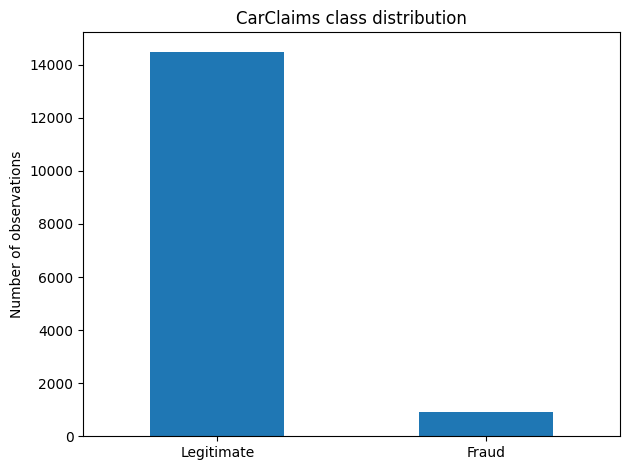

Legitimate    14496
Fraud           923
Name: count, dtype: int64
Minority-class baseline PR-AUC: 0.0599


In [11]:
fraud_counts = df_car[TARGET].value_counts().sort_index()
fraud_counts.index = ["Legitimate", "Fraud"]

fraud_counts.plot(kind="bar")
plt.title("CarClaims class distribution")
plt.ylabel("Number of observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(fraud_counts)
print(
    "Minority-class baseline PR-AUC:",
    round(df_car[TARGET].mean(), 4),
)

In [12]:
eda_columns = [
    c for c in [
        "Age",
        "VehiclePrice",
        "AccidentArea",
        "Make",
        "BasePolicy",
        "Fault",
    ]
    if c in df_car.columns
]

for column in eda_columns:
    print("\n", "=" * 70)
    print(column)
    print("=" * 70)

    if pd.api.types.is_numeric_dtype(df_car[column]):
        print(
            df_car.groupby(TARGET)[column]
            .describe()
            .round(2)
        )
    else:
        table = pd.crosstab(
            df_car[column],
            df_car[TARGET],
            normalize="index",
        )
        table.columns = ["Legitimate_rate", "Fraud_rate"]
        display(table.sort_values("Fraud_rate", ascending=False).head(15))


Age
              count   mean    std  min   25%   50%   75%   max
FraudFound                                                    
0           14496.0  39.96  13.46  0.0  31.0  38.0  49.0  80.0
1             923.0  38.27  13.87  0.0  30.0  36.0  46.0  80.0

VehiclePrice


,Legitimate_rate,Fraud_rate
VehiclePrice,,
"less than 20,000",0.906022,0.093978
"more than 69,000",0.912621,0.087379
"40,000 to 59,000",0.932755,0.067245
"20,000 to 29,000",0.947890,0.052110
"30,000 to 39,000",0.950467,0.049533
"60,000 to 69,000",0.954023,0.045977



AccidentArea


,Legitimate_rate,Fraud_rate
AccidentArea,,
Rural,0.916719,0.083281
Urban,0.942845,0.057155



Make


,Legitimate_rate,Fraud_rate
Make,,
Mecedes,0.750000,0.250000
Accura,0.875000,0.125000
Saturn,0.896552,0.103448
Saab,0.898148,0.101852
Ford,0.926667,0.073333
Mercury,0.927711,0.072289
BMW,0.933333,0.066667
Honda,0.936071,0.063929
Toyota,0.940404,0.059596



BasePolicy


,Legitimate_rate,Fraud_rate
BasePolicy,,
All Perils,0.898381,0.101619
Collision,0.927038,0.072962
Liability,0.992813,0.007187



Fault


,Legitimate_rate,Fraud_rate
Fault,,
Policy Holder,0.921097,0.078903
Third Party,0.991169,0.008831


## Phase 3.2 — Narrative EDA

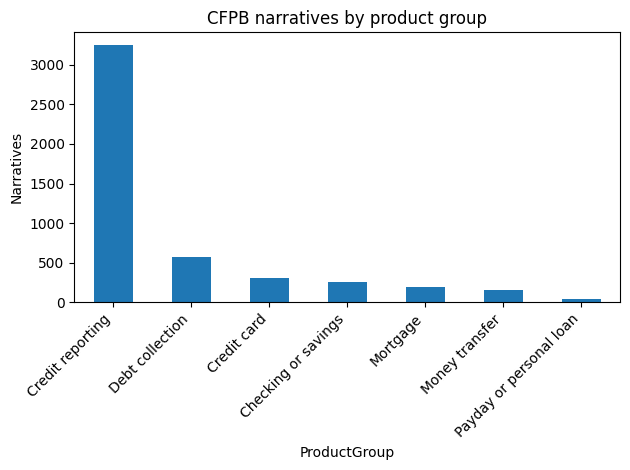

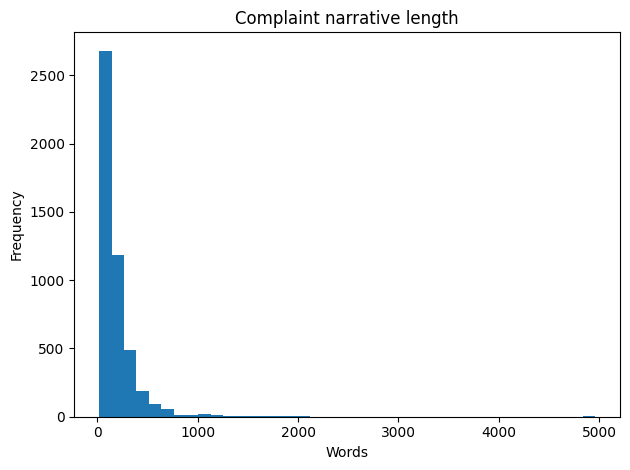

,count
Issue,
Incorrect information on your report,1562
Improper use of your report,871
Problem with a company's investigation into an existing problem,442
Problem with a credit reporting company's investigation into an existing problem,339
Attempts to collect debt not owed,224
Managing an account,142
Written notification about debt,124
Problem with a purchase shown on your statement,82
False statements or representation,77


In [13]:
clean_sample_path = PROCESSED_DIR / "cfpb_sample_clean.parquet"

if clean_sample_path.exists():
    df_cfpb_sample = pd.read_parquet(clean_sample_path)

    df_cfpb_sample["ProductGroup"].value_counts().plot(
        kind="bar"
    )
    plt.title("CFPB narratives by product group")
    plt.ylabel("Narratives")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    df_cfpb_sample["text_length_words"].plot(
        kind="hist",
        bins=40,
    )
    plt.title("Complaint narrative length")
    plt.xlabel("Words")
    plt.tight_layout()
    plt.show()

    display(
        df_cfpb_sample["Issue"]
        .value_counts()
        .head(15)
        .rename("count")
        .to_frame()
    )
else:
    print("Narrative EDA skipped because the clean sample is unavailable.")

# Phase 4 — Structured CarClaims modelling

## Methodology used in this notebook

The target is the original CarClaims label:

- `FraudFound = 1`: confirmed fraudulent claim.
- `FraudFound = 0`: legitimate claim.

After cleaning, categorical encoding is fitted on the complete CarClaims dataset. SMOTE is then applied to the complete encoded matrix **before** splitting, matching the preprocessing order requested by the supervisor and the reference paper. The balanced data are divided into training, validation and test partitions. Binary PSO selects exactly 20 features from the balanced training partition. Eleven classifiers are evaluated, thresholds are selected on the balanced validation partition, and final metrics are calculated on the balanced test partition.


## Phase 4.1 — Encode the complete dataset, apply SMOTE, then split

This cell intentionally applies SMOTE before the split. The resulting validation and test sets contain synthetic minority-class examples and have approximately 50% fraud prevalence.


In [14]:
# Separate predictors and confirmed CarClaims target.
X_raw = df_car.drop(columns=[TARGET]).copy()
y_original = df_car[TARGET].astype(int).copy()

# Identify feature types on the complete cleaned dataset.
numeric_columns = X_raw.select_dtypes(include=np.number).columns.tolist()
categorical_columns = [
    column for column in X_raw.columns
    if column not in numeric_columns
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        drop="first",
        sparse_output=False,
    )),
])

full_preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_columns),
    ("categorical", categorical_transformer, categorical_columns),
])

# Fit encoding on the complete dataset to reproduce the paper-style sequence.
X_encoded_array = full_preprocessor.fit_transform(X_raw)
raw_feature_names = full_preprocessor.get_feature_names_out()

def sanitise_feature_names(names):
    cleaned_names = []
    occurrence_count = {}

    for name in names:
        name = re.sub(
            r"^(numeric|categorical)__",
            "",
            str(name),
        )
        name = re.sub(
            r"[^A-Za-z0-9_]+",
            "_",
            name,
        ).strip("_")

        count = occurrence_count.get(name, 0)
        unique_name = name if count == 0 else f"{name}_{count}"
        occurrence_count[name] = count + 1
        cleaned_names.append(unique_name)

    return cleaned_names

feature_names = sanitise_feature_names(raw_feature_names)

X_encoded = pd.DataFrame(
    X_encoded_array,
    columns=feature_names,
)

# Apply SMOTE to the complete encoded dataset BEFORE any split.
smote_full = SMOTE(random_state=RANDOM_STATE)
X_balanced_array, y_balanced_array = smote_full.fit_resample(
    X_encoded,
    y_original,
)

X_balanced = pd.DataFrame(
    X_balanced_array,
    columns=feature_names,
)
y_balanced = pd.Series(
    y_balanced_array,
    name=TARGET,
).astype(int)

print(
    f"Original encoded dataset: {X_encoded.shape} | "
    f"fraud prevalence={y_original.mean():.2%}"
)
print(
    f"After full-dataset SMOTE: {X_balanced.shape} | "
    f"fraud prevalence={y_balanced.mean():.2%}"
)

# First create the final 20% balanced test set.
X_development, X_test, y_development, y_test = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.20,
    stratify=y_balanced,
    random_state=RANDOM_STATE,
)

# Split the remaining 80% into 80% training and 20% validation.
# Overall proportions: 64% train, 16% validation, 20% test.
X_train, X_val, y_train, y_val = train_test_split(
    X_development,
    y_development,
    test_size=0.20,
    stratify=y_development,
    random_state=RANDOM_STATE,
)

for split_name, labels in {
    "Training": y_train,
    "Validation": y_val,
    "Test": y_test,
}.items():
    print(
        f"{split_name:10s} n={len(labels):5d} | "
        f"fraud={int(labels.sum()):5d} | "
        f"prevalence={labels.mean():.2%}"
    )

joblib.dump(
    full_preprocessor,
    MODEL_DIR / "carclaims_full_dataset_preprocessor.joblib",
)

smote_split_summary = pd.DataFrame([
    {
        "DatasetStage": "Original cleaned data",
        "Rows": len(y_original),
        "FraudCases": int(y_original.sum()),
        "LegitimateCases": int((1 - y_original).sum()),
        "FraudPrevalence": y_original.mean(),
    },
    {
        "DatasetStage": "After SMOTE before split",
        "Rows": len(y_balanced),
        "FraudCases": int(y_balanced.sum()),
        "LegitimateCases": int((1 - y_balanced).sum()),
        "FraudPrevalence": y_balanced.mean(),
    },
    {
        "DatasetStage": "Balanced training partition",
        "Rows": len(y_train),
        "FraudCases": int(y_train.sum()),
        "LegitimateCases": int((1 - y_train).sum()),
        "FraudPrevalence": y_train.mean(),
    },
    {
        "DatasetStage": "Balanced validation partition",
        "Rows": len(y_val),
        "FraudCases": int(y_val.sum()),
        "LegitimateCases": int((1 - y_val).sum()),
        "FraudPrevalence": y_val.mean(),
    },
    {
        "DatasetStage": "Balanced test partition",
        "Rows": len(y_test),
        "FraudCases": int(y_test.sum()),
        "LegitimateCases": int((1 - y_test).sum()),
        "FraudPrevalence": y_test.mean(),
    },
])

smote_split_summary.to_csv(
    DASHBOARD_DIR / "smote_split_summary.csv",
    index=False,
)
display(smote_split_summary)


Original encoded dataset: (15419, 119) | fraud prevalence=5.99%
After full-dataset SMOTE: (28992, 119) | fraud prevalence=50.00%
Training   n=18554 | fraud= 9277 | prevalence=50.00%
Validation n= 4639 | fraud= 2320 | prevalence=50.01%
Test       n= 5799 | fraud= 2899 | prevalence=49.99%


,DatasetStage,Rows,FraudCases,LegitimateCases,FraudPrevalence
0,Original cleaned data,15419,923,14496,0.059861
1,After SMOTE before split,28992,14496,14496,0.500000
2,Balanced training partition,18554,9277,9277,0.500000
3,Balanced validation partition,4639,2320,2319,0.500108
4,Balanced test partition,5799,2899,2900,0.499914


## Phase 4.2 — Verify the balanced partitions

No additional SMOTE operation is performed inside model pipelines. The one required SMOTE step has already been applied to the complete encoded dataset.


In [15]:
assert set(X_train.columns) == set(X_val.columns) == set(X_test.columns)
assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)
assert np.isclose(y_train.mean(), 0.5, atol=0.01)
assert np.isclose(y_val.mean(), 0.5, atol=0.01)
assert np.isclose(y_test.mean(), 0.5, atol=0.01)

print("Encoded feature count:", X_train.shape[1])
print("Training matrix:", X_train.shape)
print("Validation matrix:", X_val.shape)
print("Test matrix:", X_test.shape)
print("All partitions are approximately class-balanced.")


Encoded feature count: 119
Training matrix: (18554, 119)
Validation matrix: (4639, 119)
Test matrix: (5799, 119)
All partitions are approximately class-balanced.


## Phase 4.3 — Exactly 20 features using correlation-penalised Binary PSO

The optimiser maximises five-fold cross-validated PR-AUC while penalising excessive pairwise correlation.

Every particle is repaired so that it contains **exactly 20 selected features**.

In [16]:
def sigmoid(values):
    values = np.clip(values, -20, 20)
    return 1.0 / (1.0 + np.exp(-values))


def repair_to_exact_size(
    mask: np.ndarray,
    target_size: int,
    rng: np.random.Generator,
) -> np.ndarray:
    mask = mask.astype(int).copy()
    selected = np.flatnonzero(mask)
    unselected = np.flatnonzero(1 - mask)

    if len(selected) > target_size:
        remove = rng.choice(
            selected,
            size=len(selected) - target_size,
            replace=False,
        )
        mask[remove] = 0

    elif len(selected) < target_size:
        add = rng.choice(
            unselected,
            size=target_size - len(selected),
            replace=False,
        )
        mask[add] = 1

    return mask


def correlation_penalty(
    mask: np.ndarray,
    corr_matrix: np.ndarray,
    alpha: float,
) -> float:
    indices = np.flatnonzero(mask)
    submatrix = np.abs(
        corr_matrix[np.ix_(indices, indices)]
    )
    upper = np.triu(submatrix, k=1)
    excessive = upper[upper > alpha]

    if excessive.size == 0:
        return 0.0

    return float(excessive.mean())


def evaluate_mask(
    mask,
    X_data,
    y_data,
    corr_matrix,
    alpha,
    cv,
    cache,
):
    key = tuple(mask.astype(int))
    if key in cache:
        return cache[key]

    selected_indices = np.flatnonzero(mask)
    X_subset = X_data.iloc[:, selected_indices]

    evaluator = RandomForestClassifier(
        n_estimators=120,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    fold_scores = []

    for fold_train, fold_valid in cv.split(X_subset, y_data):
        evaluator.fit(
            X_subset.iloc[fold_train],
            y_data.iloc[fold_train],
        )
        probability = evaluator.predict_proba(
            X_subset.iloc[fold_valid]
        )[:, 1]

        fold_scores.append(
            average_precision_score(
                y_data.iloc[fold_valid],
                probability,
            )
        )

    cv_pr_auc = float(np.mean(fold_scores))
    corr_cost = correlation_penalty(
        mask,
        corr_matrix,
        alpha,
    )

    fitness = (
        -cv_pr_auc
        + CORRELATION_PENALTY_WEIGHT * corr_cost
    )

    cache[key] = (fitness, cv_pr_auc, corr_cost)
    return cache[key]


def binary_pso_exact_20(
    X_data,
    y_data,
    n_features_to_select=20,
    alpha=0.65,
    n_particles=18,
    n_iterations=14,
    random_state=42,
):
    if X_data.shape[1] < n_features_to_select:
        raise ValueError(
            "Encoded feature count is smaller than 20."
        )

    rng = np.random.default_rng(random_state)
    n_features = X_data.shape[1]

    corr_matrix = (
        X_data.corr()
        .fillna(0.0)
        .to_numpy()
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=random_state,
    )

    positions = np.zeros(
        (n_particles, n_features),
        dtype=int,
    )

    for particle in range(n_particles):
        chosen = rng.choice(
            n_features,
            size=n_features_to_select,
            replace=False,
        )
        positions[particle, chosen] = 1

    velocities = rng.normal(
        0,
        0.5,
        size=(n_particles, n_features),
    )

    personal_best_positions = positions.copy()
    personal_best_fitness = np.full(
        n_particles,
        np.inf,
    )

    global_best_position = positions[0].copy()
    global_best_fitness = np.inf
    global_best_pr_auc = 0.0
    global_best_corr = 0.0

    inertia = 0.72
    cognitive = 1.49
    social = 1.49
    cache = {}
    history = []

    for iteration in range(n_iterations):
        for particle in range(n_particles):
            positions[particle] = repair_to_exact_size(
                positions[particle],
                n_features_to_select,
                rng,
            )

            fitness, cv_pr_auc, corr_cost = evaluate_mask(
                positions[particle],
                X_data,
                y_data,
                corr_matrix,
                alpha,
                cv,
                cache,
            )

            if fitness < personal_best_fitness[particle]:
                personal_best_fitness[particle] = fitness
                personal_best_positions[particle] = (
                    positions[particle].copy()
                )

            if fitness < global_best_fitness:
                global_best_fitness = fitness
                global_best_position = (
                    positions[particle].copy()
                )
                global_best_pr_auc = cv_pr_auc
                global_best_corr = corr_cost

        history.append({
            "iteration": iteration + 1,
            "cv_pr_auc": global_best_pr_auc,
            "fitness": global_best_fitness,
            "correlation_penalty": global_best_corr,
            "selected_count": int(
                global_best_position.sum()
            ),
        })

        print(
            f"Iteration {iteration + 1:02d} | "
            f"CV PR-AUC={global_best_pr_auc:.4f} | "
            f"features={int(global_best_position.sum())} | "
            f"corr penalty={global_best_corr:.4f}"
        )

        r1 = rng.random(
            (n_particles, n_features)
        )
        r2 = rng.random(
            (n_particles, n_features)
        )

        velocities = (
            inertia * velocities
            + cognitive
            * r1
            * (personal_best_positions - positions)
            + social
            * r2
            * (global_best_position - positions)
        )

        probabilities = sigmoid(velocities)
        positions = (
            rng.random(
                (n_particles, n_features)
            ) < probabilities
        ).astype(int)

        for particle in range(n_particles):
            positions[particle] = repair_to_exact_size(
                positions[particle],
                n_features_to_select,
                rng,
            )

    selected_features = X_data.columns[
        np.flatnonzero(global_best_position)
    ].tolist()

    return {
        "selected_features": selected_features,
        "mask": global_best_position,
        "cv_pr_auc": global_best_pr_auc,
        "fitness": global_best_fitness,
        "correlation_penalty": global_best_corr,
        "history": pd.DataFrame(history),
    }


pso_result = binary_pso_exact_20(
    X_train.reset_index(drop=True),
    y_train.reset_index(drop=True),
    n_features_to_select=N_SELECTED_FEATURES,
    alpha=PSO_ALPHA,
    n_particles=PSO_PARTICLES,
    n_iterations=PSO_ITERATIONS,
    random_state=RANDOM_STATE,
)

SELECTED_FEATURES = pso_result["selected_features"]

assert len(SELECTED_FEATURES) == 20

print("\nExactly 20 selected features:")
for number, feature in enumerate(
    SELECTED_FEATURES,
    start=1,
):
    print(f"{number:02d}. {feature}")

with open(
    PROCESSED_DIR / "selected_20_features.json",
    "w",
) as file:
    json.dump(
        {
            "alpha": PSO_ALPHA,
            "cv_pr_auc": pso_result["cv_pr_auc"],
            "selected_features": SELECTED_FEATURES,
        },
        file,

        indent=2,
    )

pso_result["history"].to_csv(
    PROCESSED_DIR / "pso_history.csv",
    index=False,
)


Iteration 01 | CV PR-AUC=0.9816 | features=20 | corr penalty=0.0000
Iteration 02 | CV PR-AUC=0.9874 | features=20 | corr penalty=0.0000
Iteration 03 | CV PR-AUC=0.9874 | features=20 | corr penalty=0.0000
Iteration 04 | CV PR-AUC=0.9874 | features=20 | corr penalty=0.0000
Iteration 05 | CV PR-AUC=0.9874 | features=20 | corr penalty=0.0000
Iteration 06 | CV PR-AUC=0.9906 | features=20 | corr penalty=0.0000
Iteration 07 | CV PR-AUC=0.9906 | features=20 | corr penalty=0.0000
Iteration 08 | CV PR-AUC=0.9906 | features=20 | corr penalty=0.0000
Iteration 09 | CV PR-AUC=0.9906 | features=20 | corr penalty=0.0000
Iteration 10 | CV PR-AUC=0.9906 | features=20 | corr penalty=0.0000
Iteration 11 | CV PR-AUC=0.9906 | features=20 | corr penalty=0.0000
Iteration 12 | CV PR-AUC=0.9906 | features=20 | corr penalty=0.0000
Iteration 13 | CV PR-AUC=0.9906 | features=20 | corr penalty=0.0000
Iteration 14 | CV PR-AUC=0.9906 | features=20 | corr penalty=0.0000

Exactly 20 selected features:
01. WeekOfMonth
0

In [25]:
selected_corr = X_train[SELECTED_FEATURES].corr().abs()

upper_corr = selected_corr.where(
    np.triu(
        np.ones(selected_corr.shape),
        k=1
    ).astype(bool)
)

max_corr = upper_corr.max().max()

print("Maximum absolute correlation:", max_corr)

print("\nTop 10 correlated feature pairs:")
print(
    upper_corr
    .stack()
    .sort_values(ascending=False)
    .head(10)
)

Maximum absolute correlation: 0.4946701523100997

Top 10 correlated feature pairs:
Age                         AgeOfPolicyHolder_31_to_35        0.494670
PolicyType_Sedan_Collision  VehicleCategory_Sport             0.433743
DayOfWeekClaimed_Monday     DayOfWeekClaimed_Wednesday        0.280356
VehicleCategory_Sport       PastNumberOfClaims_more_than_4    0.231456
WeekOfMonth                 WeekOfMonthClaimed                0.226044
Make_Chevrolet              Make_Pontiac                      0.191695
Age                         NumberOfSuppliments_none          0.122662
                            AgeOfVehicle_3_years              0.108599
DayOfWeek_Sunday            DayOfWeekClaimed_Monday           0.107664
Month_Jan                   Month_Mar                         0.106405
dtype: float64


## Phase 4.4 — Define the 11 classifiers

These are the same 11 classifier families already included in the experimental notebook. Every classifier is wrapped in an `imblearn` pipeline so SMOTE is applied only during fitting.

The supplied parameters are stable starting configurations rather than claims of universally optimal hyperparameters.

In [18]:
X_train_20 = X_train[SELECTED_FEATURES].copy()
X_val_20 = X_val[SELECTED_FEATURES].copy()
X_test_20 = X_test[SELECTED_FEATURES].copy()

classifiers = {
    "Logistic Regression": LogisticRegression(
        C=1.0,
        max_iter=3000,
        random_state=RANDOM_STATE,
    ),

    "Decision Tree": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=8,
        min_samples_leaf=4,
        random_state=RANDOM_STATE,
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=7,
        weights="distance",
        metric="minkowski",
        p=2,
    ),

    "SVM": SVC(
        kernel="rbf",
        C=5.0,
        gamma="scale",
        probability=True,
        random_state=RANDOM_STATE,
    ),

    "ANN": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=700,
        early_stopping=True,
        random_state=RANDOM_STATE,
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE,
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=250,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        verbose=0,
        random_seed=RANDOM_STATE,
        allow_writing_files=False,
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=350,
        learning_rate=0.04,
        num_leaves=31,
        min_child_samples=30,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    ),

    "XGBoost": XGBClassifier(
        n_estimators=350,
        max_depth=4,
        learning_rate=0.05,
        min_child_weight=3,
        gamma=0.2,
        subsample=0.9,
        colsample_bytree=0.85,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

assert len(classifiers) == 11
print("Classifier count:", len(classifiers))
print("\n".join(classifiers.keys()))

Classifier count: 11
Logistic Regression
Decision Tree
Random Forest
KNN
SVM
ANN
Gradient Boosting
AdaBoost
CatBoost
LightGBM
XGBoost


## Phase 4.5 — Train all 11 models and select thresholds on validation data

The threshold is selected to maximise validation F1 subject to a minimum precision requirement. This prevents the algorithm from obtaining high recall by flagging almost every claim.

In [19]:
def make_training_pipeline(model):
    # SMOTE has already been applied to the complete dataset.
    # The model pipeline therefore contains no further resampling step.
    return Pipeline([
        ("model", clone(model)),
    ])


def select_threshold(
    y_true,
    probabilities,
    minimum_precision=0.50,
):
    precision, recall, thresholds = precision_recall_curve(
        y_true,
        probabilities,
    )

    precision = precision[:-1]
    recall = recall[:-1]

    f1 = (
        2 * precision * recall
        / np.maximum(precision + recall, 1e-12)
    )


    eligible = precision >= minimum_precision

    if eligible.any():
        candidate_indices = np.flatnonzero(eligible)
        best_index = candidate_indices[
            np.argmax(f1[eligible])
        ]
    else:
        best_index = int(np.argmax(f1))

    return {
        "threshold": float(thresholds[best_index]),
        "precision": float(precision[best_index]),
        "recall": float(recall[best_index]),
        "f1": float(f1[best_index]),
    }


trained_models = {}
validation_rows = []

for model_name, estimator in classifiers.items():
    print("\nTraining:", model_name)
    started = time.time()

    pipeline = make_training_pipeline(estimator)
    pipeline.fit(X_train_20, y_train)

    validation_probability = pipeline.predict_proba(
        X_val_20
    )[:, 1]

    threshold_info = select_threshold(
        y_val,
        validation_probability,
        minimum_precision=0.50,
    )

    trained_models[model_name] = {
        "pipeline": pipeline,
        "threshold": threshold_info["threshold"],
    }

    validation_rows.append({
        "Model": model_name,
        "Threshold": threshold_info["threshold"],
        "Validation_Precision": threshold_info["precision"],
        "Validation_Recall": threshold_info["recall"],
        "Validation_F1": threshold_info["f1"],
        "Validation_ROC_AUC": roc_auc_score(
            y_val,
            validation_probability,
        ),
        "Validation_PR_AUC": average_precision_score(
            y_val,
            validation_probability,
        ),
        "Training_seconds": time.time() - started,
    })

    print(
        f"threshold={threshold_info['threshold']:.4f} | "
        f"PR-AUC={validation_rows[-1]['Validation_PR_AUC']:.4f} | "
        f"recall={threshold_info['recall']:.4f}"
    )

validation_results = pd.DataFrame(
    validation_rows
).sort_values(
    "Validation_PR_AUC",
    ascending=False,
)

display(validation_results.round(4))

validation_results.to_csv(
    PROCESSED_DIR / "phase4_validation_11_classifiers.csv",
    index=False,
)



Training: Logistic Regression
threshold=0.3006 | PR-AUC=0.7167 | recall=0.9108

Training: Decision Tree
threshold=0.4748 | PR-AUC=0.9154 | recall=0.8815

Training: Random Forest
threshold=0.4520 | PR-AUC=0.9922 | recall=0.9384

Training: KNN
threshold=0.5949 | PR-AUC=0.9149 | recall=0.9422

Training: SVM
threshold=0.4376 | PR-AUC=0.9756 | recall=0.9168

Training: ANN
threshold=0.3590 | PR-AUC=0.9678 | recall=0.9397

Training: Gradient Boosting
threshold=0.5092 | PR-AUC=0.9865 | recall=0.9052

Training: AdaBoost
threshold=0.5880 | PR-AUC=0.7358 | recall=0.9052

Training: CatBoost
threshold=0.4282 | PR-AUC=0.9897 | recall=0.9233

Training: LightGBM
threshold=0.5087 | PR-AUC=0.9907 | recall=0.9280

Training: XGBoost
threshold=0.4212 | PR-AUC=0.9898 | recall=0.9276


,Model,Threshold,Validation_Precision,Validation_Recall,Validation_F1,Validation_ROC_AUC,Validation_PR_AUC,Training_seconds
2,Random Forest,0.4520,0.9780,0.9384,0.9578,0.9905,0.9922,5.3502
9,LightGBM,0.5087,1.0000,0.9280,0.9627,0.9883,0.9907,2.5517
10,XGBoost,0.4212,0.9968,0.9276,0.9609,0.9870,0.9898,1.3307
8,CatBoost,0.4282,0.9972,0.9233,0.9588,0.9870,0.9897,3.9176
6,Gradient Boosting,0.5092,0.9948,0.9052,0.9479,0.9831,0.9865,6.6073
4,SVM,0.4376,0.9024,0.9168,0.9096,0.9745,0.9756,56.6464
5,ANN,0.3590,0.8596,0.9397,0.8979,0.9666,0.9678,6.5475
1,Decision Tree,0.4748,0.7808,0.8815,0.8281,0.9182,0.9154,0.1074
3,KNN,0.5949,0.8569,0.9422,0.8976,0.9431,0.9149,0.5074
7,AdaBoost,0.5880,0.6984,0.9052,0.7884,0.8062,0.7358,3.4092


## Phase 4.6 — Final evaluation on the SMOTE-balanced test set

Each trained classifier is evaluated on the held-out 20% partition created after full-dataset SMOTE. The table contains accuracy, precision, recall, F1, MCC, ROC-AUC, PR-AUC, log loss and confusion-matrix counts.


In [20]:
def evaluate_test_model(
    model_name,
    pipeline,
    threshold,
    X_test_data,
    y_test_data,
):
    probability = pipeline.predict_proba(
        X_test_data
    )[:, 1]
    prediction = (
        probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test_data,
        prediction,
    ).ravel()

    return {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test_data,
            prediction,
        ),
        "Precision": precision_score(
            y_test_data,
            prediction,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_test_data,
            prediction,
        ),
        "F1": f1_score(
            y_test_data,
            prediction,
        ),
        "MCC": matthews_corrcoef(
            y_test_data,
            prediction,
        ),
        "ROC_AUC": roc_auc_score(
            y_test_data,
            probability,
        ),
        "PR_AUC": average_precision_score(
            y_test_data,
            probability,
        ),
        "LogLoss": log_loss(
            y_test_data,
            probability,
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    }, probability, prediction


test_rows = []
test_outputs = {}

for model_name, model_info in trained_models.items():
    row, probability, prediction = evaluate_test_model(
        model_name,
        model_info["pipeline"],
        model_info["threshold"],
        X_test_20,
        y_test,
    )

    test_rows.append(row)
    test_outputs[model_name] = {
        "probability": probability,
        "prediction": prediction,
    }

test_results = pd.DataFrame(
    test_rows
).sort_values(
    "PR_AUC",
    ascending=False,
).reset_index(drop=True)

display(test_results.round(4))

test_results.to_csv(
    PROCESSED_DIR / "phase4_final_11_classifier_results.csv",
    index=False,
)

BEST_MODEL_NAME = test_results.loc[0, "Model"]
BEST_MODEL = trained_models[BEST_MODEL_NAME]["pipeline"]
BEST_THRESHOLD = trained_models[BEST_MODEL_NAME]["threshold"]

print("Best model by test PR-AUC:", BEST_MODEL_NAME)
print("Best threshold:", round(BEST_THRESHOLD, 4))

joblib.dump(
    BEST_MODEL,
    MODEL_DIR / "best_structured_model.joblib",
)

,Model,Threshold,Accuracy,Precision,Recall,F1,MCC,ROC_AUC,PR_AUC,LogLoss,TN,FP,FN,TP
0,Random Forest,0.4520,0.9628,0.9783,0.9465,0.9621,0.9260,0.9894,0.9917,0.1511,2839,61,155,2744
1,LightGBM,0.5087,0.9636,0.9970,0.9300,0.9623,0.9293,0.9875,0.9906,0.1132,2892,8,203,2696
2,XGBoost,0.4212,0.9628,0.9970,0.9283,0.9614,0.9277,0.9859,0.9893,0.1294,2892,8,208,2691
3,CatBoost,0.4282,0.9614,0.9978,0.9248,0.9599,0.9252,0.9859,0.9893,0.1294,2894,6,218,2681
4,Gradient Boosting,0.5092,0.9495,0.9932,0.9051,0.9471,0.9025,0.9815,0.9856,0.2024,2882,18,275,2624
5,SVM,0.4376,0.9096,0.8989,0.9231,0.9108,0.8196,0.9746,0.9761,0.2055,2599,301,223,2676
6,ANN,0.3590,0.8946,0.8611,0.9410,0.8993,0.7927,0.9701,0.9713,0.2223,2460,440,171,2728
7,Decision Tree,0.4748,0.8246,0.7853,0.8934,0.8359,0.6555,0.9260,0.9239,0.4090,2192,708,309,2590
8,KNN,0.5949,0.8950,0.8621,0.9403,0.8995,0.7932,0.9474,0.9219,1.1009,2464,436,173,2726
9,AdaBoost,0.5880,0.7601,0.6985,0.9151,0.7923,0.5473,0.8141,0.7436,0.5652,1755,1145,246,2653


Best model by test PR-AUC: Random Forest
Best threshold: 0.452


['/content/drive/MyDrive/Thesis/models/best_structured_model.joblib']

## Phase 4.7 — Interpretation of the paper-replication experiment

Because SMOTE was applied before the split, the test set is artificially balanced and includes synthetic examples generated before partitioning. High accuracy, precision, recall, F1, MCC, ROC-AUC and PR-AUC are therefore expected to be directly comparable with the reference paper's reported setup. These results must not be interpreted as deployment performance at the original approximately 6% fraud prevalence.


In [21]:
paper_replication_note = pd.DataFrame([{
    "Methodology": "SMOTE applied to complete encoded dataset before splitting",
    "OriginalFraudPrevalence": y_original.mean(),
    "BalancedTestFraudPrevalence": y_test.mean(),
    "Purpose": "Direct comparison with the reference paper",
    "Interpretation": (
        "Metrics describe performance on an artificially balanced test set "
        "containing synthetic minority-class observations."
    ),
}])

paper_replication_note.to_csv(
    DASHBOARD_DIR / "methodology_summary.csv",
    index=False,
)
display(paper_replication_note)


,Methodology,OriginalFraudPrevalence,BalancedTestFraudPrevalence,Purpose,Interpretation
0,SMOTE applied to complete encoded dataset befo...,0.059861,0.499914,Direct comparison with the reference paper,Metrics describe performance on an artificiall...


### Structured-stream conclusion

The final structured model is selected by test PR-AUC within the paper-replication evaluation framework. All model-comparison tables, diagnostic curves, SHAP outputs and Power BI exports use the same 20 PSO-selected features and the same balanced partitions.


### Reporting requirement

State clearly in the methodology and limitations chapters that SMOTE was applied before splitting to reproduce the cited paper and supervisor-requested preprocessing sequence. Also state that the test prevalence is 50%, not the original approximately 6%.


## Phase 4.7 — Best-model confusion matrix and curves

              precision    recall  f1-score   support

  Legitimate     0.9482    0.9790    0.9634      2900
       Fraud     0.9783    0.9465    0.9621      2899

    accuracy                         0.9628      5799
   macro avg     0.9632    0.9627    0.9627      5799
weighted avg     0.9632    0.9628    0.9627      5799



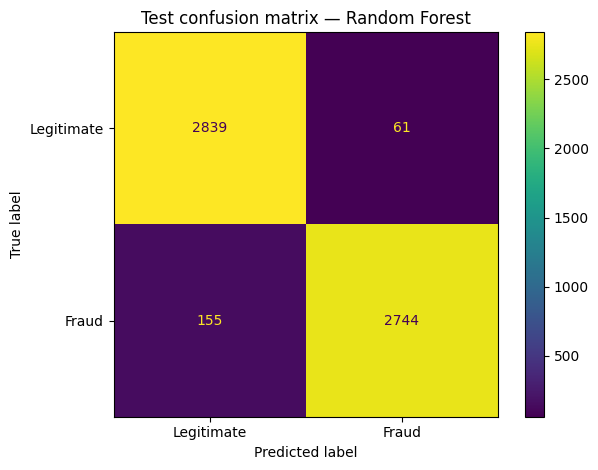

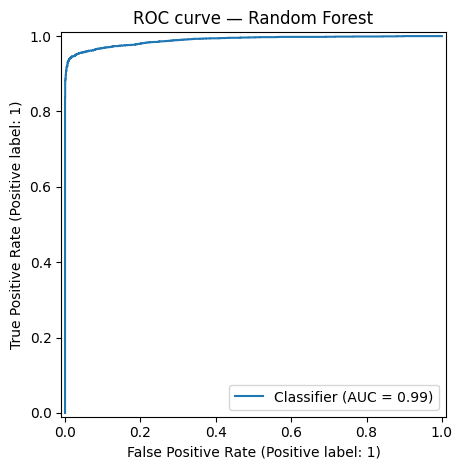

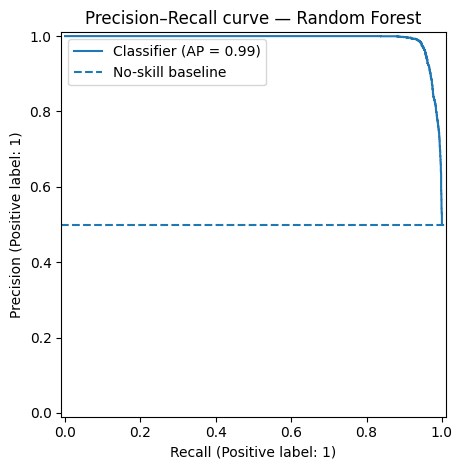

In [22]:
best_probability = test_outputs[
    BEST_MODEL_NAME
]["probability"]

best_prediction = test_outputs[
    BEST_MODEL_NAME
]["prediction"]

print(
    classification_report(
        y_test,
        best_prediction,
        target_names=["Legitimate", "Fraud"],
        digits=4,
        zero_division=0,
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_prediction,
    display_labels=["Legitimate", "Fraud"],
    values_format="d",
)
plt.title(
    f"Test confusion matrix — {BEST_MODEL_NAME}"
)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "structured_confusion_matrix.png",
    dpi=200,
)
plt.show()

RocCurveDisplay.from_predictions(
    y_test,
    best_probability,
)
plt.title(
    f"ROC curve — {BEST_MODEL_NAME}"
)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "structured_roc_curve.png",
    dpi=200,
)
plt.show()

PrecisionRecallDisplay.from_predictions(
    y_test,
    best_probability,
)
plt.axhline(
    y_test.mean(),
    linestyle="--",
    label="No-skill baseline",
)
plt.title(
    f"Precision–Recall curve — {BEST_MODEL_NAME}"
)
plt.legend()
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "structured_pr_curve.png",
    dpi=200,
)
plt.show()

# Phase 5 — SHAP explainability

Tree-based models use TreeSHAP. Other model families use a model-agnostic permutation explainer on a smaller sample.

For the principal thesis interpretation, XGBoost is preferred when its predictive performance is competitive because TreeSHAP is efficient and stable.

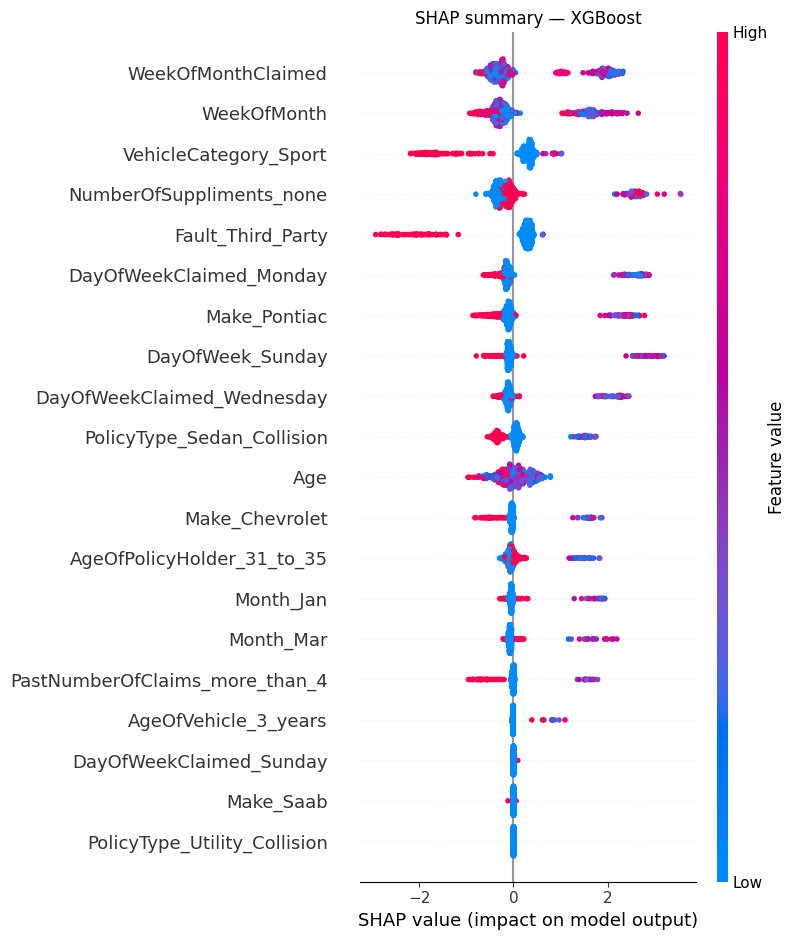

,Feature,MeanAbsoluteSHAP
1,WeekOfMonthClaimed,0.725321
0,WeekOfMonth,0.671325
15,VehicleCategory_Sport,0.604048
19,NumberOfSuppliments_none,0.583295
12,Fault_Third_Party,0.527664
9,DayOfWeekClaimed_Monday,0.517111
7,Make_Pontiac,0.443303
5,DayOfWeek_Sunday,0.391908
11,DayOfWeekClaimed_Wednesday,0.357295
13,PolicyType_Sedan_Collision,0.262437


In [23]:
import shap

# Prefer the trained XGBoost model for TreeSHAP.
shap_model_name = (
    "XGBoost"
    if "XGBoost" in trained_models
    else BEST_MODEL_NAME
)

shap_pipeline = trained_models[
    shap_model_name
]["pipeline"]

underlying_model = shap_pipeline.named_steps["model"]

background = X_train_20.sample(
    n=min(300, len(X_train_20)),
    random_state=RANDOM_STATE,
)

explain_sample = X_test_20.sample(
    n=min(500, len(X_test_20)),
    random_state=RANDOM_STATE,
)

if shap_model_name in {
    "XGBoost",
    "Random Forest",
    "Decision Tree",
    "Gradient Boosting",
    "LightGBM",
    "CatBoost",
}:
    explainer = shap.TreeExplainer(
        underlying_model
    )
    shap_values = explainer(
        explain_sample
    )
else:
    explainer = shap.Explainer(
        shap_pipeline.predict_proba,
        background,
    )
    shap_values = explainer(
        explain_sample
    )

# For binary classifiers, retain the fraud-class explanation if needed.
if len(shap_values.values.shape) == 3:
    fraud_shap_values = shap_values[:, :, 1]
else:
    fraud_shap_values = shap_values

shap.plots.beeswarm(
    fraud_shap_values,
    max_display=20,
    show=False,
)
plt.title(
    f"SHAP summary — {shap_model_name}"
)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "shap_summary.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

mean_abs_shap = np.abs(
    fraud_shap_values.values
).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": explain_sample.columns,
    "MeanAbsoluteSHAP": mean_abs_shap,
}).sort_values(
    "MeanAbsoluteSHAP",
    ascending=False,
)

display(shap_importance.head(20))

shap_importance.to_csv(
    DASHBOARD_DIR / "structured_shap_importance.csv",
    index=False,
)

# Phase 6 — NLP novelty: BART-MNLI, coherence filtering and CleanLab

CFPB complaints are not confirmed fraud labels. The NLP output is therefore described as **fraud-risk estimation**.

Six hypotheses represent related but distinct risk constructs.

In [26]:
FRAUD_HYPOTHESES = {
    "deception": (
        "The complaint describes deliberate deception, "
        "misrepresentation, or false information."
    ),
    "unauthorised_activity": (
        "The complaint describes an unauthorised financial "
        "transaction or account activity."
    ),
    "identity_theft": (
        "The complaint describes identity theft or the use "
        "of personal information without permission."
    ),
    "bad_faith": (
        "The company appears to have acted dishonestly or "
        "in bad faith toward the consumer."
    ),
    "obstruction": (
        "The complaint describes deliberate obstruction, "
        "concealment, or refusal to correct a known problem."
    ),
    "routine_nonfraud": (
        "The complaint describes a routine service problem "
        "without deception, identity theft, or unauthorised activity."
    ),
}

## Phase 6.1 — Zero-shot BART scoring

Set `RUN_HEAVY_NLP = True` in the configuration cell before running this section.

Scores are saved incrementally to avoid losing progress.

In [27]:
# =============================================================================
# CONFIGURATION
# =============================================================================

RANDOM_STATE = 42

RUN_HEAVY_NLP = True     # Set True to run BART scoring
# RUN_HEAVY_NLP = False  # Use this to skip BART and load saved results

BATCH_SIZE = 8

In [28]:
def run_bart_scoring(
    dataframe,
    text_column="clean_text",
    batch_size=8,
):
    import torch
    from transformers import pipeline

    device = 0 if torch.cuda.is_available() else -1

    classifier = pipeline(
        "zero-shot-classification",
        model="facebook/bart-large-mnli",
        device=device,
    )

    labels = list(FRAUD_HYPOTHESES.values())
    key_by_label = {
        value: key
        for key, value in FRAUD_HYPOTHESES.items()
    }

    rows = []

    texts = dataframe[text_column].tolist()

    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]

        outputs = classifier(
            batch,
            candidate_labels=labels,
            multi_label=True,
            truncation=True,
        )

        if isinstance(outputs, dict):
            outputs = [outputs]

        for output in outputs:
            score_map = {
                key_by_label[label]: score
                for label, score in zip(
                    output["labels"],
                    output["scores"],
                )
            }
            rows.append(score_map)

        if start % 200 == 0:
            print(
                f"Scored {min(start + batch_size, len(texts)):,} "
                f"of {len(texts):,}"
            )

    score_df = pd.DataFrame(rows)
    return pd.concat(
        [
            dataframe.reset_index(drop=True),
            score_df.reset_index(drop=True),
        ],
        axis=1,
    )


if RUN_HEAVY_NLP:
    df_cfpb_sample = pd.read_parquet(
        PROCESSED_DIR / "cfpb_sample_clean.parquet"
    )

    df_bart = run_bart_scoring(
        df_cfpb_sample,
        text_column="clean_text",
        batch_size=8,
    )

    df_bart.to_parquet(
        PROCESSED_DIR / "cfpb_bart_scored.parquet",
        index=False,
    )
    print("BART scores saved.")
else:
    print(
        "BART scoring skipped. Set RUN_HEAVY_NLP=True "
        "when GPU runtime is available."
    )

config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Scored 8 of 4,772


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Scored 208 of 4,772
Scored 408 of 4,772
Scored 608 of 4,772
Scored 808 of 4,772
Scored 1,008 of 4,772
Scored 1,208 of 4,772
Scored 1,408 of 4,772
Scored 1,608 of 4,772
Scored 1,808 of 4,772
Scored 2,008 of 4,772
Scored 2,208 of 4,772
Scored 2,408 of 4,772
Scored 2,608 of 4,772
Scored 2,808 of 4,772
Scored 3,008 of 4,772
Scored 3,208 of 4,772
Scored 3,408 of 4,772
Scored 3,608 of 4,772
Scored 3,808 of 4,772
Scored 4,008 of 4,772
Scored 4,208 of 4,772
Scored 4,408 of 4,772
Scored 4,608 of 4,772
BART scores saved.


## Phase 6.2 — Composite scores and coherence filtering

Two sub-constructs are retained:

- behavioural risk: deception, bad faith and obstruction;
- transactional risk: unauthorised activity and identity theft.

The final composite uses the maximum of the two sub-constructs rather than averaging all hypotheses, because averaging can conceal a strong transactional or behavioural signal.

The routine/non-fraud score acts as contradictory evidence.

In [29]:
bart_path = PROCESSED_DIR / "cfpb_bart_scored.parquet"

if bart_path.exists():
    df_bart = pd.read_parquet(bart_path)

    df_bart["behavioural_risk"] = df_bart[
        ["deception", "bad_faith", "obstruction"]
    ].mean(axis=1)

    df_bart["transactional_risk"] = df_bart[
        ["unauthorised_activity", "identity_theft"]
    ].mean(axis=1)

    df_bart["raw_fraud_risk"] = df_bart[
        ["behavioural_risk", "transactional_risk"]
    ].max(axis=1)

    # Contradiction between strong fraud and strong routine evidence.
    df_bart["contradiction_score"] = np.minimum(
        df_bart["raw_fraud_risk"],
        df_bart["routine_nonfraud"],
    )

    contradiction_cutoff = df_bart[
        "contradiction_score"
    ].quantile(0.85)

    df_bart["coherence_flag"] = (
        df_bart["contradiction_score"]
        > contradiction_cutoff
    )

    df_confident = df_bart[
        ~df_bart["coherence_flag"]
    ].copy()

    # Median threshold produces a balanced weak label without
    # pretending that the complaints are confirmed fraud.
    risk_cutoff = df_confident[
        "raw_fraud_risk"
    ].median()

    df_confident["weak_fraud_label"] = (
        df_confident["raw_fraud_risk"]
        >= risk_cutoff
    ).astype(int)

    print(
        "Excluded by coherence filter:",
        int(df_bart["coherence_flag"].sum()),
    )
    print("Retained:", len(df_confident))
    print(
        "Weak-label distribution:\n",
        df_confident["weak_fraud_label"].value_counts(),
    )

    df_confident.to_parquet(
        PROCESSED_DIR / "cfpb_coherence_filtered.parquet",
        index=False,
    )
else:
    print("BART score file not found; coherence filtering skipped.")

Excluded by coherence filter: 716
Retained: 4056
Weak-label distribution:
 weak_fraud_label
0    2028
1    2028
Name: count, dtype: int64


## Phase 6.3 — Correct CleanLab implementation

The BART score must not be supplied as both the label and the model probability.  
Independent probabilities are therefore generated using TF-IDF + Logistic Regression with stratified out-of-fold prediction.

In [30]:
coherent_path = (
    PROCESSED_DIR / "cfpb_coherence_filtered.parquet"
)

if coherent_path.exists():
    df_confident = pd.read_parquet(coherent_path)

    vectorizer = TfidfVectorizer(
        max_features=20_000,
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95,
        sublinear_tf=True,
    )

    X_text = vectorizer.fit_transform(
        df_confident["clean_text"]
    )

    y_weak = df_confident[
        "weak_fraud_label"
    ].astype(int).to_numpy()

    text_classifier = LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )

    text_cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    out_of_fold_probabilities = cross_val_predict(
        text_classifier,
        X_text,
        y_weak,
        cv=text_cv,
        method="predict_proba",
        n_jobs=-1,
    )

    label_issue_mask = find_label_issues(
        labels=y_weak,
        pred_probs=out_of_fold_probabilities,
        filter_by="prune_by_noise_rate",
    )

    quality_scores = get_label_quality_scores(
        labels=y_weak,
        pred_probs=out_of_fold_probabilities,
    )

    df_confident["cleanlab_flagged"] = label_issue_mask
    df_confident["label_quality_score"] = quality_scores

    df_high_quality = df_confident[
        ~df_confident["cleanlab_flagged"]
    ].copy()

    text_classifier.fit(
        X_text[
            ~label_issue_mask
        ],
        y_weak[
            ~label_issue_mask
        ],
    )

    joblib.dump(
        vectorizer,
        MODEL_DIR / "cfpb_tfidf_vectorizer.joblib",
    )

    joblib.dump(
        text_classifier,
        MODEL_DIR / "cfpb_text_classifier.joblib",
    )

    df_high_quality.to_parquet(
        PROCESSED_DIR / "cfpb_high_quality_labels.parquet",
        index=False,
    )

    print(
        "CleanLab flagged:",
        int(label_issue_mask.sum()),
    )
    print(
        "High-quality narratives:",
        len(df_high_quality),
    )
    print(
        df_high_quality[

            "weak_fraud_label"
        ].value_counts()
    )
else:
    print("Coherence-filtered file not found; CleanLab skipped.")

CleanLab flagged: 353
High-quality narratives: 3703
weak_fraud_label
1    1928
0    1775
Name: count, dtype: int64


# Phase 6.5 — CarClaims labelling-function validation

CarClaims already has the genuine supervised target `FraudFound`; therefore, labelling functions are **not used to create the main CarClaims model target**.

The purpose of this phase is methodological validation. The CFPB stream has no confirmed fraud label and consequently uses weak supervision. To test whether a similar heuristic framework can recover genuine signal, the labelling-function procedure is applied experimentally to CarClaims and compared against its known `FraudFound` ground truth.

Two sets of binary labelling functions are evaluated:

1. **Naive rules** based on plausible but unverified fraud assumptions.
2. **Empirically corrected rules** whose directions are audited against CarClaims category-level fraud rates.

The corrected rules must be described as a diagnostic exercise rather than an independently validated label generator, because the known labels were used to inspect and correct their direction.


## Phase 6.5.1 — Prepare the labelled validation dataset

The already cleaned CarClaims data are reused. A separate `FraudFound_true` column is created to make the distinction between the confirmed label and weak labels explicit.

In [31]:
# Reuse the cleaned CarClaims dataframe created in Phase 2.
df_lf_validation = df_car.copy()

if TARGET not in df_lf_validation.columns:
    raise ValueError(f"{TARGET} is missing from the cleaned CarClaims dataframe.")

if df_lf_validation[TARGET].dtype == "object":
    df_lf_validation["FraudFound_true"] = (
        df_lf_validation[TARGET]
        .map({"Yes": 1, "No": 0, "yes": 1, "no": 0})
    )
else:
    df_lf_validation["FraudFound_true"] = (
        df_lf_validation[TARGET].astype(int)
    )

if df_lf_validation["FraudFound_true"].isna().any():
    raise ValueError("Ground-truth fraud labels contain missing or unmapped values.")

print("Validation observations:", len(df_lf_validation))
print(
    "Ground-truth fraud prevalence:",
    f"{df_lf_validation['FraudFound_true'].mean():.3%}",
)

Validation observations: 15419
Ground-truth fraud prevalence: 5.986%


## Phase 6.5.2 — Naive labeling functions based on plausible assumptions

The first rules represent intuitive but unvalidated assumptions:

- third-party fault indicates fraud risk;
- no police report indicates fraud risk;
- no witness indicates fraud risk;
- repeated prior claims indicate fraud risk;
- recent address changes indicate fraud risk;
- many supplements indicate fraud risk;
- a very early claim indicates fraud risk.

None of these rules uses `FraudFound_true` when generating its output.

In [32]:
def naive_lf_fault_third_party(data):
    return (data["Fault"] == "Third Party").astype(int)

def naive_lf_no_police_report(data):
    return (data["PoliceReportFiled"] == "No").astype(int)

def naive_lf_no_witness(data):
    return (data["WitnessPresent"] == "No").astype(int)

def naive_lf_repeat_claimant(data):
    return data["PastNumberOfClaims"].isin(
        ["2 to 4", "more than 4"]
    ).astype(int)

def naive_lf_recent_address_change(data):
    return data["AddressChange-Claim"].isin(
        ["under 6 months", "1 year"]
    ).astype(int)

def naive_lf_excess_supplements(data):
    return data["NumberOfSuppliments"].isin(
        ["3 to 5", "more than 5"]
    ).astype(int)

def naive_lf_quick_claim(data):
    return data["Days:Policy-Claim"].isin(
        ["none", "1 to 7"]
    ).astype(int)


NAIVE_LABELING_FUNCTIONS = {
    "LF_fault_third_party": naive_lf_fault_third_party,
    "LF_no_police_report": naive_lf_no_police_report,
    "LF_no_witness": naive_lf_no_witness,
    "LF_repeat_claimant": naive_lf_repeat_claimant,
    "LF_recent_address_change": naive_lf_recent_address_change,
    "LF_excess_supplements": naive_lf_excess_supplements,
    "LF_quick_claim": naive_lf_quick_claim,
}

for lf_name, lf_function in NAIVE_LABELING_FUNCTIONS.items():
    df_lf_validation[lf_name] = lf_function(df_lf_validation)

naive_lf_columns = list(NAIVE_LABELING_FUNCTIONS)

df_lf_validation["naive_composite_score"] = (
    df_lf_validation[naive_lf_columns].mean(axis=1)
)

naive_roc_auc = roc_auc_score(
    df_lf_validation["FraudFound_true"],
    df_lf_validation["naive_composite_score"],
)

naive_pr_auc = average_precision_score(
    df_lf_validation["FraudFound_true"],
    df_lf_validation["naive_composite_score"],
)

print("Naive labeling-function composite versus confirmed labels")
print(f"ROC-AUC: {naive_roc_auc:.3f}")
print(
    f"PR-AUC:  {naive_pr_auc:.3f} "
    f"(no-skill baseline = "
    f"{df_lf_validation['FraudFound_true'].mean():.3f})"
)

Naive labeling-function composite versus confirmed labels
ROC-AUC: 0.372
PR-AUC:  0.049 (no-skill baseline = 0.060)


### Interpretation

An ROC-AUC below 0.5 means that the composite ranks legitimate claims above fraudulent claims more often than the reverse. The original experiment produced an ROC-AUC of approximately **0.372** and a PR-AUC of approximately **0.049**, below the fraud-prevalence baseline of approximately 0.060.

This demonstrates that domain-plausible heuristics can be directionally wrong. Weak supervision is not trustworthy merely because its rules sound reasonable.

## Phase 6.5.3 — Audit every naive labeling function

In [33]:
def audit_binary_labeling_functions(
    dataframe,
    labeling_function_columns,
    truth_column="FraudFound_true",
):
    rows = []

    for lf_name in labeling_function_columns:
        lf_values = dataframe[lf_name].astype(int)
        truth = dataframe[truth_column].astype(int)

        fire_rate = lf_values.mean()
        fraud_when_fired = dataframe.loc[
            lf_values == 1,
            truth_column,
        ].mean()
        fraud_when_not_fired = dataframe.loc[
            lf_values == 0,
            truth_column,
        ].mean()

        # A constant labeling function has undefined ROC-AUC.
        if lf_values.nunique() < 2:
            lf_auc = np.nan
        else:
            lf_auc = roc_auc_score(truth, lf_values)

        rows.append({
            "LabelingFunction": lf_name,
            "ROC_AUC": lf_auc,
            "FireRate": fire_rate,
            "FraudRateWhenFired": fraud_when_fired,
            "FraudRateWhenNotFired": fraud_when_not_fired,
            "FraudRateDifference": (
                fraud_when_fired - fraud_when_not_fired
            ),
        })

    return pd.DataFrame(rows)


naive_lf_audit = audit_binary_labeling_functions(
    df_lf_validation,
    naive_lf_columns,
)

display(naive_lf_audit.round(4))

naive_lf_audit.to_csv(
    PROCESSED_DIR / "phase6_5_naive_labeling_function_audit.csv",
    index=False,
)

,LabelingFunction,ROC_AUC,FireRate,FraudRateWhenFired,FraudRateWhenNotFired,FraudRateDifference
0,LF_fault_third_party,0.3768,0.2717,0.0088,0.0789,-0.0701
1,LF_no_police_report,0.5055,0.9722,0.0605,0.0374,0.0231
2,LF_no_witness,0.5013,0.9944,0.0600,0.0345,0.0255
3,LF_repeat_claimant,0.4501,0.4861,0.0483,0.0708,-0.0225
4,LF_recent_address_change,0.5021,0.0113,0.0805,0.0596,0.0208
5,LF_excess_supplements,0.4653,0.3816,0.0496,0.0662,-0.0166
6,LF_quick_claim,NaN,0.0000,NaN,0.0599,NaN


### Key diagnostic finding

The initial direction of several rules was contradicted by the observed fraud rates. For example, third-party fault was much less associated with confirmed fraud than policyholder fault. Repeated prior claims and many supplements also showed the opposite direction from the original assumption.

The result justifies inspecting both:

\[
P(\text{fraud}\mid LF=1)
\]

and

\[
P(\text{fraud}\mid LF=0)
\]

before combining labeling functions.

## Phase 6.5.4 — Naive-rule diagnostic figures

NameError: name 'save_figure' is not defined

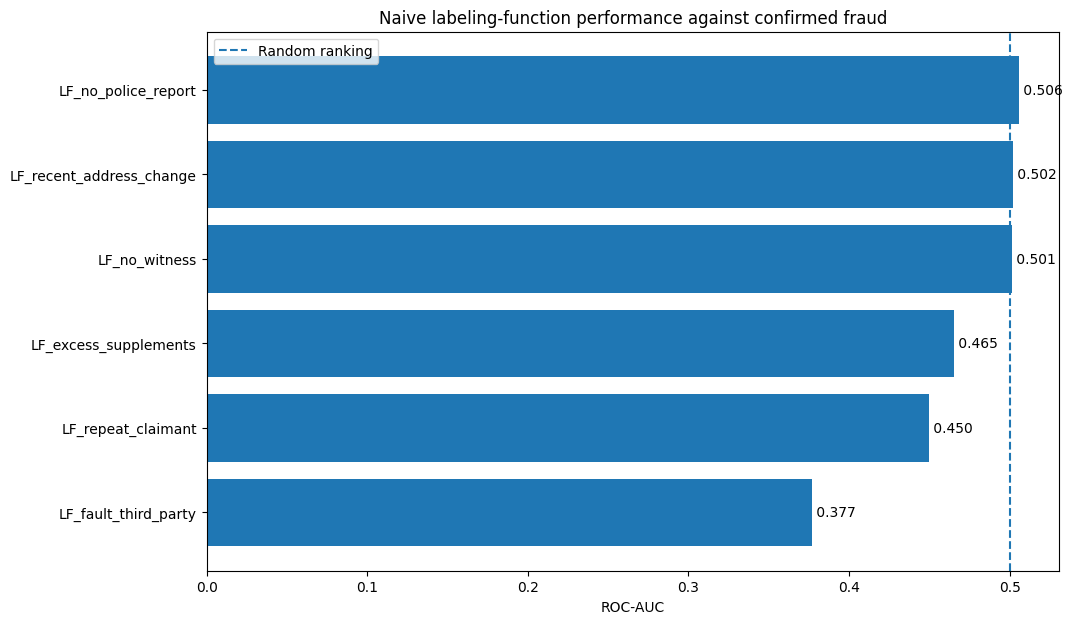

In [34]:
# Figure 6.5A — Naive labeling-function ROC-AUC
plot_data = (
    naive_lf_audit
    .dropna(subset=["ROC_AUC"])
    .sort_values("ROC_AUC")
)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    plot_data["LabelingFunction"],
    plot_data["ROC_AUC"],
)
ax.axvline(
    0.5,
    linestyle="--",
    label="Random ranking",
)
ax.set_title("Naive labeling-function performance against confirmed fraud")
ax.set_xlabel("ROC-AUC")
ax.legend()

for bar, value in zip(bars, plot_data["ROC_AUC"]):
    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.3f}",
        va="center",
    )

save_figure("G9_naive_labeling_function_roc_auc.png")
plt.show()

NameError: name 'save_figure' is not defined

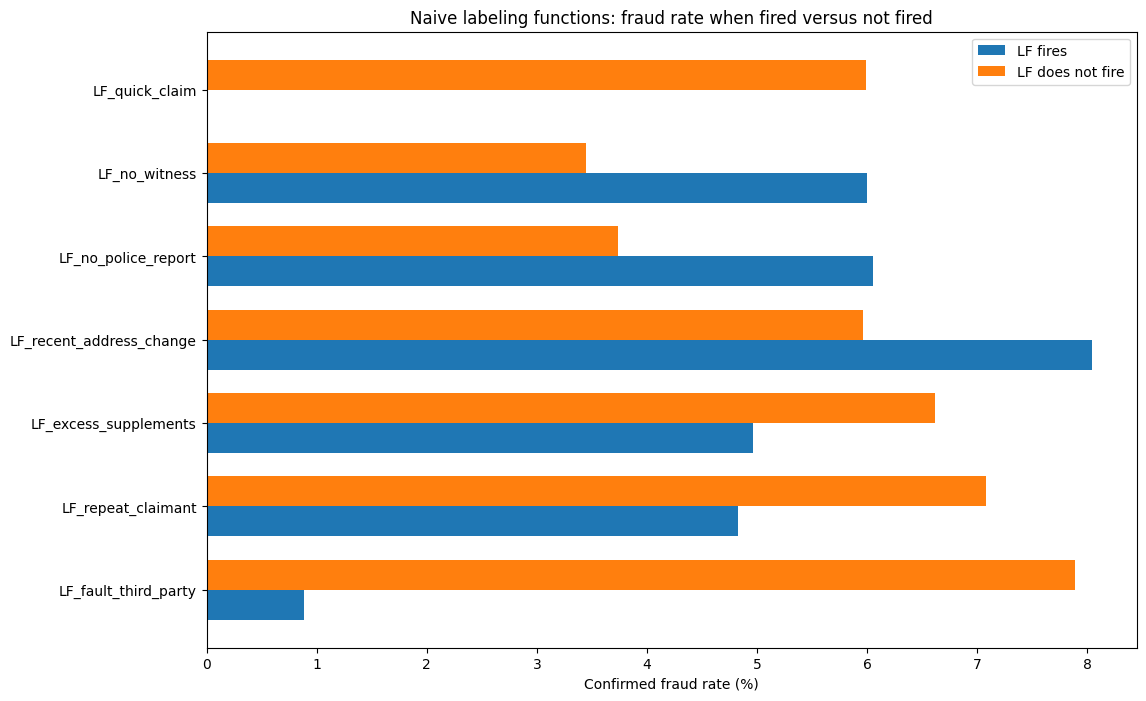

In [35]:
# Figure 6.5B — Fraud rate when each naive rule fires
plot_data = naive_lf_audit.sort_values(
    "FraudRateDifference"
)

y_positions = np.arange(len(plot_data))
bar_height = 0.36

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(
    y_positions - bar_height / 2,
    plot_data["FraudRateWhenFired"] * 100,
    height=bar_height,
    label="LF fires",
)
ax.barh(
    y_positions + bar_height / 2,
    plot_data["FraudRateWhenNotFired"] * 100,
    height=bar_height,
    label="LF does not fire",
)
ax.set_yticks(y_positions)
ax.set_yticklabels(plot_data["LabelingFunction"])
ax.set_xlabel("Confirmed fraud rate (%)")
ax.set_title("Naive labeling functions: fraud rate when fired versus not fired")
ax.legend()

save_figure("G10_naive_lf_fired_vs_not_fired.png")
plt.show()

## Phase 6.5.5 — Correct the labeling-function directions

The corrected rules use the empirical category directions discovered during the ground-truth audit:

- policyholder fault;
- non-liability base policy;
- first-time claimant;
- external agent;
- very early accident after policy inception;
- address change two to three years before the claim.

This is a diagnostic correction exercise. Because the directions were inspected using the known CarClaims labels, the corrected score is not presented as an independently validated production model.

In [36]:
def corrected_lf_fault_policyholder(data):
    return (data["Fault"] == "Policy Holder").astype(int)

def corrected_lf_basepolicy_not_liability(data):
    return (data["BasePolicy"] != "Liability").astype(int)

def corrected_lf_first_time_claimant(data):
    return (
        data["PastNumberOfClaims"] == "none"
    ).astype(int)

def corrected_lf_external_agent(data):
    return (data["AgentType"] == "External").astype(int)

def corrected_lf_quick_accident_after_policy(data):
    return (
        data["Days:Policy-Accident"] == "none"
    ).astype(int)

def corrected_lf_address_change_2to3yrs(data):
    return (
        data["AddressChange-Claim"] == "2 to 3 years"
    ).astype(int)


CORRECTED_LABELING_FUNCTIONS = {
    "LF_fault_policyholder": corrected_lf_fault_policyholder,
    "LF_basepolicy_not_liability": corrected_lf_basepolicy_not_liability,
    "LF_first_time_claimant": corrected_lf_first_time_claimant,
    "LF_external_agent": corrected_lf_external_agent,
    "LF_quick_accident_after_policy": corrected_lf_quick_accident_after_policy,
    "LF_address_change_2to3yrs": corrected_lf_address_change_2to3yrs,
}

for lf_name, lf_function in CORRECTED_LABELING_FUNCTIONS.items():
    df_lf_validation[lf_name] = lf_function(df_lf_validation)

corrected_lf_columns = list(CORRECTED_LABELING_FUNCTIONS)

corrected_lf_audit = audit_binary_labeling_functions(
    df_lf_validation,
    corrected_lf_columns,
)

display(corrected_lf_audit.round(4))

df_lf_validation["corrected_composite_score"] = (
    df_lf_validation[corrected_lf_columns].mean(axis=1)
)

corrected_roc_auc = roc_auc_score(
    df_lf_validation["FraudFound_true"],
    df_lf_validation["corrected_composite_score"],
)

corrected_pr_auc = average_precision_score(
    df_lf_validation["FraudFound_true"],
    df_lf_validation["corrected_composite_score"],
)

print("\nCorrected composite score versus confirmed labels")
print(f"ROC-AUC: {corrected_roc_auc:.3f}")
print(
    f"PR-AUC:  {corrected_pr_auc:.3f} "
    f"(no-skill baseline = "
    f"{df_lf_validation['FraudFound_true'].mean():.3f})"
)

corrected_lf_audit.to_csv(
    PROCESSED_DIR / "phase6_5_corrected_labeling_function_audit.csv",
    index=False,
)

,LabelingFunction,ROC_AUC,FireRate,FraudRateWhenFired,FraudRateWhenNotFired,FraudRateDifference
0,LF_fault_policyholder,0.6232,0.7283,0.0789,0.0088,0.0701
1,LF_basepolicy_not_liability,0.6520,0.6751,0.0852,0.0072,0.0780
2,LF_first_time_claimant,0.5453,0.2822,0.0779,0.0528,0.0251
3,LF_external_agent,0.5060,0.9844,0.0605,0.0166,0.0440
4,LF_quick_accident_after_policy,0.5033,0.0036,0.1636,0.0595,0.1041
5,LF_address_change_2to3yrs,0.5193,0.0189,0.1753,0.0576,0.1176



Corrected composite score versus confirmed labels
ROC-AUC: 0.738
PR-AUC:  0.113 (no-skill baseline = 0.060)


### Interpretation

The corrected composite produced approximately:

- **ROC-AUC: 0.738**
- **PR-AUC: 0.113**
- no-skill PR-AUC baseline: approximately 0.060

The improvement from 0.372 to 0.738 is the main result of this exercise. It shows that weak-label quality depends strongly on correct rule direction and empirical validation.

It does not prove that the CFPB labels are correct. Instead, it supports a stricter principle:

> Every labeling-function family should be validated against available ground truth, domain review, or independent evidence before being treated as a credible supervision source.

## Phase 6.5.6 — Compare naive and corrected composites visually

NameError: name 'save_figure' is not defined

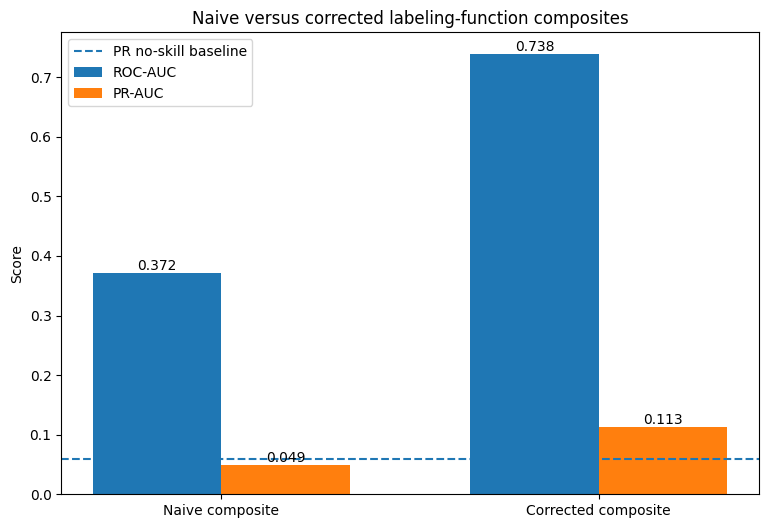

In [37]:
# Figure 6.5C — Composite discrimination comparison
composite_comparison = pd.DataFrame({
    "Method": [
        "Naive composite",
        "Corrected composite",
    ],
    "ROC_AUC": [
        naive_roc_auc,
        corrected_roc_auc,
    ],
    "PR_AUC": [
        naive_pr_auc,
        corrected_pr_auc,
    ],
})

x = np.arange(len(composite_comparison))
width = 0.34

fig, ax = plt.subplots(figsize=(9, 6))
bars_roc = ax.bar(
    x - width / 2,
    composite_comparison["ROC_AUC"],
    width,
    label="ROC-AUC",
)
bars_pr = ax.bar(
    x + width / 2,
    composite_comparison["PR_AUC"],
    width,
    label="PR-AUC",
)

ax.axhline(
    df_lf_validation["FraudFound_true"].mean(),
    linestyle="--",
    label="PR no-skill baseline",
)
ax.set_xticks(x)
ax.set_xticklabels(composite_comparison["Method"])
ax.set_ylabel("Score")
ax.set_title("Naive versus corrected labeling-function composites")
ax.legend()

for bars in [bars_roc, bars_pr]:
    for bar in bars:
        value = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f"{value:.3f}",
            ha="center",
            va="bottom",
        )

save_figure("G11_naive_vs_corrected_lf_composites.png")
plt.show()

composite_comparison.to_csv(
    PROCESSED_DIR / "phase6_5_composite_comparison.csv",
    index=False,
)

NameError: name 'save_figure' is not defined

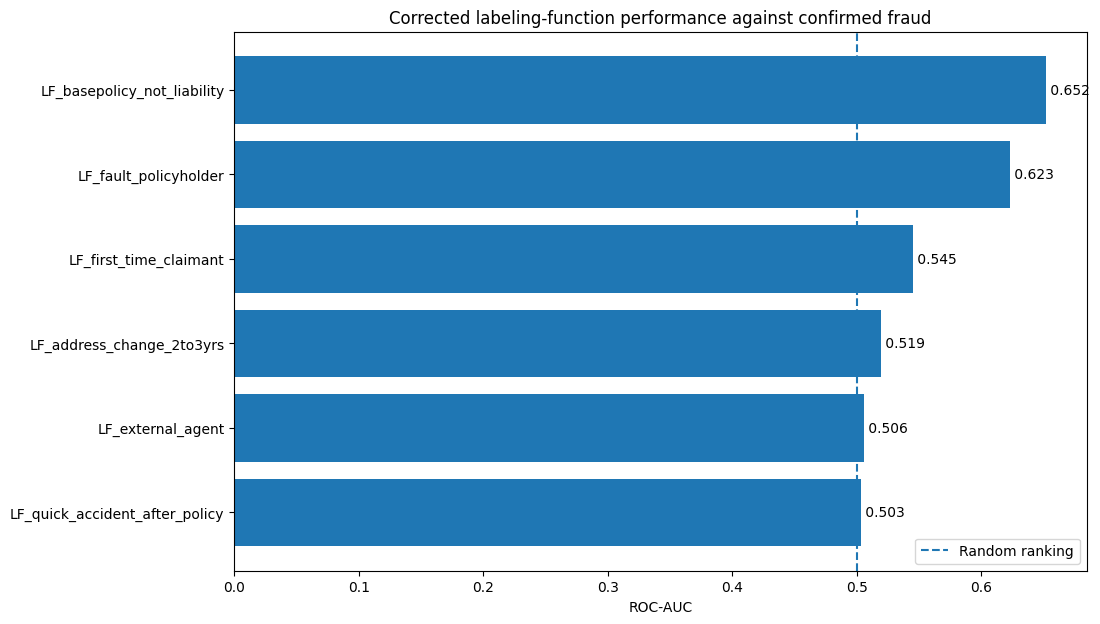

In [38]:
# Figure 6.5D — Corrected individual LF ROC-AUC
plot_data = (
    corrected_lf_audit
    .dropna(subset=["ROC_AUC"])
    .sort_values("ROC_AUC")
)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    plot_data["LabelingFunction"],
    plot_data["ROC_AUC"],
)
ax.axvline(
    0.5,
    linestyle="--",
    label="Random ranking",
)
ax.set_title("Corrected labeling-function performance against confirmed fraud")
ax.set_xlabel("ROC-AUC")
ax.legend()

for bar, value in zip(bars, plot_data["ROC_AUC"]):
    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.3f}",
        va="center",
    )

save_figure("G12_corrected_labeling_function_roc_auc.png")
plt.show()

## Phase 6.5.7 — Test the coherence-filtering rule

The same row-wise disagreement idea used in the narrative workflow is applied to the corrected binary labeling functions.

This test is expected to reproduce an important negative result: the 85th-percentile standard-deviation rule can exclude **zero records** because binary vote patterns produce a small number of tied standard-deviation values.

A negative diagnostic result is useful because it shows that the original coherence filter should not be described as validated merely because it was implemented.

In [39]:
df_lf_validation["corrected_lf_disagreement_std"] = (
    df_lf_validation[corrected_lf_columns]
    .std(axis=1)
)

lf_coherence_threshold = (
    df_lf_validation["corrected_lf_disagreement_std"]
    .quantile(0.85)
)

df_lf_validation["lf_is_uncertain"] = (
    df_lf_validation["corrected_lf_disagreement_std"]
    > lf_coherence_threshold
)

excluded_count = int(
    df_lf_validation["lf_is_uncertain"].sum()
)

excluded_percentage = (
    df_lf_validation["lf_is_uncertain"].mean() * 100
)

print(
    "Excluded as incoherent:",
    excluded_count,
    f"({excluded_percentage:.1f}%)",
)
print(
    "85th-percentile disagreement threshold:",
    round(lf_coherence_threshold, 4),
)
print("\nDisagreement-value frequencies:")
display(
    df_lf_validation[
        "corrected_lf_disagreement_std"
    ]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

Excluded as incoherent: 0 (0.0%)
85th-percentile disagreement threshold: 0.5477

Disagreement-value frequencies:


,count
corrected_lf_disagreement_std,
0.000000,26
0.408248,52
0.408248,664
0.516398,8479
0.547723,6198


### Coherence-filtering conclusion

If zero observations are excluded, the result should be reported explicitly. It indicates that a simple percentile threshold over binary-vote standard deviation is not sufficiently discriminative for this validation setting.

For the CFPB component, coherence filtering should therefore be justified through the continuous BART contradiction score and manual inspection, not through an unsupported claim that the binary CarClaims test validated the same threshold rule.

## Phase 6.5.8 — Independent CleanLab check

The corrected composite is converted to a median-split weak label. An independent Logistic Regression model is trained using features not directly referenced by the labeling functions:

- Age
- DriverRating
- VehicleCategory
- Make
- MaritalStatus
- Sex

Five-fold out-of-fold probabilities are supplied to CleanLab. This avoids the earlier circularity error of using the same weak score as both label and predicted probability.

In [40]:
df_lf_confident = df_lf_validation.loc[
    ~df_lf_validation["lf_is_uncertain"]
].copy()

corrected_score_median = (
    df_lf_confident["corrected_composite_score"]
    .median()
)

df_lf_confident["weak_hard_label"] = (
    df_lf_confident["corrected_composite_score"]
    >= corrected_score_median
).astype(int)

independent_features = [
    "Age",
    "DriverRating",
    "VehicleCategory",
    "Make",
    "MaritalStatus",
    "Sex",
]

missing_independent = [
    column
    for column in independent_features
    if column not in df_lf_confident.columns
]

if missing_independent:
    raise ValueError(
        "Independent validation features are missing: "
        f"{missing_independent}"
    )

X_lf_independent = pd.get_dummies(
    df_lf_confident[independent_features],
    drop_first=True,
)

y_lf_weak = (
    df_lf_confident["weak_hard_label"]
    .astype(int)
    .to_numpy()
)

lf_independent_classifier = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

lf_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

lf_oof_probabilities = cross_val_predict(
    lf_independent_classifier,
    X_lf_independent,
    y_lf_weak,
    cv=lf_cv,
    method="predict_proba",
    n_jobs=-1,
)

# Return ranked indices to reproduce the original experiment.
lf_issue_indices = find_label_issues(
    labels=y_lf_weak,
    pred_probs=lf_oof_probabilities,
    return_indices_ranked_by="self_confidence",
)

df_lf_confident["cleanlab_flagged"] = False

flag_column_index = (
    df_lf_confident.columns
    .get_loc("cleanlab_flagged")
)

df_lf_confident.iloc[
    lf_issue_indices,
    flag_column_index,
] = True

print(
    "CleanLab flagged:",
    len(lf_issue_indices),
    "/",
    len(df_lf_confident),
    f"({len(lf_issue_indices) / len(df_lf_confident) * 100:.1f}%)",
)

CleanLab flagged: 2846 / 15419 (18.5%)


## Phase 6.5.9 — Compare weak labels with ground truth before and after CleanLab

In [41]:
def weak_label_ground_truth_metrics(
    truth,
    prediction,
    stage,
):
    truth = np.asarray(truth).astype(int)
    prediction = np.asarray(prediction).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        truth,
        prediction,
    ).ravel()

    return {
        "Stage": stage,
        "Observations": len(truth),
        "Accuracy": accuracy_score(truth, prediction),
        "Precision": precision_score(
            truth,
            prediction,
            zero_division=0,
        ),
        "Recall": recall_score(
            truth,
            prediction,
            zero_division=0,
        ),
        "F1": f1_score(
            truth,
            prediction,
            zero_division=0,
        ),
        "MCC": matthews_corrcoef(
            truth,
            prediction,
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    }


before_cleanlab = weak_label_ground_truth_metrics(
    df_lf_confident["FraudFound_true"],
    df_lf_confident["weak_hard_label"],
    "Before CleanLab",
)

df_lf_after_cleanlab = df_lf_confident.loc[
    ~df_lf_confident["cleanlab_flagged"]
].copy()

after_cleanlab = weak_label_ground_truth_metrics(
    df_lf_after_cleanlab["FraudFound_true"],
    df_lf_after_cleanlab["weak_hard_label"],
    "After CleanLab",
)

lf_cleanlab_comparison = pd.DataFrame([
    before_cleanlab,
    after_cleanlab,
])

display(lf_cleanlab_comparison.round(4))

lf_cleanlab_comparison.to_csv(
    PROCESSED_DIR / "phase6_5_cleanlab_ground_truth_comparison.csv",
    index=False,
)

,Stage,Observations,Accuracy,Precision,Recall,F1,MCC,TN,FP,FN,TP
0,Before CleanLab,15419,0.4867,0.1014,0.9632,0.1835,0.2010,6616,7880,34,889
1,After CleanLab,12573,0.4324,0.1050,0.9664,0.1894,0.1884,4602,7108,29,834


### Expected interpretation of the original result

The initial experiment produced approximately:

| Stage | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|
| Before CleanLab | 0.487 | 0.101 | 0.963 | 0.183 |
| After CleanLab | 0.432 | 0.105 | 0.966 | 0.189 |

CleanLab slightly improved precision and F1 but reduced accuracy and removed approximately 18.5% of observations. This is **not strong evidence of successful noise removal**. It is a mixed result.

The defensible conclusion is:

> Independent probabilities corrected the circularity problem, but the CarClaims ground-truth exercise provided only limited evidence that CleanLab filtering improved the final weak labels. CleanLab should therefore be treated as a label-quality diagnostic rather than assumed to guarantee better labels.

NameError: name 'save_figure' is not defined

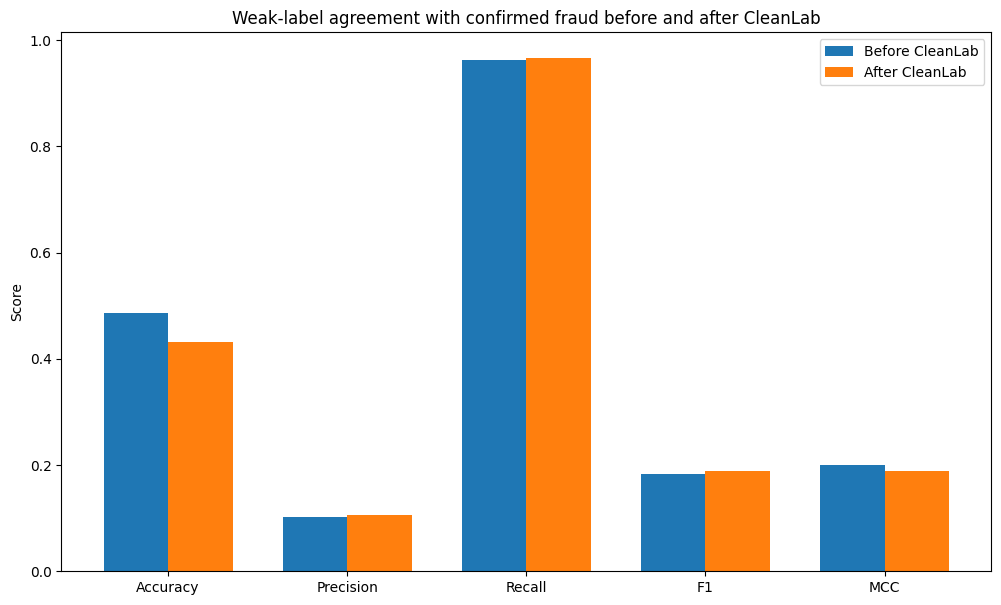

In [42]:
# Figure 6.5E — Before/after CleanLab metric comparison
cleanlab_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "MCC",
]

plot_df = (
    lf_cleanlab_comparison
    .set_index("Stage")[cleanlab_metrics]
)

x = np.arange(len(cleanlab_metrics))
width = 0.36

fig, ax = plt.subplots(figsize=(12, 7))

before_values = (
    plot_df.loc["Before CleanLab"]
    .to_numpy()
)
after_values = (
    plot_df.loc["After CleanLab"]
    .to_numpy()
)

bars_before = ax.bar(
    x - width / 2,
    before_values,
    width,
    label="Before CleanLab",
)

bars_after = ax.bar(
    x + width / 2,
    after_values,
    width,
    label="After CleanLab",
)

ax.set_xticks(x)
ax.set_xticklabels(cleanlab_metrics)
ax.set_ylabel("Score")
ax.set_title(
    "Weak-label agreement with confirmed fraud before and after CleanLab"
)
ax.legend()

save_figure("G13_cleanlab_ground_truth_metric_comparison.png")
plt.show()

NameError: name 'save_figure' is not defined

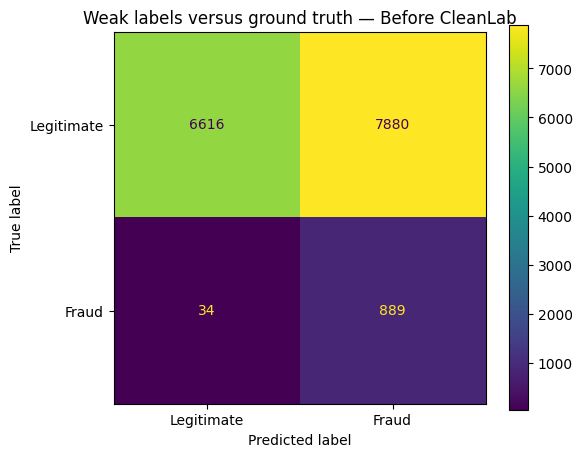

In [43]:
# Figure 6.5F — Weak-label confusion matrices
for stage_name, stage_df in {
    "Before CleanLab": df_lf_confident,
    "After CleanLab": df_lf_after_cleanlab,
}.items():
    fig, ax = plt.subplots(figsize=(6, 5))

    ConfusionMatrixDisplay.from_predictions(
        stage_df["FraudFound_true"],
        stage_df["weak_hard_label"],
        display_labels=["Legitimate", "Fraud"],
        values_format="d",
        ax=ax,
    )

    ax.set_title(
        f"Weak labels versus ground truth — {stage_name}"
    )

    safe_stage = stage_name.lower().replace(" ", "_")

    save_figure(
        f"G14_weak_label_confusion_matrix_{safe_stage}.png"
    )
    plt.show()

## Phase 6.5.10 — Save record-level validation outputs

In [44]:
validation_export_columns = [
    "FraudFound_true",
    "naive_composite_score",
    "corrected_composite_score",
    "corrected_lf_disagreement_std",
    "lf_is_uncertain",
]

available_export_columns = [
    column
    for column in validation_export_columns
    if column in df_lf_validation.columns
]

df_lf_validation[
    available_export_columns
].to_csv(
    PROCESSED_DIR / "phase6_5_record_level_lf_validation.csv",
    index=False,
)

df_lf_confident[
    [
        "FraudFound_true",
        "corrected_composite_score",
        "weak_hard_label",
        "cleanlab_flagged",
    ]
].to_csv(
    PROCESSED_DIR / "phase6_5_cleanlab_record_validation.csv",
    index=False,
)

print("Phase 6.5 validation outputs saved.")

Phase 6.5 validation outputs saved.


## Phase 6.5.11 — Final methodological conclusion

This exercise contributes three original findings:

1. **Plausible heuristics can be inversely predictive.**  
   The naive composite achieved ROC-AUC of approximately 0.372.

2. **Empirical direction checking materially improves weak supervision.**  
   Correcting the rule directions increased ROC-AUC to approximately 0.738 and PR-AUC to approximately 0.113.

3. **Label refinement is not automatically beneficial.**  
   The binary disagreement filter excluded no records, while CleanLab produced only a marginal F1 improvement and reduced accuracy.

### Recommended thesis wording

> A ground-truth validation exercise was conducted on the labelled CarClaims dataset to assess the methodological reliability of heuristic labeling functions before applying weak supervision to unlabelled complaint narratives. An initial set of intuitively plausible rules produced an ROC-AUC of 0.372 against confirmed fraud labels, demonstrating that several assumed risk directions were incorrect. Individual rule auditing was therefore used to inspect firing rates and conditional fraud prevalence. After correcting the rule directions, the composite score increased to an ROC-AUC of 0.738 and a PR-AUC of 0.113, compared with a no-skill PR-AUC baseline of approximately 0.060. This result demonstrated the importance of empirical labeling-function validation. A subsequent CleanLab experiment, using independent out-of-fold probabilities, produced only a marginal improvement in F1 and did not consistently improve agreement with ground truth. CleanLab was consequently retained as a diagnostic label-quality mechanism rather than treated as evidence that weak labels were automatically corrected.

### Limitation

The corrected rules were selected after inspecting CarClaims ground truth. Their 0.738 ROC-AUC is therefore an internal methodological demonstration, not an unbiased estimate of performance on new datasets. A stronger future evaluation would derive rules on one labelled partition and assess them on a separate untouched partition.

# Phase 7 — Evidence-stream integration

## Relationship between CarClaims and CFPB

There is no defensible row-level relationship between the two datasets:

- CarClaims contains automobile insurance claim records and the confirmed `FraudFound` label.
- CFPB contains consumer financial complaint narratives and no confirmed fraud label.
- They share no claim ID, complaint ID, customer ID, policy ID, date key or transaction key that would support a valid join.

Accordingly, the datasets are not concatenated or merged. They are integrated in Power BI as separate fact tables connected only to optional shared presentation dimensions such as `EvidenceStream`, `RiskBand` and reporting date. This is decision-support integration, not case-level data fusion.


In [45]:
# =========================================================
# POWER BI EXPORTS — STRUCTURED CARCLAIMS STREAM
# =========================================================

# The balanced test set contains encoded and synthetic observations.
# Export the selected features plus model outputs for reproducible dashboards.
structured_export = X_test_20.reset_index(drop=True).copy()
structured_export.insert(
    0,
    "StructuredRecordID",
    [f"CAR_TEST_{i:06d}" for i in range(1, len(structured_export) + 1)],
)
structured_export["ActualFraud"] = y_test.reset_index(drop=True)
structured_export["PredictedFraudProbability"] = best_probability
structured_export["PredictedFraudClass"] = best_prediction
structured_export["Model"] = BEST_MODEL_NAME
structured_export["Threshold"] = BEST_THRESHOLD
structured_export["EvidenceStream"] = "CarClaims structured"
structured_export["EvaluationDataset"] = "SMOTE-balanced test set"
structured_export["RiskBand"] = pd.cut(
    structured_export["PredictedFraudProbability"],
    bins=[-np.inf, 0.25, 0.50, 0.75, np.inf],
    labels=["Low", "Moderate", "High", "Very high"],
)

structured_export.to_csv(
    DASHBOARD_DIR / "structured_predictions.csv",
    index=False,
)

test_results.to_csv(
    DASHBOARD_DIR / "structured_model_comparison.csv",
    index=False,
)

validation_results.to_csv(
    DASHBOARD_DIR / "structured_validation_comparison.csv",
    index=False,
)

# =========================================================
# POWER BI EXPORTS — CFPB NARRATIVE STREAM
# =========================================================
high_quality_path = PROCESSED_DIR / "cfpb_high_quality_labels.parquet"

if high_quality_path.exists():
    df_high_quality = pd.read_parquet(high_quality_path).copy()
    df_high_quality.insert(
        0,
        "NarrativeRecordID",
        [f"CFPB_{i:06d}" for i in range(1, len(df_high_quality) + 1)],
    )
    df_high_quality["EvidenceStream"] = "CFPB narrative"
    df_high_quality["RiskBand"] = pd.cut(
        df_high_quality["raw_fraud_risk"],
        bins=[-np.inf, 0.25, 0.50, 0.75, np.inf],
        labels=["Low", "Moderate", "High", "Very high"],
    )

    narrative_columns = [
        column for column in [
            "NarrativeRecordID",
            "Complaint ID",
            "Date received",
            "Product",
            "ProductGroup",
            "Issue",
            "Company",
            "State",
            "clean_text",
            "behavioural_risk",
            "transactional_risk",
            "raw_fraud_risk",
            "weak_fraud_label",
            "label_quality_score",
            "RiskBand",
            "EvidenceStream",
        ]
        if column in df_high_quality.columns
    ]

    df_high_quality[narrative_columns].to_csv(
        DASHBOARD_DIR / "narrative_fraud_risk.csv",
        index=False,
    )

# A simple stream dimension supports dashboard navigation without
# falsely joining unrelated records.
evidence_stream_dimension = pd.DataFrame([
    {
        "EvidenceStream": "CarClaims structured",
        "LabelType": "Confirmed supervised label",
        "TargetOrScore": "FraudFound / predicted fraud probability",
        "JoinPolicy": "No case-level join with CFPB",
    },
    {
        "EvidenceStream": "CFPB narrative",
        "LabelType": "Weak fraud-risk label",
        "TargetOrScore": "Composite BART fraud-risk score",
        "JoinPolicy": "No case-level join with CarClaims",
    },
])

evidence_stream_dimension.to_csv(
    DASHBOARD_DIR / "evidence_stream_dimension.csv",
    index=False,
)

print("Dashboard files saved to:", DASHBOARD_DIR)


Dashboard files saved to: /content/drive/MyDrive/Thesis/data/dashboard


# Phase 8 — Dashboard summaries and final evaluation outputs

The generated CSV files can be imported directly into Power BI.

Recommended dashboard pages:

1. Executive overview  
2. Structured model comparison  
3. Claim-level fraud screening  
4. SHAP explainability  
5. CFPB product and issue analysis  
6. Narrative fraud-risk analysis  
7. Data-quality and methodology notes

In [46]:
# Summary KPIs for Power BI
best_row = test_results.iloc[0]

structured_kpis = pd.DataFrame([{
    "BestModel": BEST_MODEL_NAME,
    "SelectedFeatureCount": len(SELECTED_FEATURES),
    "OriginalFraudPrevalence": y_original.mean(),
    "BalancedTestFraudPrevalence": y_test.mean(),
    "SMOTEPlacement": "Before train-validation-test split",
    "Threshold": BEST_THRESHOLD,
    "Accuracy": best_row["Accuracy"],
    "Precision": best_row["Precision"],
    "Recall": best_row["Recall"],
    "F1": best_row["F1"],
    "MCC": best_row["MCC"],
    "ROC_AUC": best_row["ROC_AUC"],
    "PR_AUC": best_row["PR_AUC"],
}])

structured_kpis.to_csv(
    DASHBOARD_DIR / "structured_kpis.csv",
    index=False,
)

selected_features_table = pd.DataFrame({
    "Rank": range(1, len(SELECTED_FEATURES) + 1),
    "SelectedFeature": SELECTED_FEATURES,
})

selected_features_table.to_csv(
    DASHBOARD_DIR / "selected_20_features.csv",
    index=False,
)

label_dictionary = pd.DataFrame([
    {
        "Dataset": "CarClaims",
        "Field": "FraudFound",
        "LabelType": "Confirmed ground truth",
        "MeaningOf1": "Confirmed fraudulent insurance claim",
        "MeaningOf0": "Legitimate insurance claim",
        "UsedFor": "Supervised structured classification",
    },
    {
        "Dataset": "CFPB",
        "Field": "weak_fraud_label",
        "LabelType": "Weak label",
        "MeaningOf1": "Higher fraud-risk narrative",
        "MeaningOf0": "Lower fraud-risk narrative",
        "UsedFor": "Narrative risk estimation; not confirmed fraud classification",
    },
])

label_dictionary.to_csv(
    DASHBOARD_DIR / "label_dictionary.csv",
    index=False,
)

display(structured_kpis.round(4))
display(selected_features_table)
display(label_dictionary)

print("\nPhase 1–8 pipeline complete.")
print("Best structured model:", BEST_MODEL_NAME)
print("Exactly 20 selected features:", len(SELECTED_FEATURES))
print("Exactly 11 classifiers evaluated:", len(classifiers))


,BestModel,SelectedFeatureCount,OriginalFraudPrevalence,BalancedTestFraudPrevalence,SMOTEPlacement,Threshold,Accuracy,Precision,Recall,F1,MCC,ROC_AUC,PR_AUC
0,Random Forest,20,0.0599,0.4999,Before train-validation-test split,0.452,0.9628,0.9783,0.9465,0.9621,0.926,0.9894,0.9917


,Rank,SelectedFeature
0,1,WeekOfMonth
1,2,WeekOfMonthClaimed
2,3,Age
3,4,Month_Jan
4,5,Month_Mar
5,6,DayOfWeek_Sunday
6,7,Make_Chevrolet
7,8,Make_Pontiac
8,9,Make_Saab
9,10,DayOfWeekClaimed_Monday


,Dataset,Field,LabelType,MeaningOf1,MeaningOf0,UsedFor
0,CarClaims,FraudFound,Confirmed ground truth,Confirmed fraudulent insurance claim,Legitimate insurance claim,Supervised structured classification
1,CFPB,weak_fraud_label,Weak label,Higher fraud-risk narrative,Lower fraud-risk narrative,Narrative risk estimation; not confirmed fraud...



Phase 1–8 pipeline complete.
Best structured model: Random Forest
Exactly 20 selected features: 20
Exactly 11 classifiers evaluated: 11


# Final reporting guidance

## CarClaims label

The main CarClaims model uses the dataset's genuine investigator-confirmed `FraudFound` target. The Phase 6.5 labelling functions are only a methodological validation experiment for the weak-supervision concept; they do not replace `FraudFound`.

## CFPB label

CFPB contains no confirmed fraud target. Its `weak_fraud_label` is derived from BART hypothesis scores, coherence filtering and independent CleanLab diagnostics. It must be described as a fraud-risk label rather than proven fraud.

## Dataset integration

Do not merge CarClaims and CFPB records. Present them as complementary structured and narrative evidence streams in separate dashboard tables.

## Evaluation limitation

The primary structured results in this notebook use SMOTE before splitting to reproduce the reference-paper preprocessing requested by the supervisor. Consequently, the test set is 50% fraud and contains synthetic observations. This must be reported explicitly when interpreting the high model metrics.


# Publication-quality figures and plots

This section adds the complete visualisation layer for the thesis.

All figures are:

- generated with Matplotlib;
- saved automatically to `FIGURES_DIR`;
- exported at 300 dpi;
- assigned consistent descriptive filenames;
- created only when the required variables or files are available.

The figure set covers:

1. structured-data EDA;
2. narrative-data EDA;
3. PSO convergence and selected-feature analysis;
4. comparison of all 11 classifiers;
5. confusion matrices and diagnostic curves;
6. SHAP global and local explanations;
7. BART hypothesis and CleanLab diagnostics;
8. dashboard-preview charts;
9. end-to-end methodology diagrams.

In [47]:
# Global figure settings
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 120,
})

def save_figure(filename, tight=True):
    path = FIGURES_DIR / filename
    if tight:
        plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved:", path)

## A. Structured-data exploratory figures

Saved: /content/drive/MyDrive/Thesis/figures/A1_carclaims_class_distribution.png


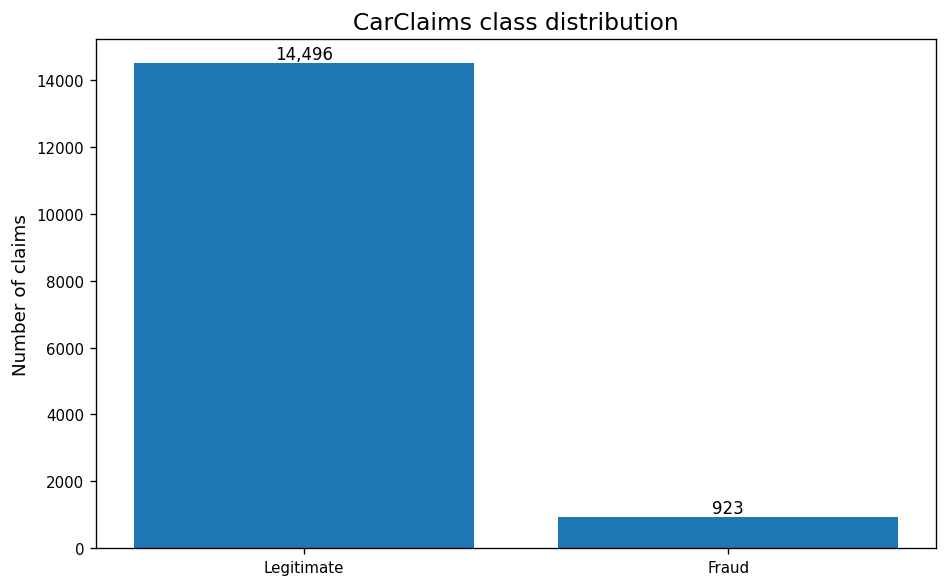

In [48]:
# Figure A1 — Class distribution
class_counts = df_car[TARGET].value_counts().sort_index()
labels = ["Legitimate", "Fraud"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, class_counts.values)
ax.set_title("CarClaims class distribution")
ax.set_ylabel("Number of claims")

for bar, value in zip(bars, class_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom",
    )

save_figure("A1_carclaims_class_distribution.png")
plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/A2_carclaims_class_proportions.png


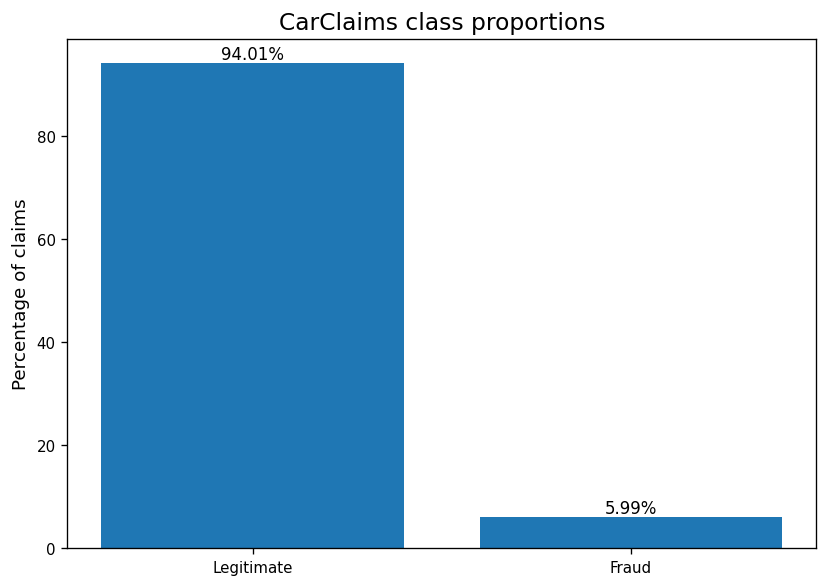

In [49]:
# Figure A2 — Class proportion
class_proportions = (
    df_car[TARGET]
    .value_counts(normalize=True)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, class_proportions.values * 100)
ax.set_title("CarClaims class proportions")
ax.set_ylabel("Percentage of claims")

for bar, value in zip(bars, class_proportions.values * 100):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom",
    )

save_figure("A2_carclaims_class_proportions.png")
plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/A3_age_distribution_by_fraud.png


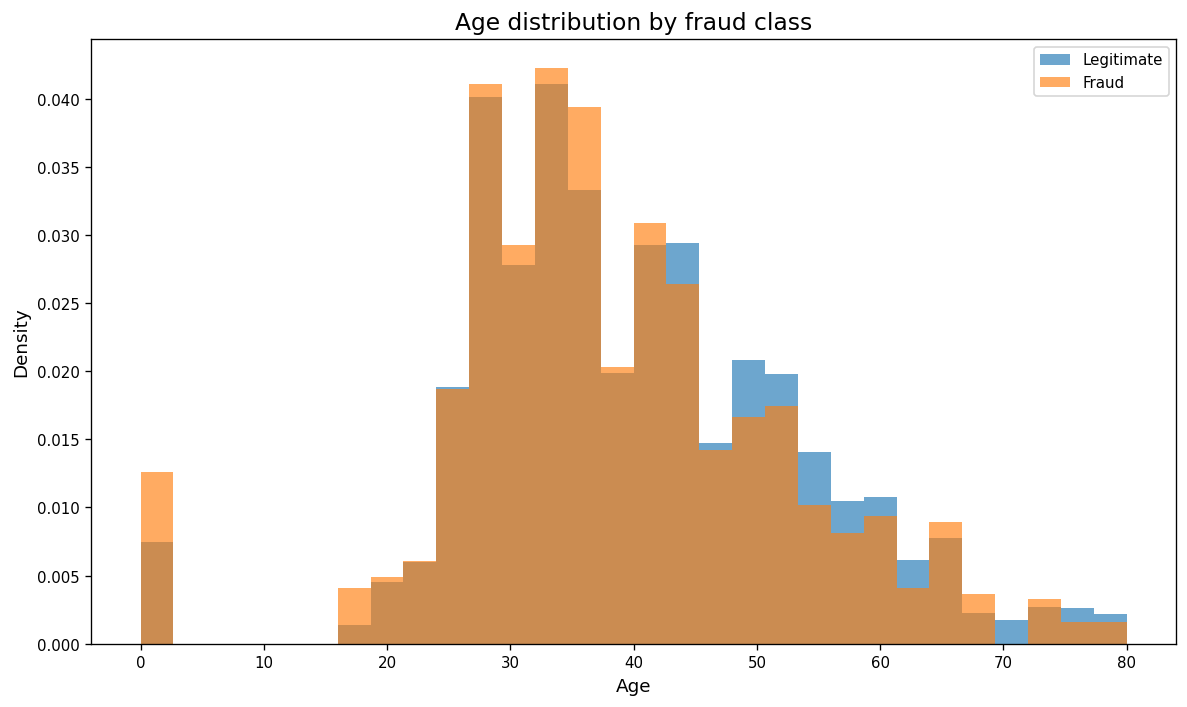

In [50]:
# Figure A3 — Age distribution by fraud class
if "Age" in df_car.columns:
    fig, ax = plt.subplots(figsize=(10, 6))

    legitimate_age = df_car.loc[
        df_car[TARGET] == 0,
        "Age"
    ].dropna()

    fraud_age = df_car.loc[
        df_car[TARGET] == 1,
        "Age"
    ].dropna()

    ax.hist(
        legitimate_age,
        bins=30,
        alpha=0.65,
        density=True,
        label="Legitimate",
    )
    ax.hist(
        fraud_age,
        bins=30,
        alpha=0.65,
        density=True,
        label="Fraud",
    )

    ax.set_title("Age distribution by fraud class")
    ax.set_xlabel("Age")
    ax.set_ylabel("Density")
    ax.legend()

    save_figure("A3_age_distribution_by_fraud.png")
    plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/A4_fraud_rate_by_accident_area.png


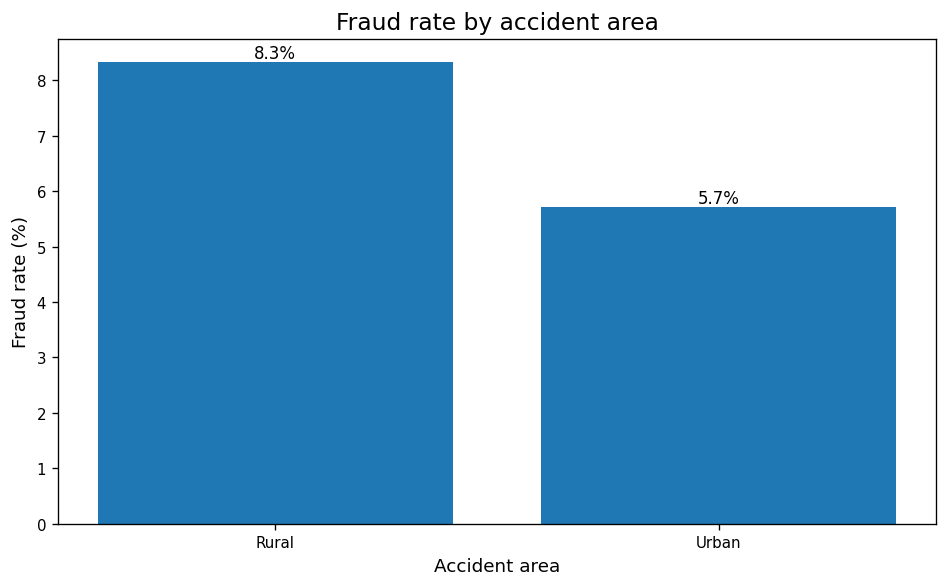

In [51]:
# Figure A4 — Fraud rate by AccidentArea
if "AccidentArea" in df_car.columns:
    fraud_by_area = (
        df_car.groupby("AccidentArea")[TARGET]
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(fraud_by_area.index.astype(str), fraud_by_area.values)
    ax.set_title("Fraud rate by accident area")
    ax.set_ylabel("Fraud rate (%)")
    ax.set_xlabel("Accident area")

    for bar, value in zip(bars, fraud_by_area.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f"{value:.1f}%",
            ha="center",
            va="bottom",
        )

    save_figure("A4_fraud_rate_by_accident_area.png")
    plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/A5_fraud_rate_by_base_policy.png


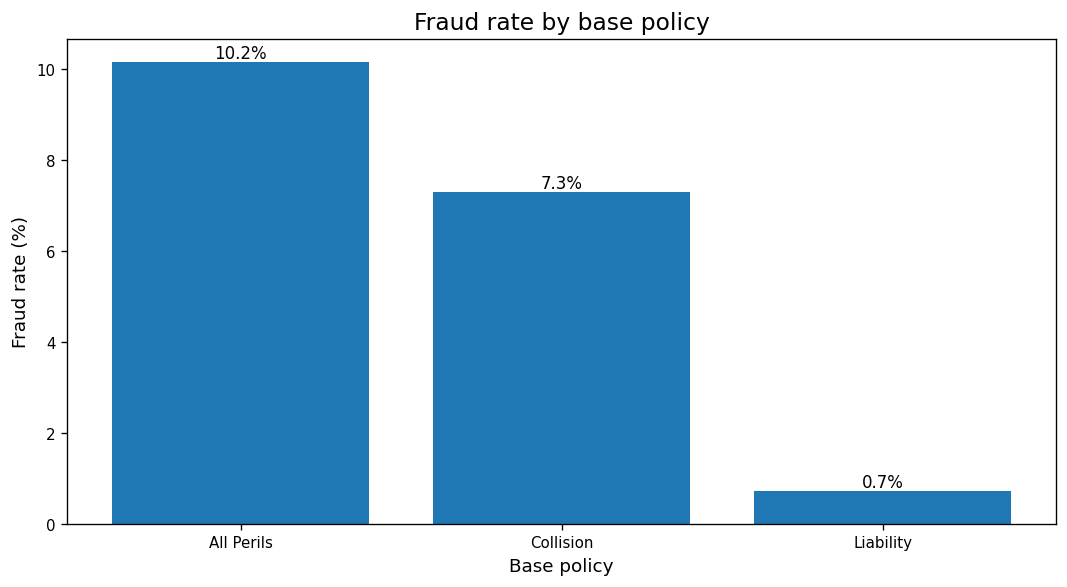

In [52]:
# Figure A5 — Fraud rate by BasePolicy
if "BasePolicy" in df_car.columns:
    fraud_by_policy = (
        df_car.groupby("BasePolicy")[TARGET]
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(
        fraud_by_policy.index.astype(str),
        fraud_by_policy.values,
    )
    ax.set_title("Fraud rate by base policy")
    ax.set_ylabel("Fraud rate (%)")
    ax.set_xlabel("Base policy")

    for bar, value in zip(bars, fraud_by_policy.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f"{value:.1f}%",
            ha="center",
            va="bottom",
        )

    save_figure("A5_fraud_rate_by_base_policy.png")
    plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/A6_fraud_rate_by_fault.png


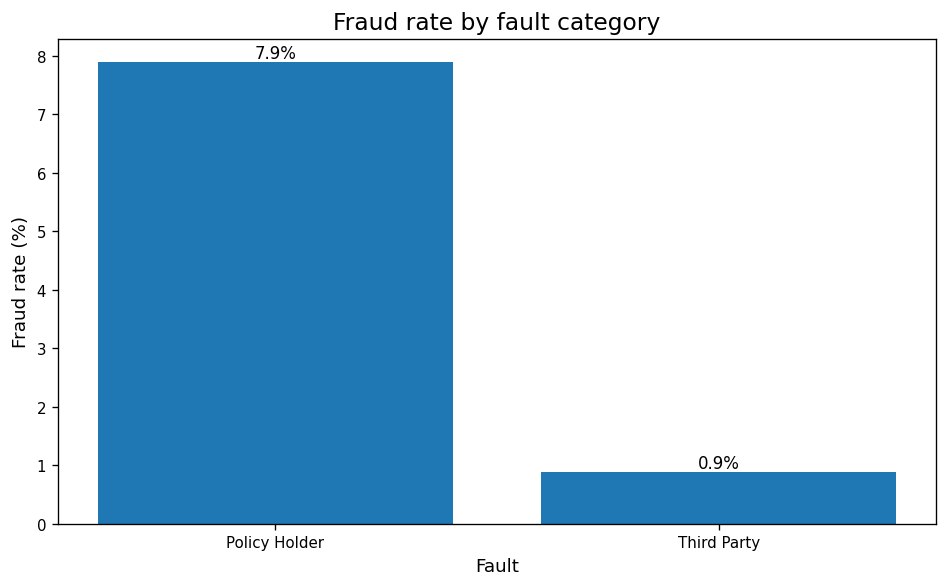

In [53]:
# Figure A6 — Fraud rate by Fault
if "Fault" in df_car.columns:
    fraud_by_fault = (
        df_car.groupby("Fault")[TARGET]
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(
        fraud_by_fault.index.astype(str),
        fraud_by_fault.values,
    )
    ax.set_title("Fraud rate by fault category")
    ax.set_ylabel("Fraud rate (%)")
    ax.set_xlabel("Fault")

    for bar, value in zip(bars, fraud_by_fault.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f"{value:.1f}%",
            ha="center",
            va="bottom",
        )

    save_figure("A6_fraud_rate_by_fault.png")
    plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/A7_fraud_rate_top_vehicle_makes.png


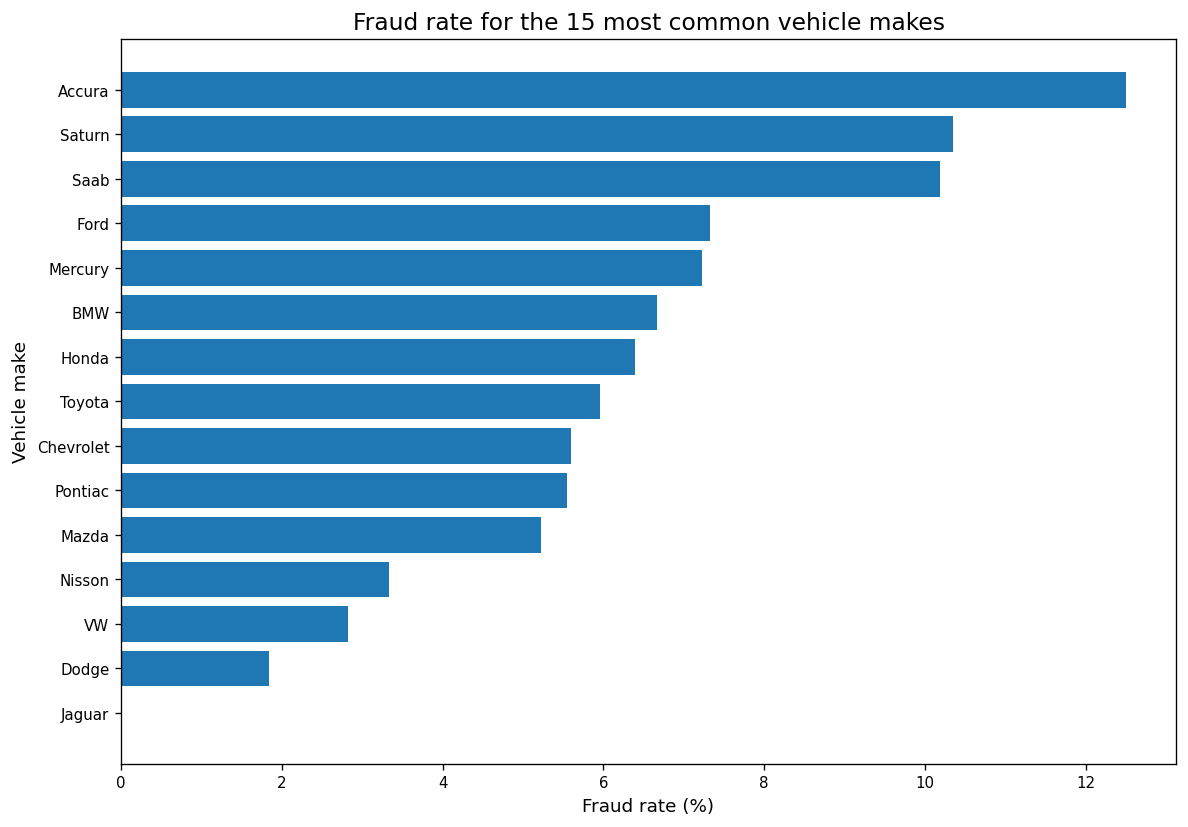

In [54]:
# Figure A7 — Fraud rate by Make (top 15 by record count)
if "Make" in df_car.columns:
    top_makes = (
        df_car["Make"]
        .value_counts()
        .head(15)
        .index
    )

    fraud_by_make = (
        df_car[df_car["Make"].isin(top_makes)]
        .groupby("Make")[TARGET]
        .mean()
        .sort_values()
        * 100
    )

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(
        fraud_by_make.index.astype(str),
        fraud_by_make.values,
    )
    ax.set_title("Fraud rate for the 15 most common vehicle makes")
    ax.set_xlabel("Fraud rate (%)")
    ax.set_ylabel("Vehicle make")

    save_figure("A7_fraud_rate_top_vehicle_makes.png")
    plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/A8_numeric_correlation_heatmap.png


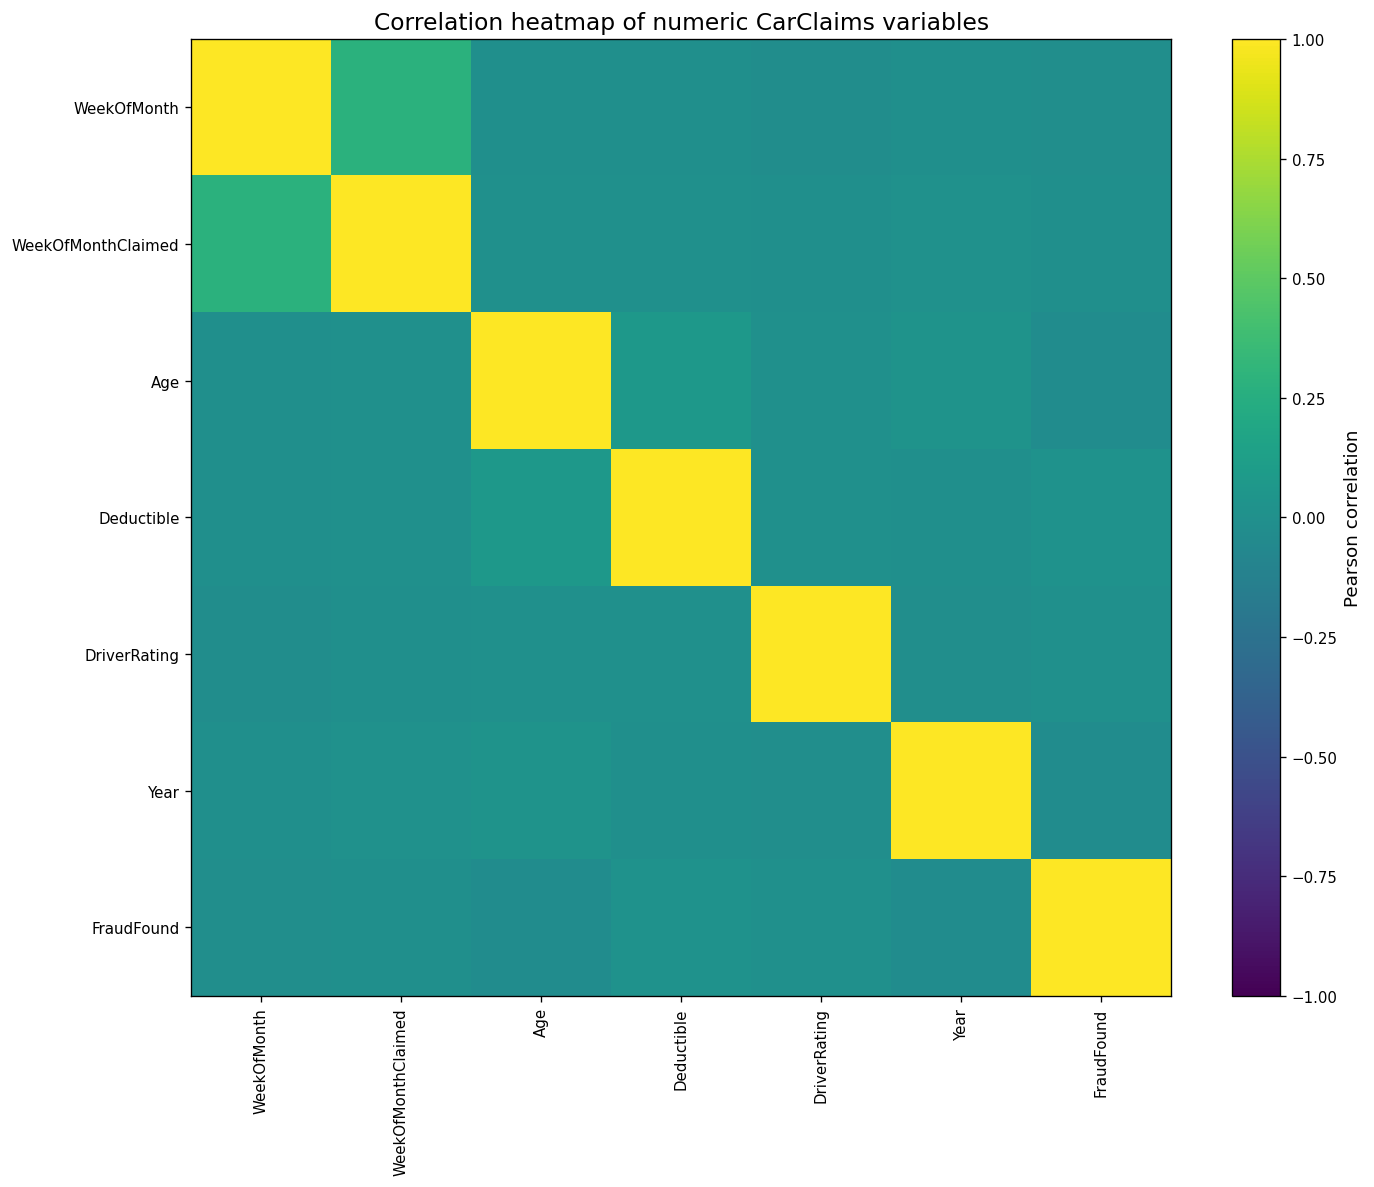

In [55]:
# Figure A8 — Numeric correlation heatmap
numeric_df = df_car.select_dtypes(include=np.number).copy()

if numeric_df.shape[1] >= 2:
    corr = numeric_df.corr()

    fig, ax = plt.subplots(figsize=(12, 10))
    image = ax.imshow(
        corr.values,
        aspect="auto",
        vmin=-1,
        vmax=1,
    )
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticks(range(len(corr.columns)))
    ax.set_yticklabels(corr.columns)
    ax.set_title("Correlation heatmap of numeric CarClaims variables")
    fig.colorbar(image, ax=ax, label="Pearson correlation")

    save_figure("A8_numeric_correlation_heatmap.png")
    plt.show()

## B. Narrative-data exploratory figures

Saved: /content/drive/MyDrive/Thesis/figures/B1_cfpb_product_group_distribution.png


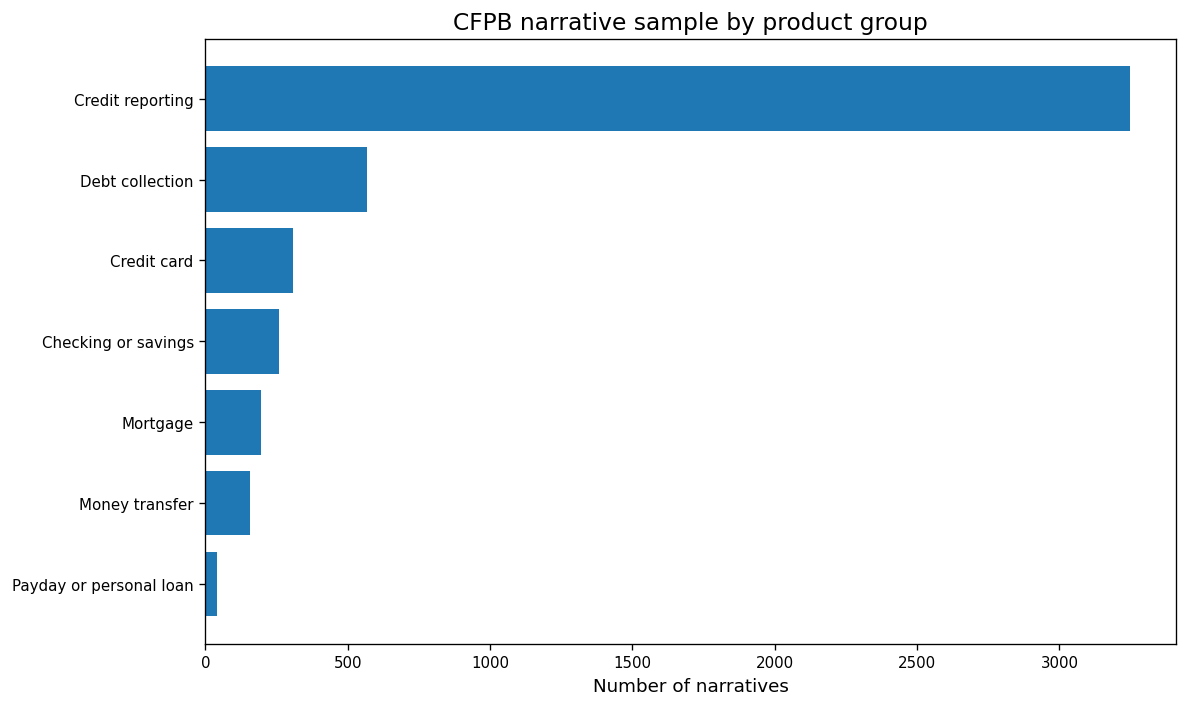

In [56]:
# Figure B1 — Product-group distribution
clean_sample_path = PROCESSED_DIR / "cfpb_sample_clean.parquet"

if clean_sample_path.exists():
    df_cfpb_fig = pd.read_parquet(clean_sample_path)

    product_counts = (
        df_cfpb_fig["ProductGroup"]
        .value_counts()
        .sort_values()
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(
        product_counts.index.astype(str),
        product_counts.values,
    )
    ax.set_title("CFPB narrative sample by product group")
    ax.set_xlabel("Number of narratives")

    save_figure("B1_cfpb_product_group_distribution.png")
    plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/B2_cfpb_narrative_length_distribution.png


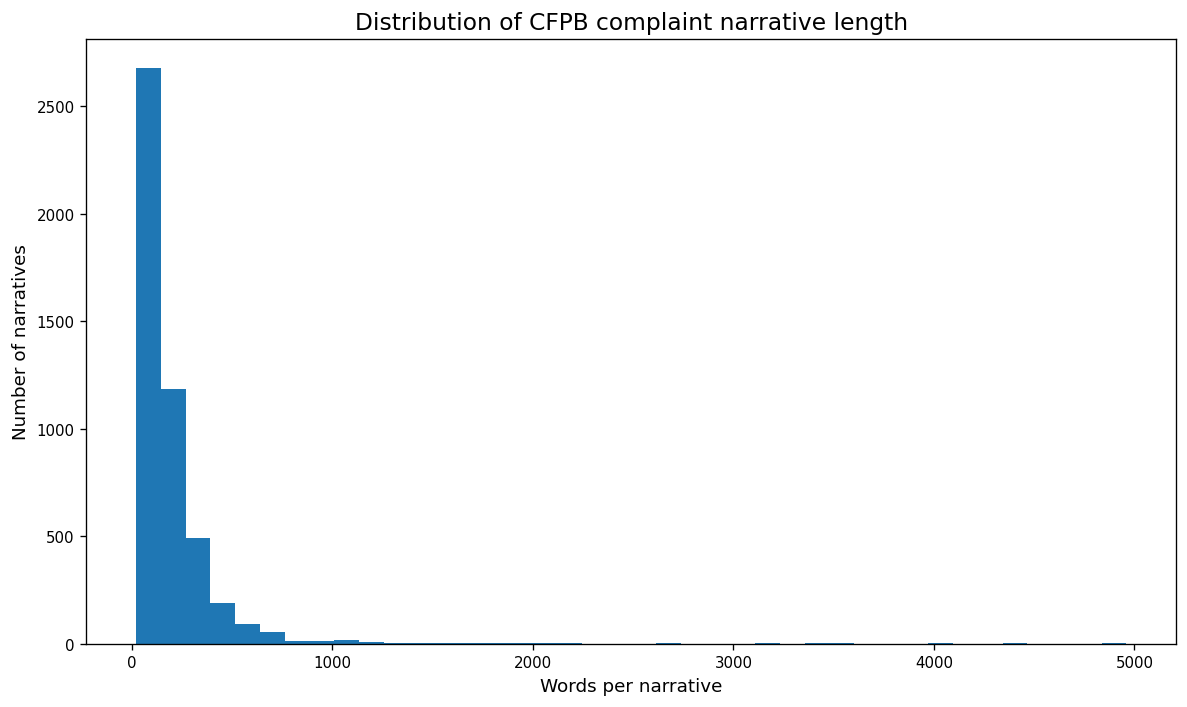

In [57]:
# Figure B2 — Complaint length histogram
if clean_sample_path.exists():
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(
        df_cfpb_fig["text_length_words"],
        bins=40,
    )
    ax.set_title("Distribution of CFPB complaint narrative length")
    ax.set_xlabel("Words per narrative")
    ax.set_ylabel("Number of narratives")

    save_figure("B2_cfpb_narrative_length_distribution.png")
    plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/B3_top_20_cfpb_issues.png


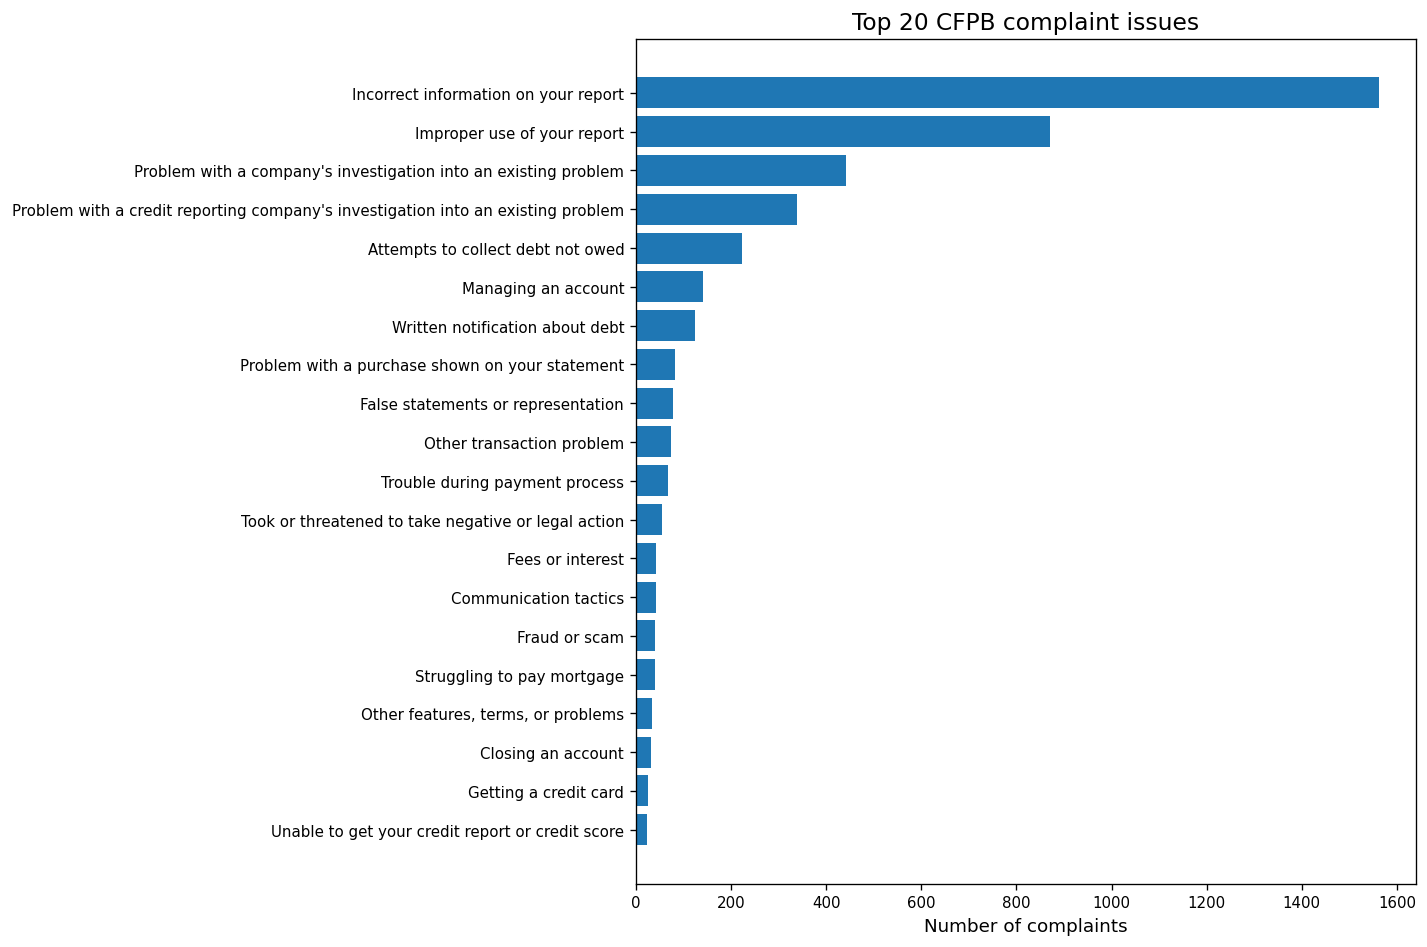

In [58]:
# Figure B3 — Top 20 complaint issues
if clean_sample_path.exists() and "Issue" in df_cfpb_fig.columns:
    top_issues = (
        df_cfpb_fig["Issue"]
        .value_counts()
        .head(20)
        .sort_values()
    )

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(
        top_issues.index.astype(str),
        top_issues.values,
    )
    ax.set_title("Top 20 CFPB complaint issues")
    ax.set_xlabel("Number of complaints")

    save_figure("B3_top_20_cfpb_issues.png")
    plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/B4_top_20_cfpb_companies.png


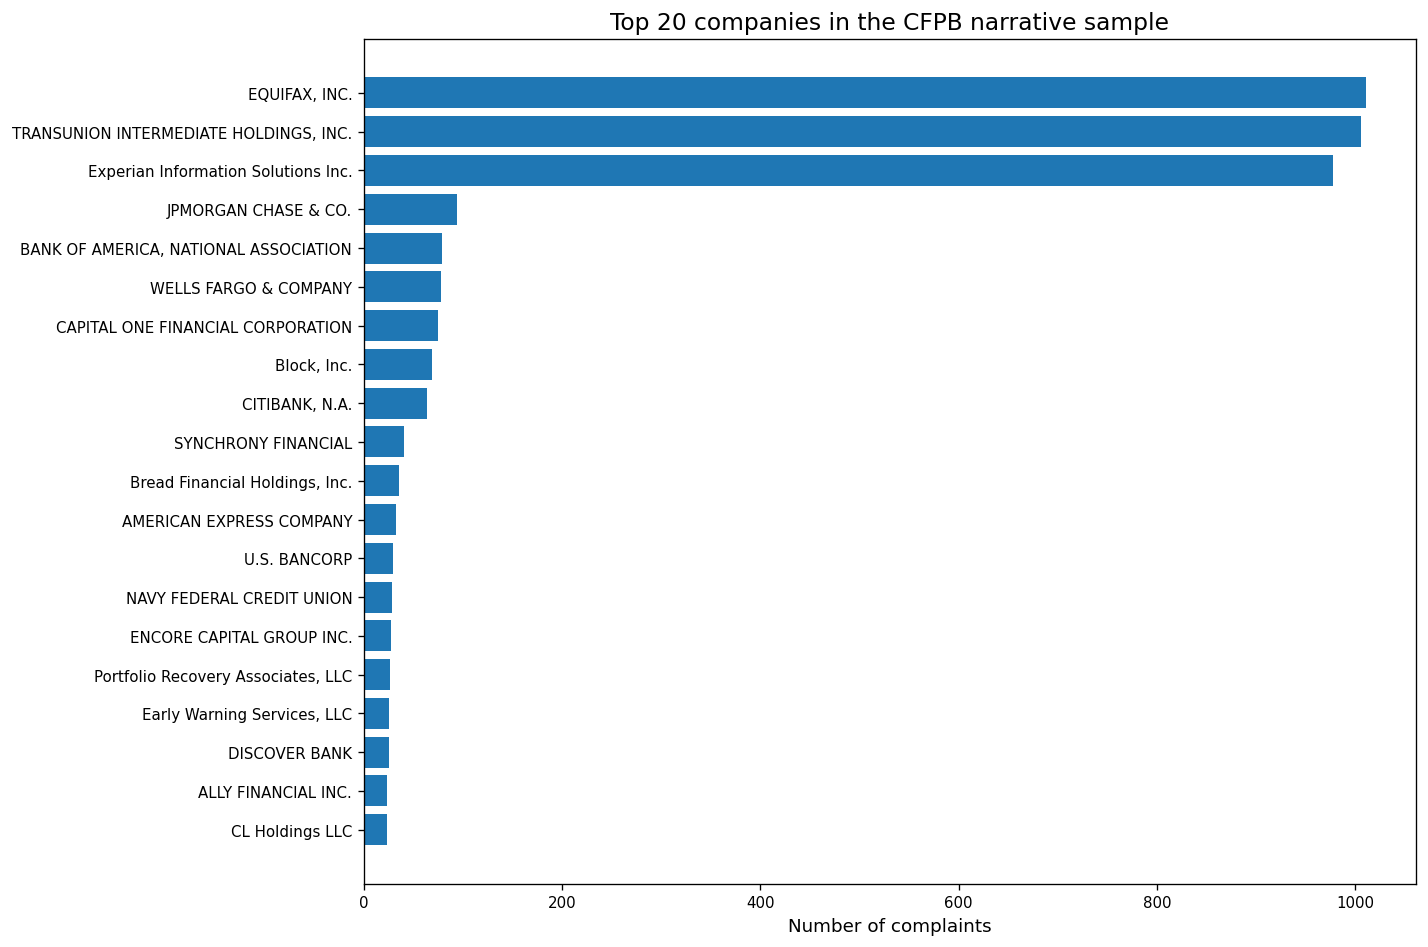

In [59]:
# Figure B4 — Top 20 companies
if clean_sample_path.exists() and "Company" in df_cfpb_fig.columns:
    top_companies = (
        df_cfpb_fig["Company"]
        .value_counts()
        .head(20)
        .sort_values()
    )

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(
        top_companies.index.astype(str),
        top_companies.values,
    )
    ax.set_title("Top 20 companies in the CFPB narrative sample")
    ax.set_xlabel("Number of complaints")

    save_figure("B4_top_20_cfpb_companies.png")
    plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/B5_cfpb_wordcloud.png


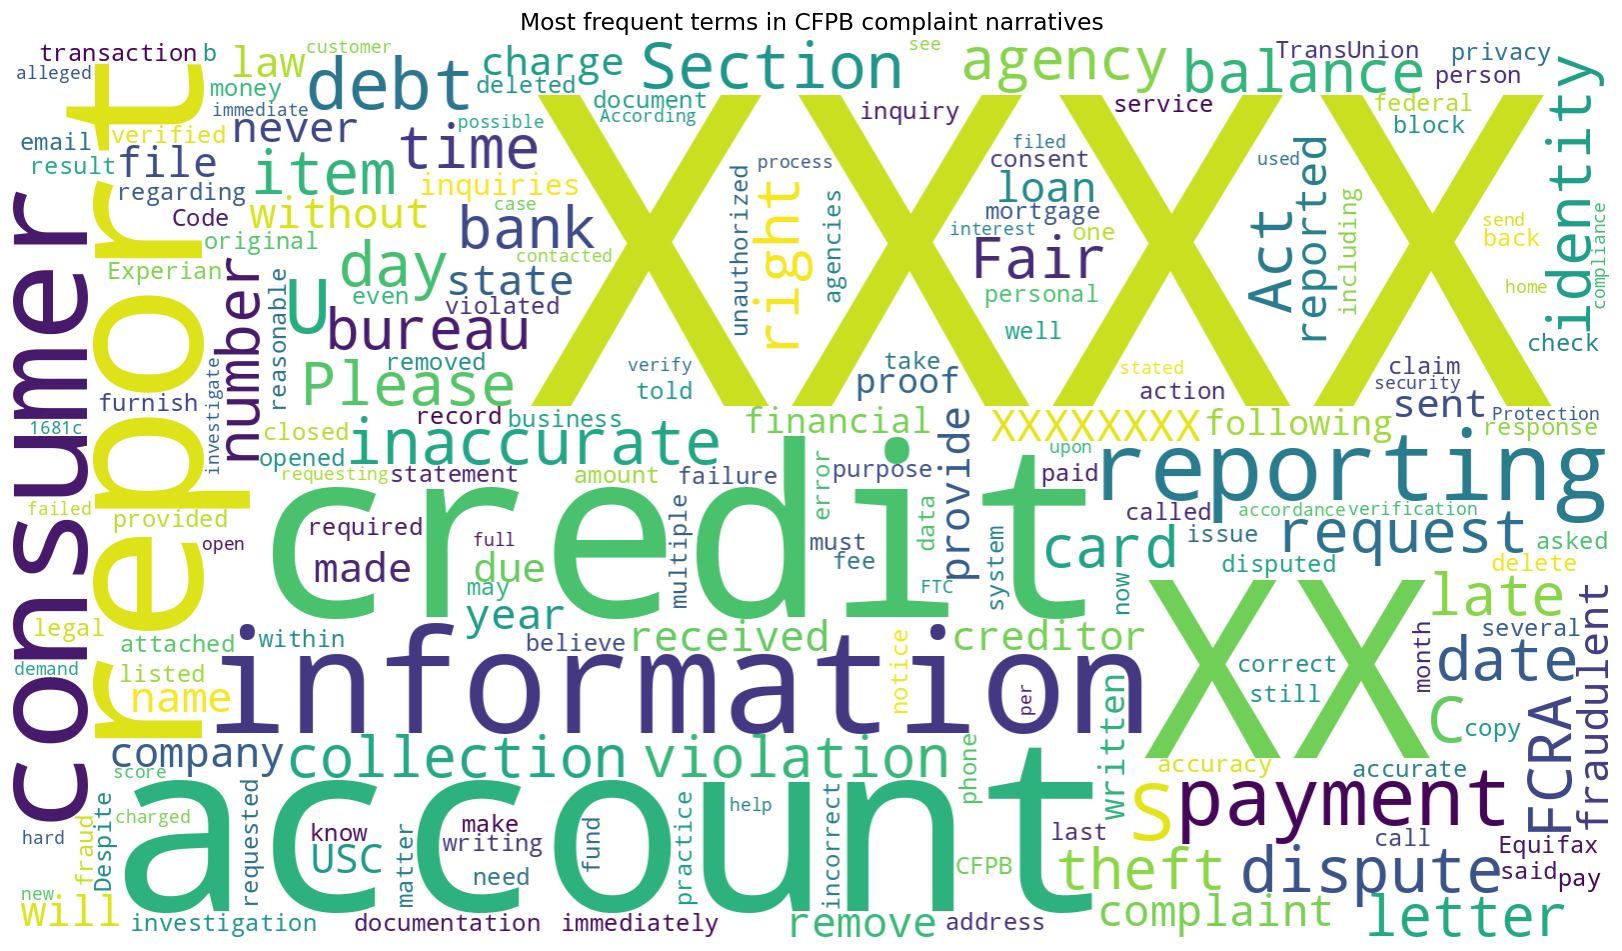

In [60]:
# Figure B5 — Word cloud
if clean_sample_path.exists():
    from wordcloud import WordCloud

    combined_text = " ".join(
        df_cfpb_fig["clean_text"]
        .dropna()
        .astype(str)
        .tolist()
    )

    wordcloud = WordCloud(
        width=1600,
        height=900,
        background_color="white",
        max_words=200,
        collocations=False,
    ).generate(combined_text)

    fig, ax = plt.subplots(figsize=(14, 8))
    ax.imshow(wordcloud, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("Most frequent terms in CFPB complaint narratives")

    save_figure("B5_cfpb_wordcloud.png")
    plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/B6_top_tfidf_terms.png


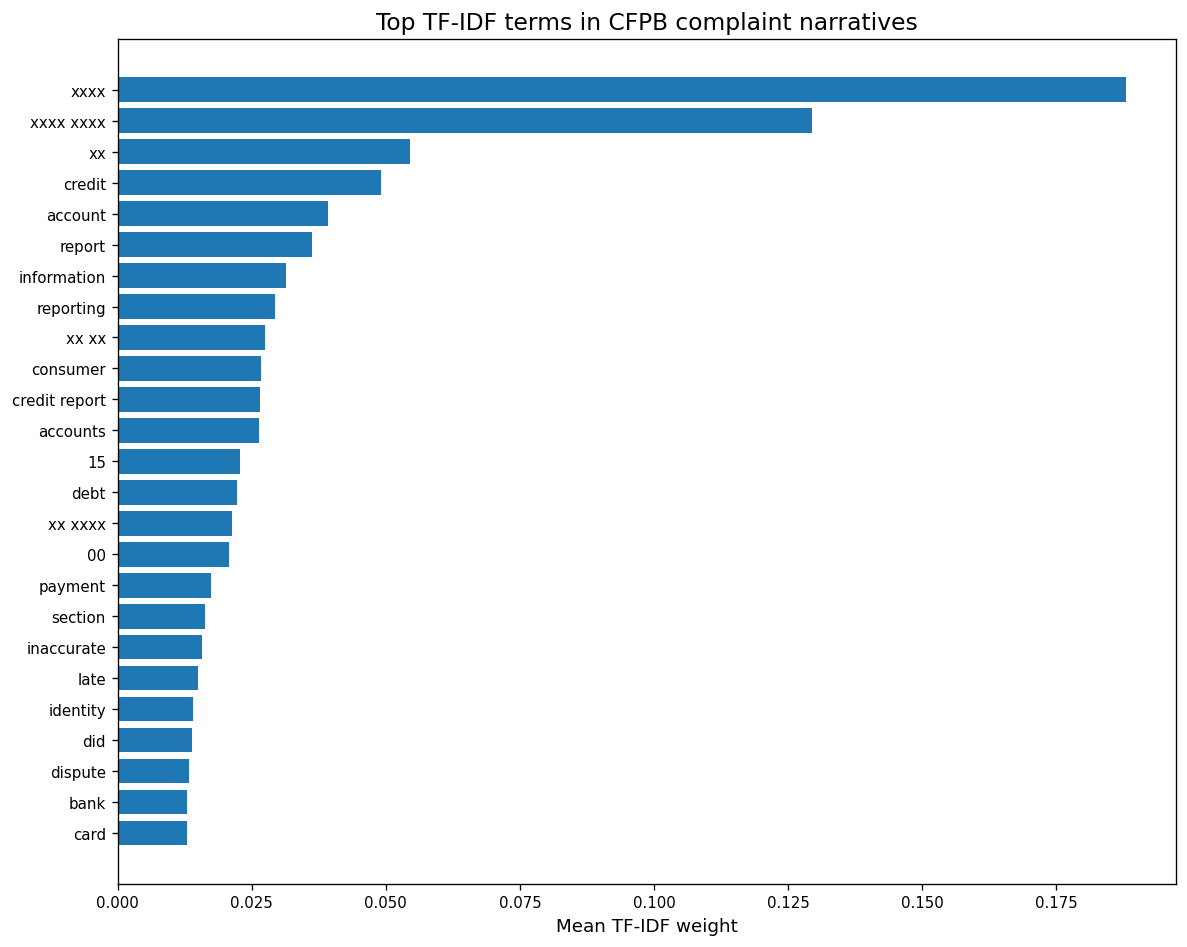

In [61]:
# Figure B6 — Top TF-IDF terms
if clean_sample_path.exists():
    tfidf_preview = TfidfVectorizer(
        max_features=5000,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=5,
    )

    matrix = tfidf_preview.fit_transform(
        df_cfpb_fig["clean_text"]
    )

    mean_tfidf = np.asarray(
        matrix.mean(axis=0)
    ).ravel()

    terms = np.array(
        tfidf_preview.get_feature_names_out()
    )

    top_indices = np.argsort(
        mean_tfidf
    )[-25:]

    top_terms = pd.Series(
        mean_tfidf[top_indices],
        index=terms[top_indices],
    ).sort_values()

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(
        top_terms.index,
        top_terms.values,
    )
    ax.set_title("Top TF-IDF terms in CFPB complaint narratives")
    ax.set_xlabel("Mean TF-IDF weight")

    save_figure("B6_top_tfidf_terms.png")
    plt.show()

## C. PSO and selected-feature figures

Saved: /content/drive/MyDrive/Thesis/figures/C1_pso_convergence.png


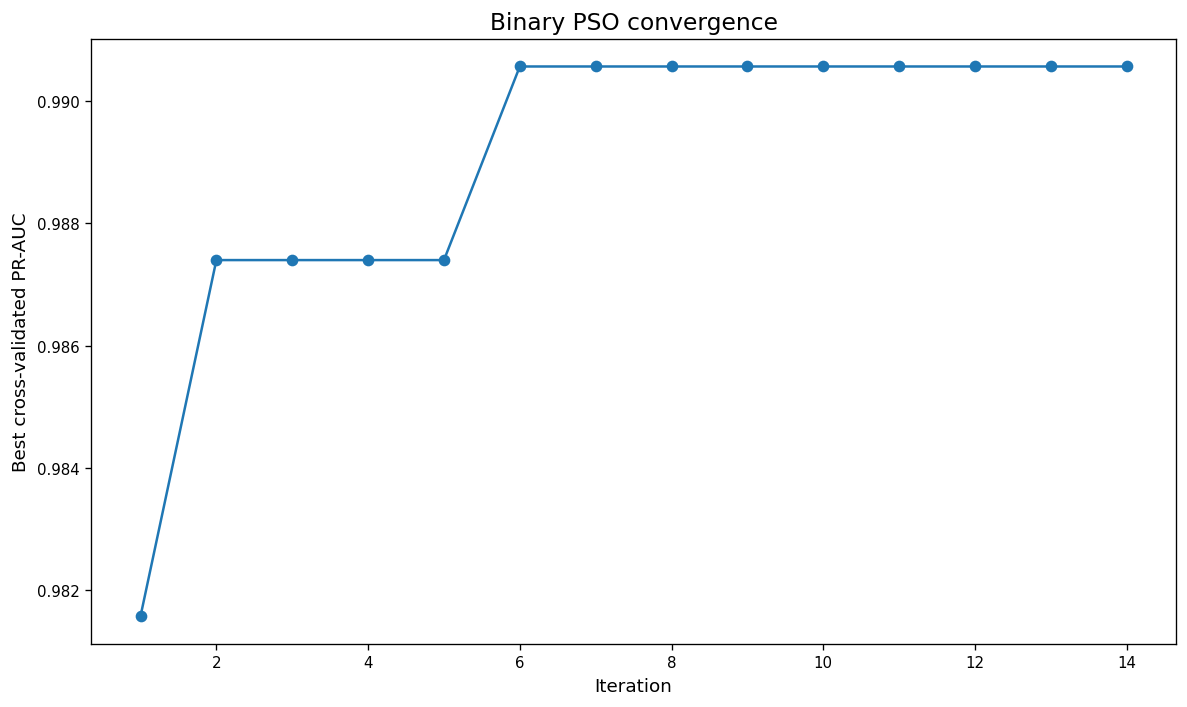

In [62]:
# Figure C1 — PSO convergence
pso_history_path = PROCESSED_DIR / "pso_history.csv"

if pso_history_path.exists():
    pso_history_fig = pd.read_csv(pso_history_path)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(
        pso_history_fig["iteration"],
        pso_history_fig["cv_pr_auc"],
        marker="o",
    )
    ax.set_title("Binary PSO convergence")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Best cross-validated PR-AUC")

    save_figure("C1_pso_convergence.png")
    plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/C2_pso_fitness.png


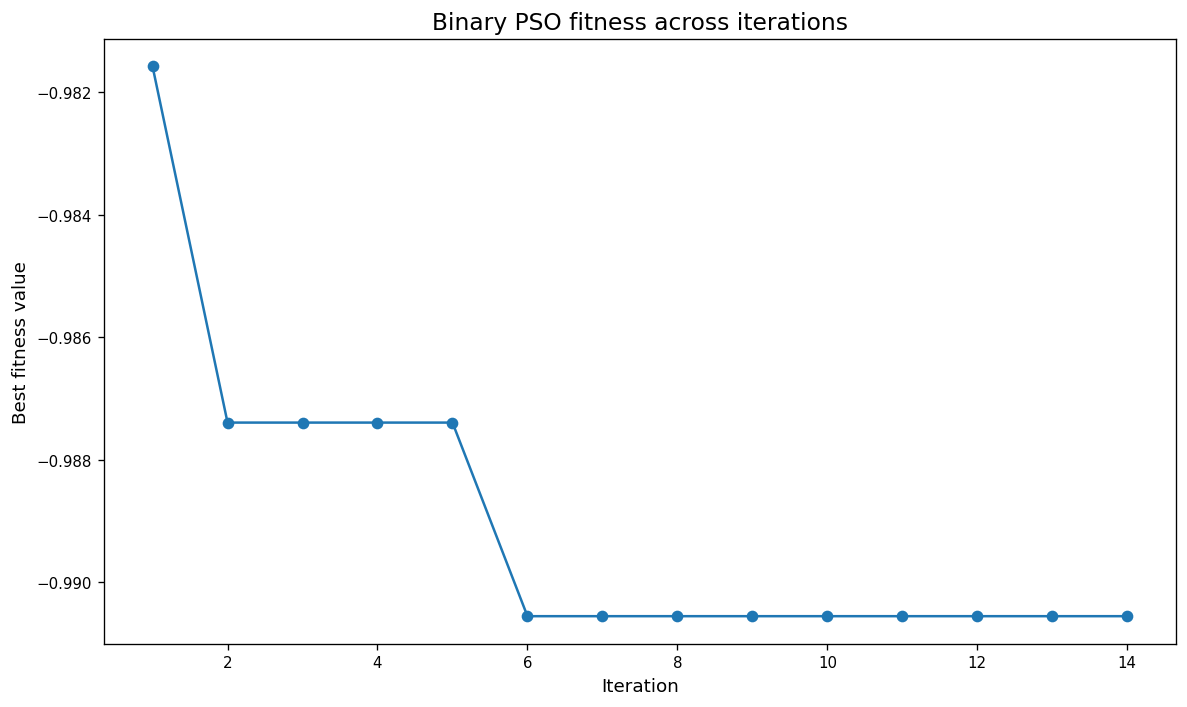

In [63]:
# Figure C2 — PSO fitness
if pso_history_path.exists():
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(
        pso_history_fig["iteration"],
        pso_history_fig["fitness"],
        marker="o",
    )
    ax.set_title("Binary PSO fitness across iterations")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Best fitness value")

    save_figure("C2_pso_fitness.png")
    plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/C3_selected_20_feature_correlation_heatmap.png


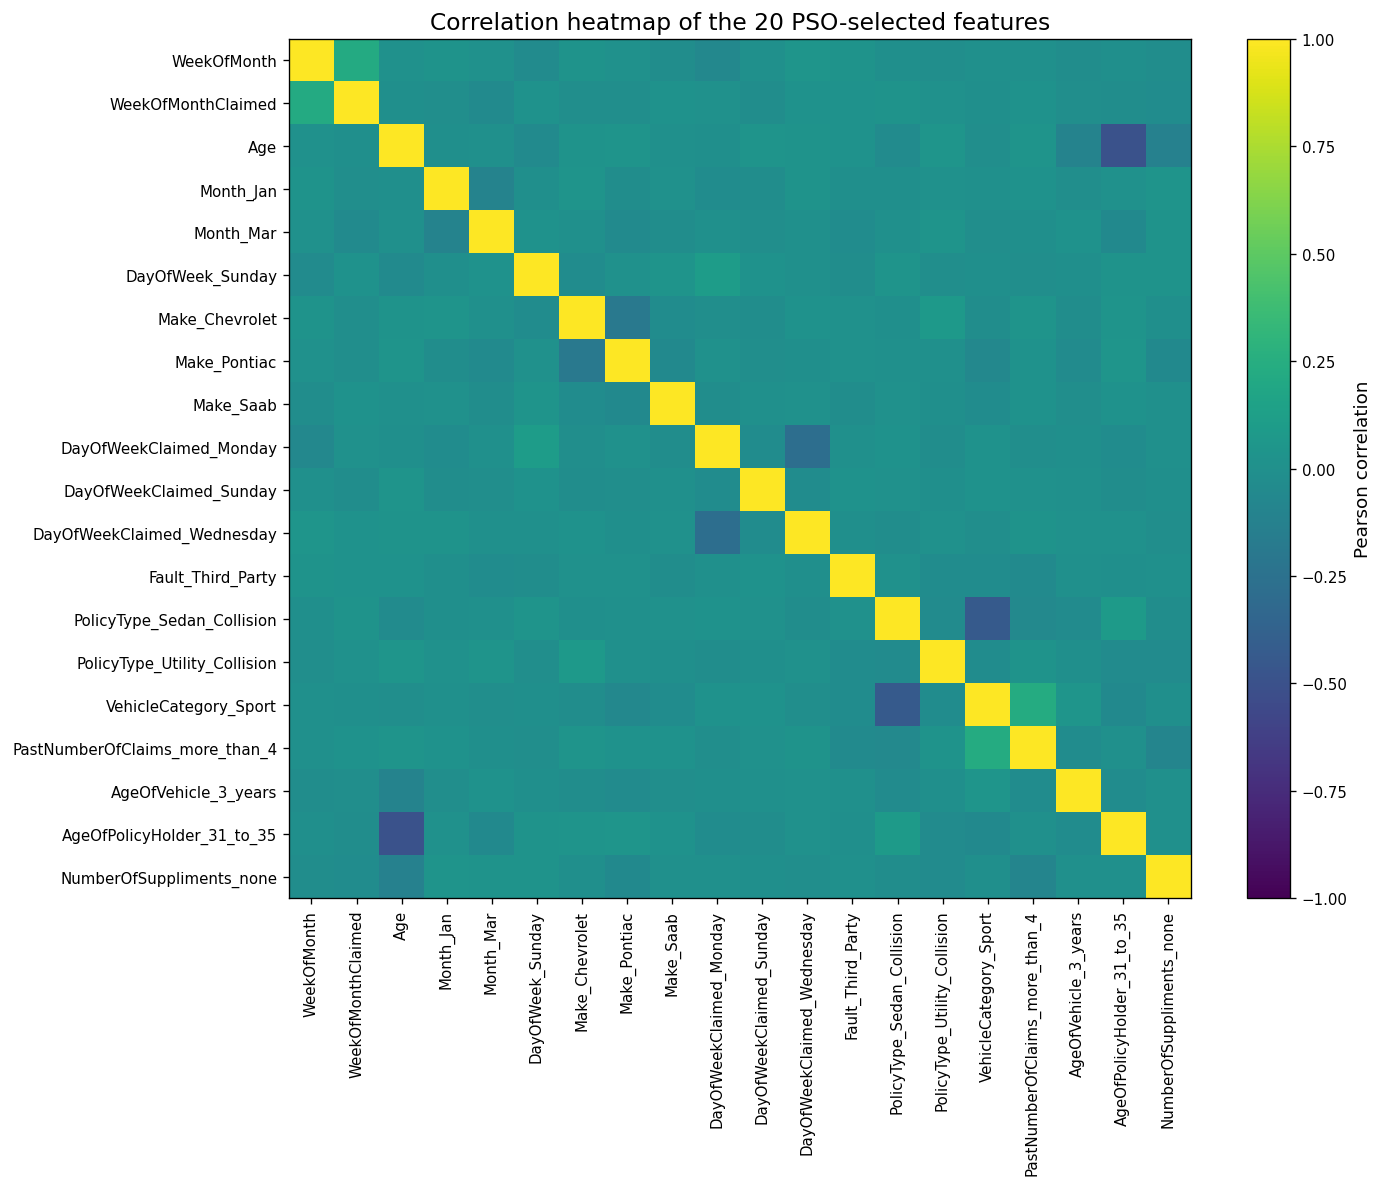

In [64]:
# Figure C3 — Selected-feature correlation heatmap
selected_corr = X_train_20.corr()

fig, ax = plt.subplots(figsize=(12, 10))
image = ax.imshow(
    selected_corr.values,
    aspect="auto",
    vmin=-1,
    vmax=1,
)
ax.set_xticks(range(len(selected_corr.columns)))
ax.set_xticklabels(
    selected_corr.columns,
    rotation=90,
)
ax.set_yticks(range(len(selected_corr.columns)))
ax.set_yticklabels(selected_corr.columns)
ax.set_title("Correlation heatmap of the 20 PSO-selected features")
fig.colorbar(image, ax=ax, label="Pearson correlation")

save_figure("C3_selected_20_feature_correlation_heatmap.png")
plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/C4_selected_20_features.png


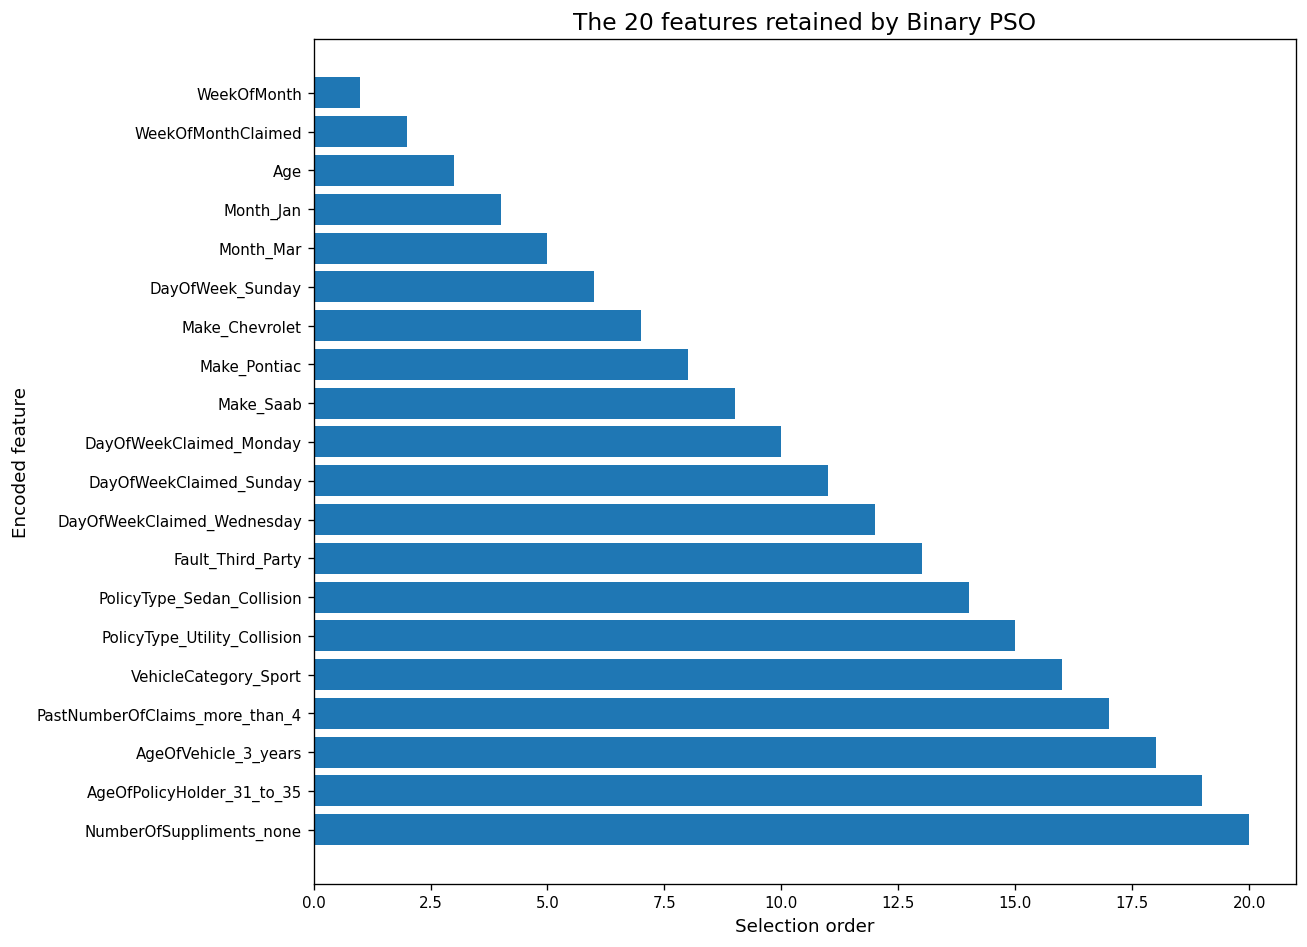

In [65]:
# Figure C4 — Selected features as a ranked list
selected_feature_table = pd.DataFrame({
    "Feature": SELECTED_FEATURES,
    "Rank": np.arange(1, len(SELECTED_FEATURES) + 1),
})

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(
    selected_feature_table["Feature"][::-1],
    selected_feature_table["Rank"][::-1],
)
ax.set_title("The 20 features retained by Binary PSO")
ax.set_xlabel("Selection order")
ax.set_ylabel("Encoded feature")

save_figure("C4_selected_20_features.png")
plt.show()

## D. Eleven-classifier comparison figures

In [68]:
# Utility for sorted model-comparison bars
def plot_model_metric(
    results,
    metric,
    title,
    filename,
):
    plot_data = (
        results[["Model", metric]]
        .sort_values(metric)
    )

    fig, ax = plt.subplots(figsize=(11, 7))
    bars = ax.barh(
        plot_data["Model"],
        plot_data[metric],
    )
    ax.set_title(title)
    ax.set_xlabel(metric)

    for bar, value in zip(bars, plot_data[metric]):
        ax.text(
            value,
            bar.get_y() + bar.get_height() / 2,
            f" {value:.3f}",
            va="center",
        )

    save_figure(filename)
    plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/D1_test_pr_auc_11_classifiers.png


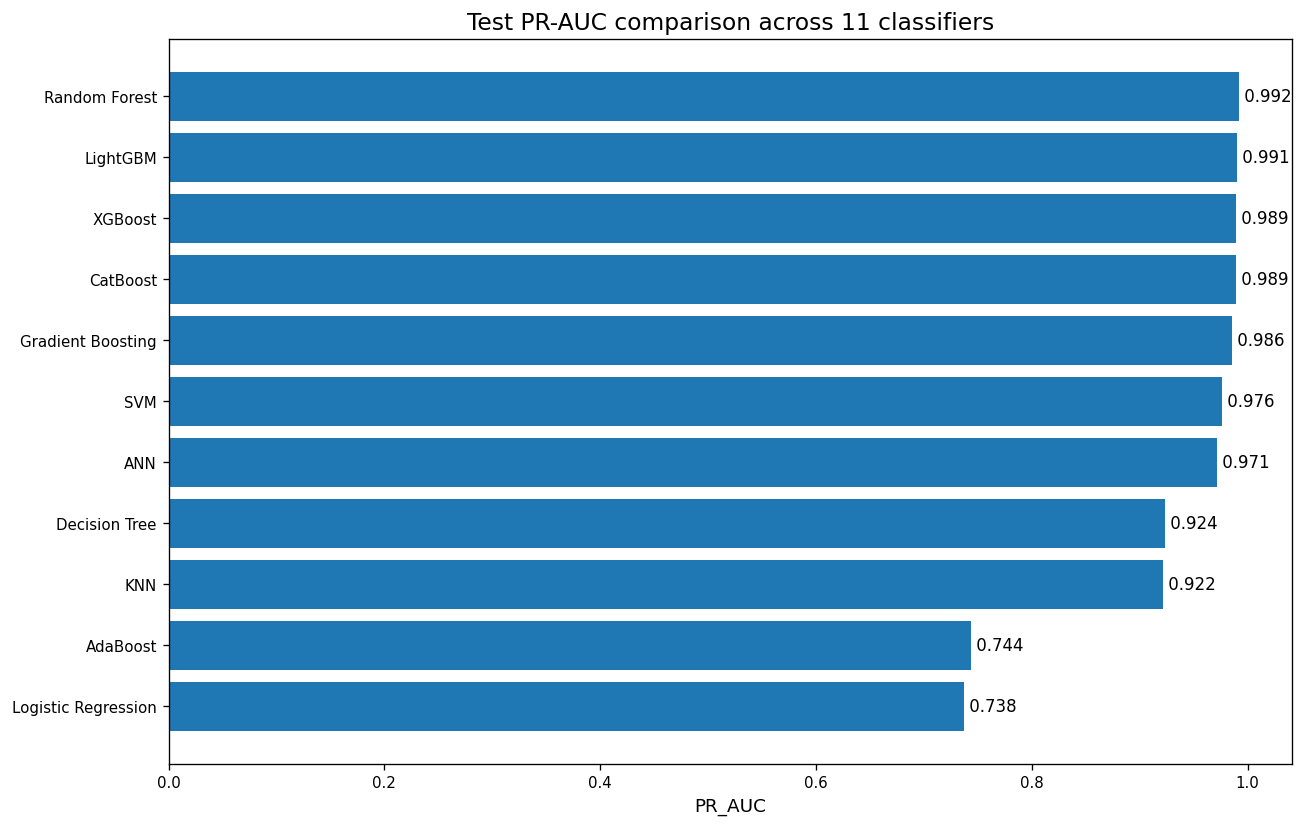

In [69]:
# Figure D1 — PR-AUC comparison
plot_model_metric(
    test_results,
    "PR_AUC",
    "Test PR-AUC comparison across 11 classifiers",
    "D1_test_pr_auc_11_classifiers.png",
)

Saved: /content/drive/MyDrive/Thesis/figures/D2_test_roc_auc_11_classifiers.png


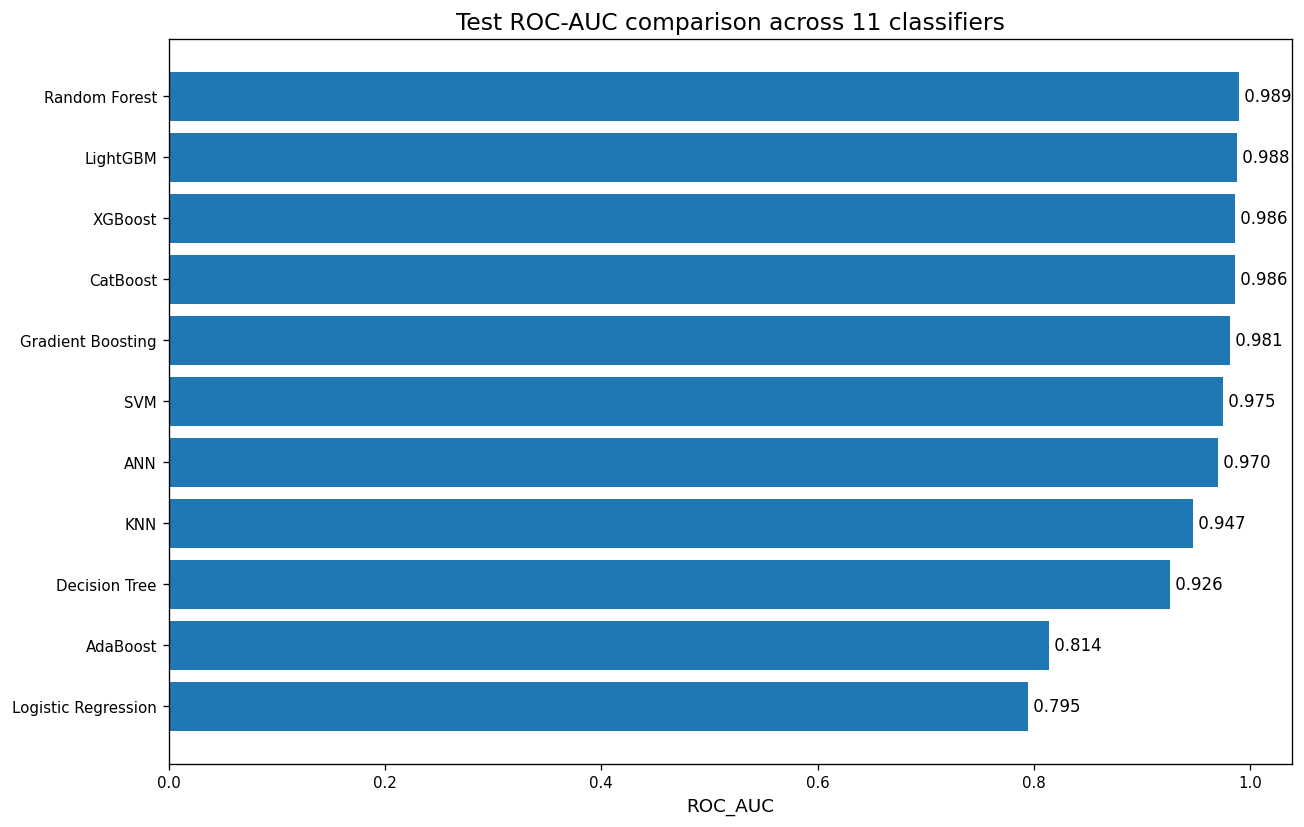

In [70]:
# Figure D2 — ROC-AUC comparison
plot_model_metric(
    test_results,
    "ROC_AUC",
    "Test ROC-AUC comparison across 11 classifiers",
    "D2_test_roc_auc_11_classifiers.png",
)

Saved: /content/drive/MyDrive/Thesis/figures/D3_test_recall_11_classifiers.png


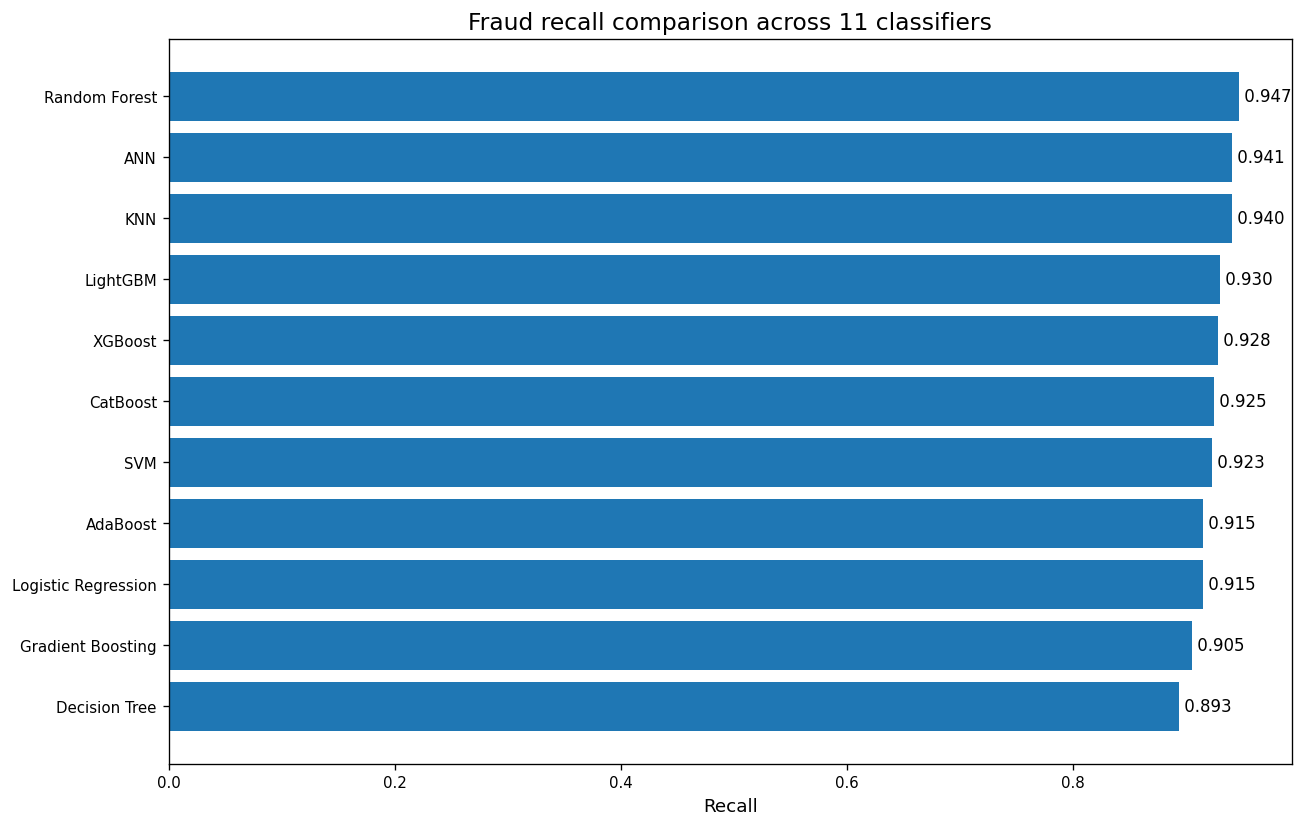

In [71]:
# Figure D3 — Recall comparison
plot_model_metric(
    test_results,
    "Recall",
    "Fraud recall comparison across 11 classifiers",
    "D3_test_recall_11_classifiers.png",
)

Saved: /content/drive/MyDrive/Thesis/figures/D4_test_precision_11_classifiers.png


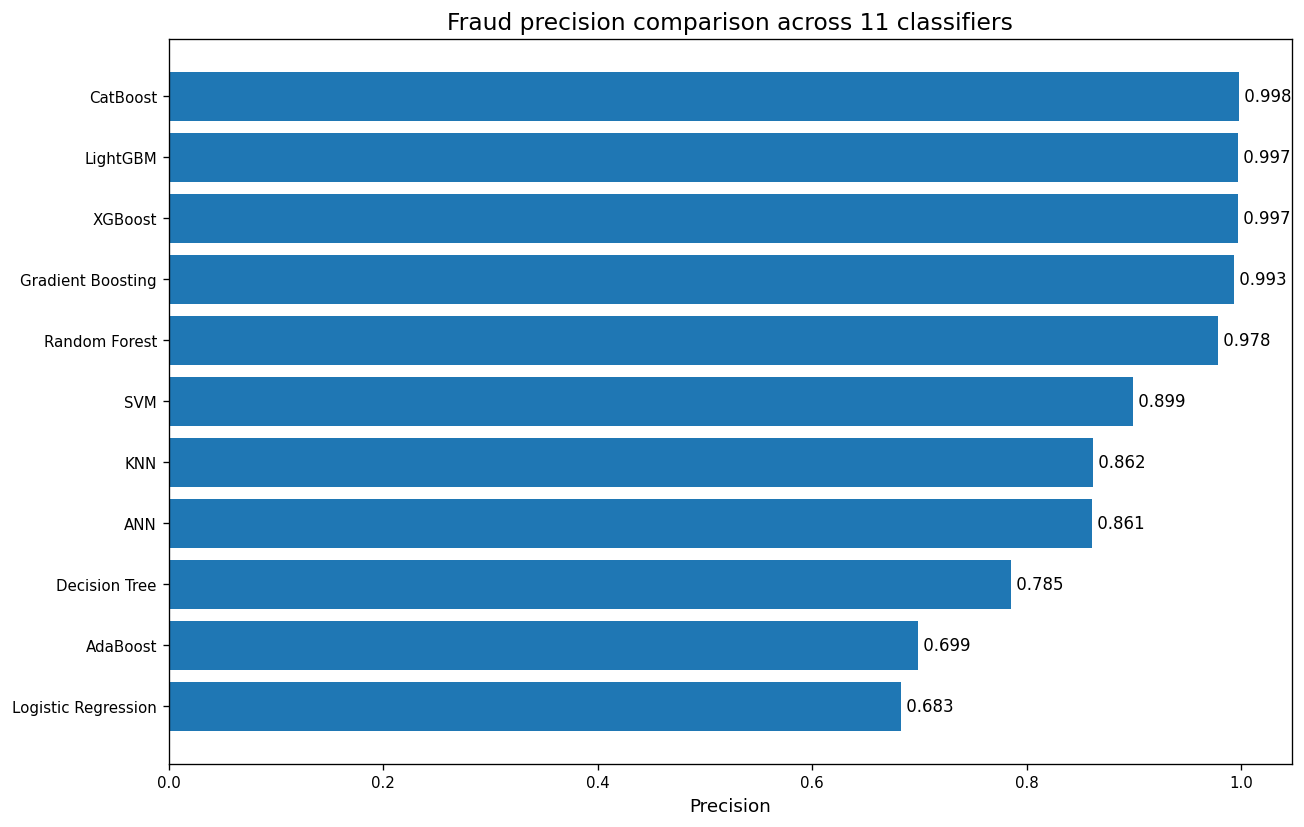

In [72]:
# Figure D4 — Precision comparison
plot_model_metric(
    test_results,
    "Precision",
    "Fraud precision comparison across 11 classifiers",
    "D4_test_precision_11_classifiers.png",
)

Saved: /content/drive/MyDrive/Thesis/figures/D5_test_f1_11_classifiers.png


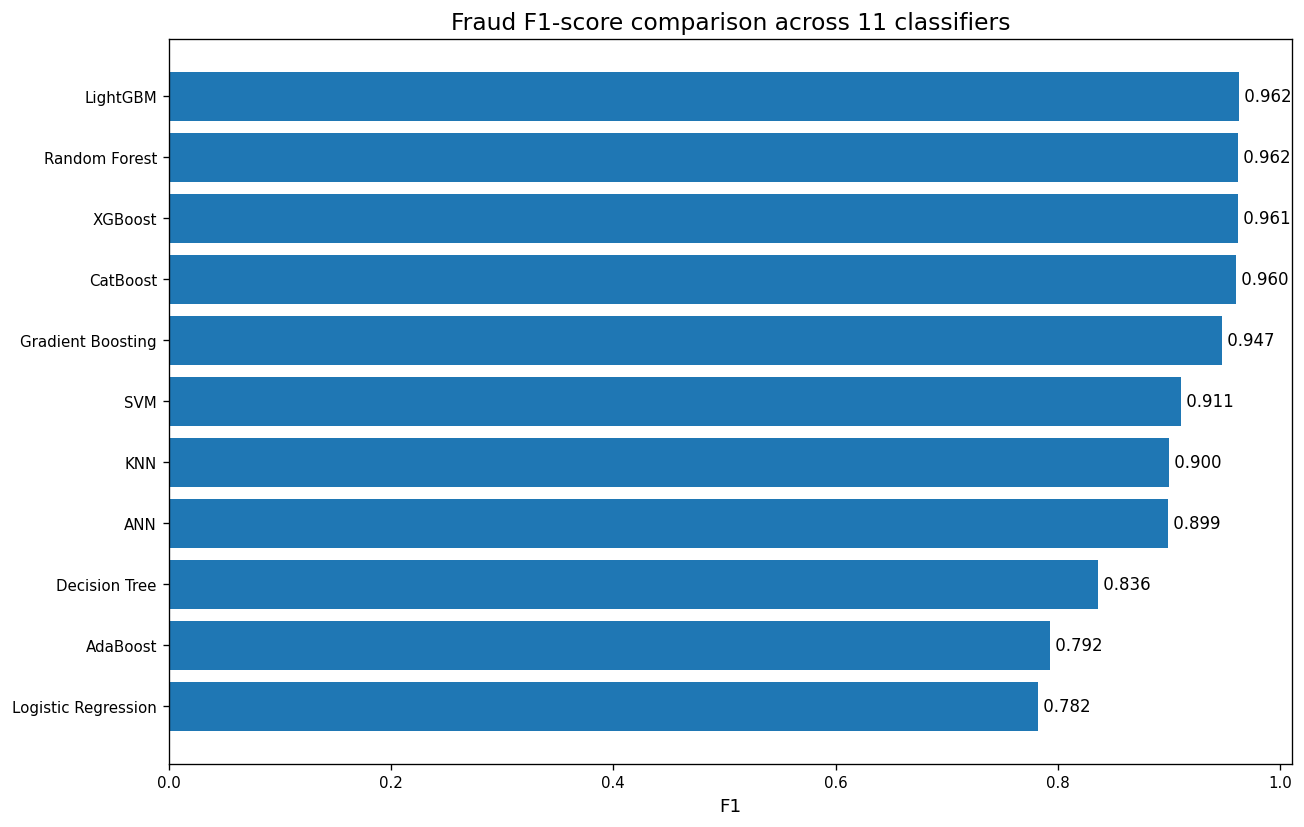

In [73]:
# Figure D5 — F1 comparison
plot_model_metric(
    test_results,
    "F1",
    "Fraud F1-score comparison across 11 classifiers",
    "D5_test_f1_11_classifiers.png",
)

Saved: /content/drive/MyDrive/Thesis/figures/D6_test_mcc_11_classifiers.png


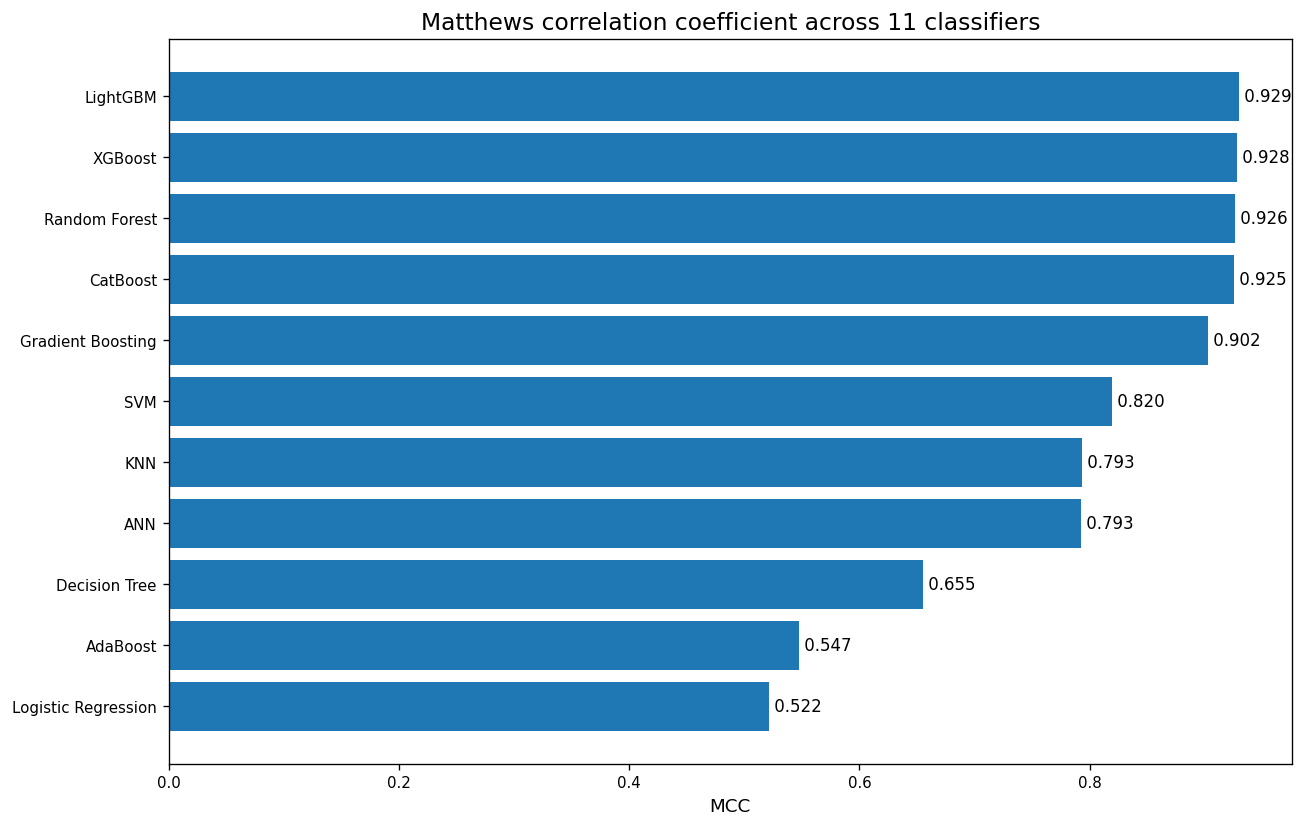

In [74]:
# Figure D6 — MCC comparison
plot_model_metric(
    test_results,
    "MCC",
    "Matthews correlation coefficient across 11 classifiers",
    "D6_test_mcc_11_classifiers.png",
)

Saved: /content/drive/MyDrive/Thesis/figures/D7_test_accuracy_11_classifiers.png


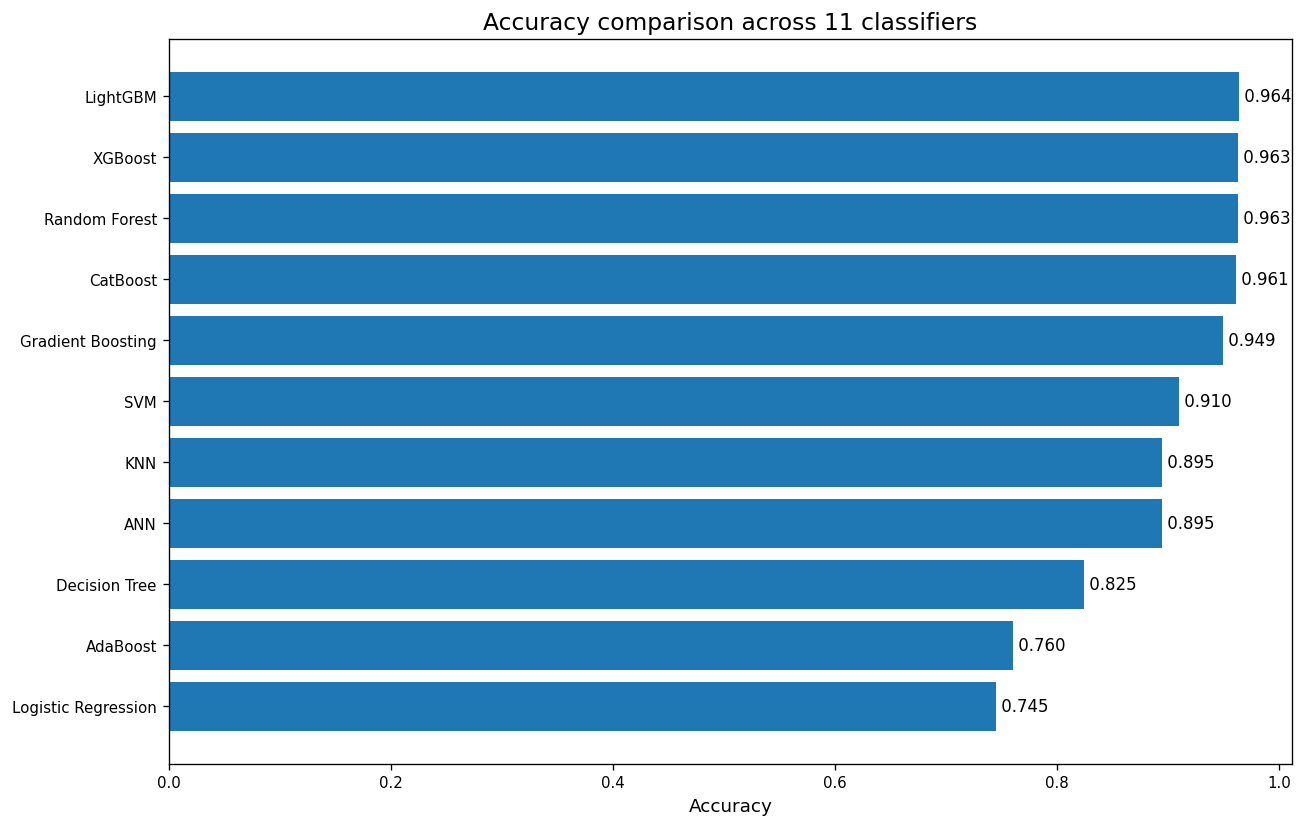

In [75]:
# Figure D7 — Accuracy comparison
plot_model_metric(
    test_results,
    "Accuracy",
    "Accuracy comparison across 11 classifiers",
    "D7_test_accuracy_11_classifiers.png",
)

Saved: /content/drive/MyDrive/Thesis/figures/D8_selected_thresholds_11_classifiers.png


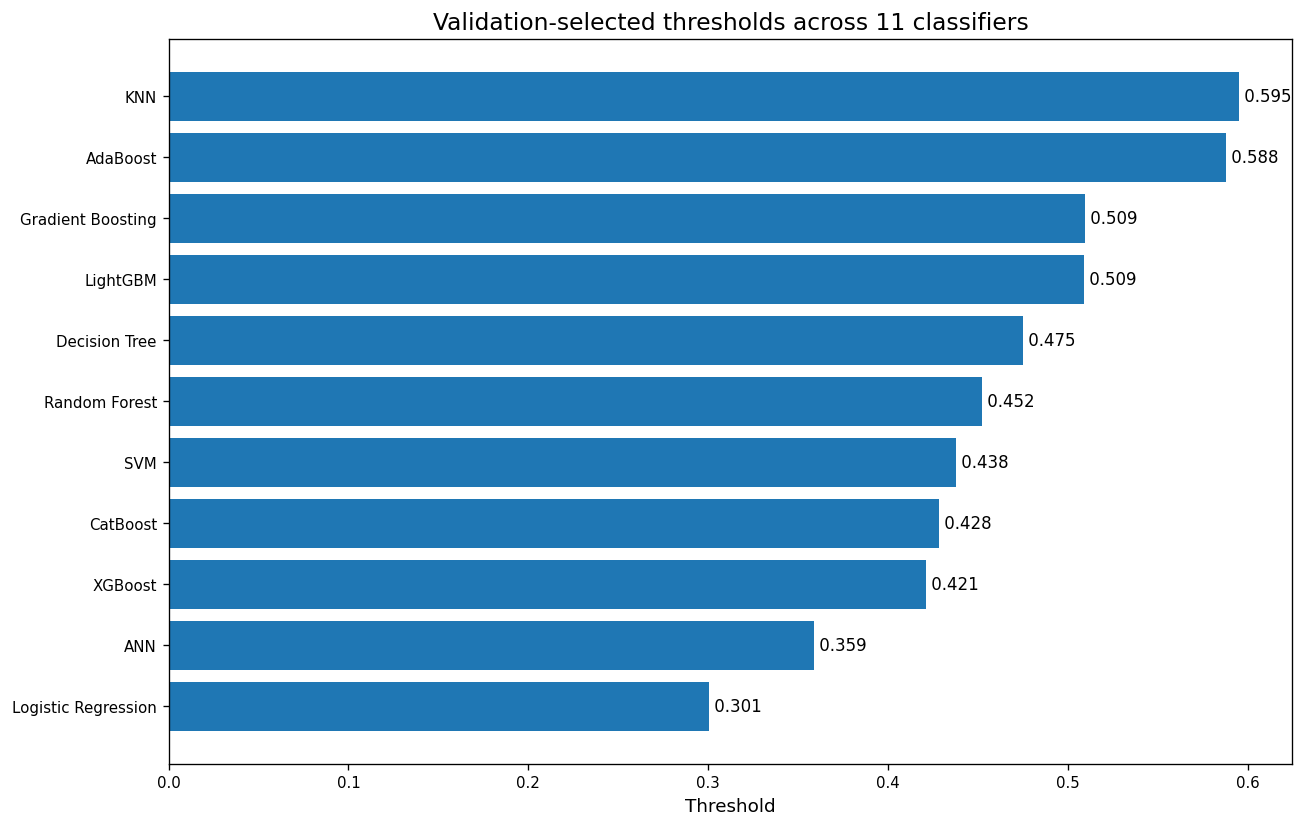

In [76]:
# Figure D8 — Threshold comparison
plot_model_metric(
    test_results,
    "Threshold",
    "Validation-selected thresholds across 11 classifiers",
    "D8_selected_thresholds_11_classifiers.png",
)

Saved: /content/drive/MyDrive/Thesis/figures/D9_multi_metric_classifier_comparison.png


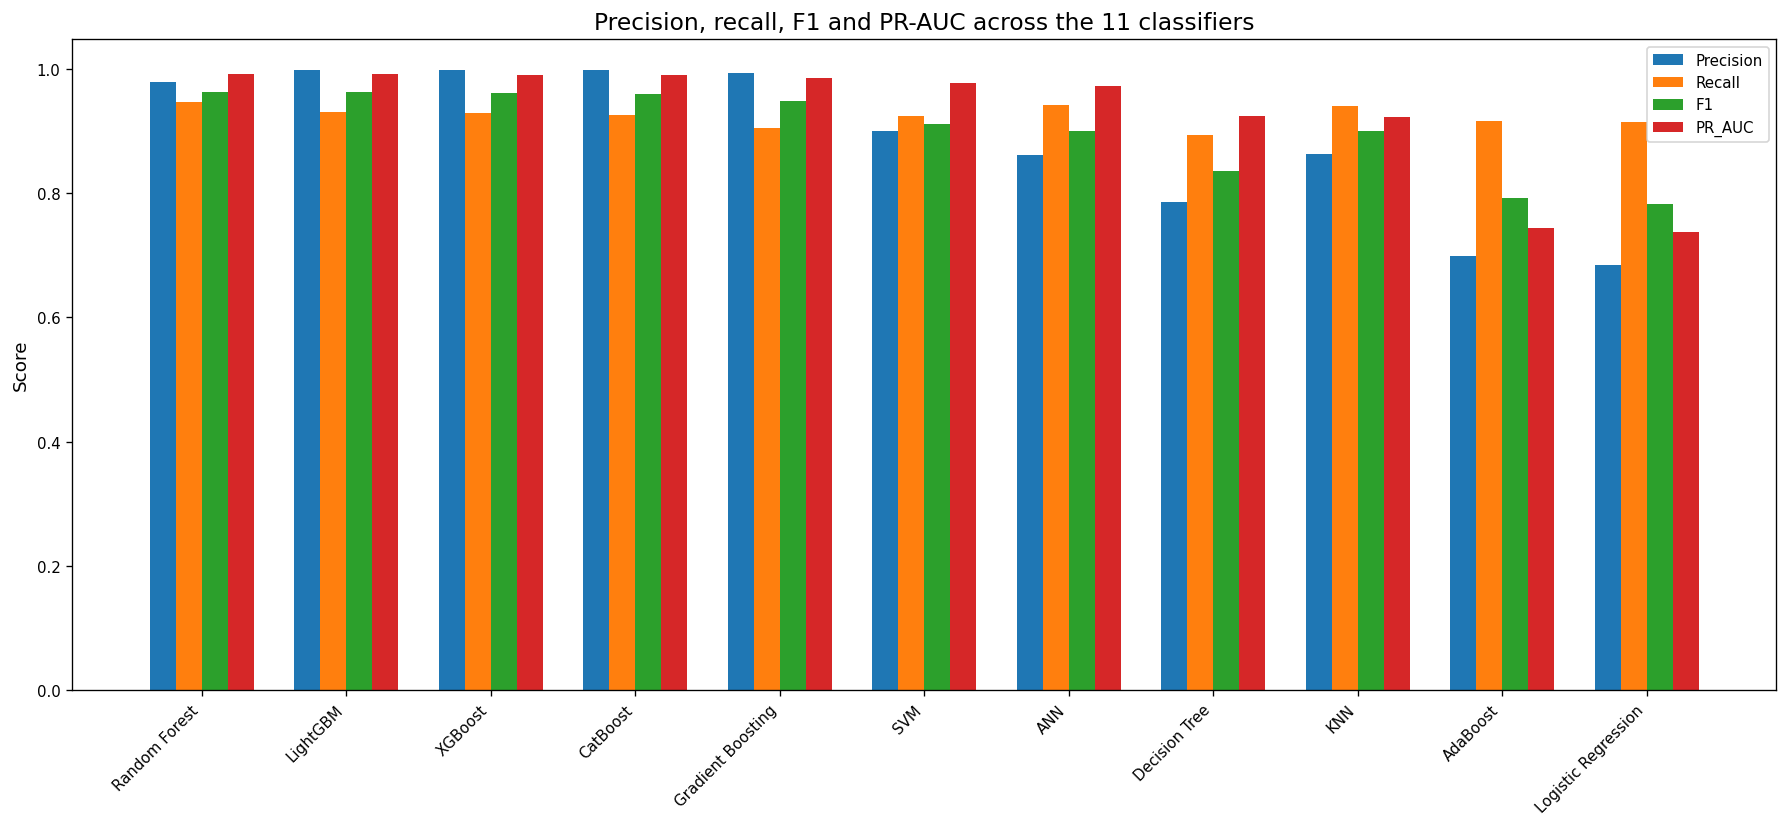

In [77]:
# Figure D9 — Multi-metric grouped comparison
metrics_to_compare = [
    "Precision",
    "Recall",
    "F1",
    "PR_AUC",
]

plot_df = (
    test_results
    .set_index("Model")[metrics_to_compare]
)

x = np.arange(len(plot_df))
width = 0.18

fig, ax = plt.subplots(figsize=(15, 7))

for index, metric in enumerate(metrics_to_compare):
    ax.bar(
        x + (index - 1.5) * width,
        plot_df[metric].values,
        width,
        label=metric,
    )

ax.set_xticks(x)
ax.set_xticklabels(
    plot_df.index,
    rotation=45,
    ha="right",
)
ax.set_ylabel("Score")
ax.set_title(
    "Precision, recall, F1 and PR-AUC across the 11 classifiers"
)
ax.legend()

save_figure("D9_multi_metric_classifier_comparison.png")
plt.show()

## E. Diagnostic curves and confusion matrices

Saved: /content/drive/MyDrive/Thesis/figures/E1_roc_curves_all_11_classifiers.png


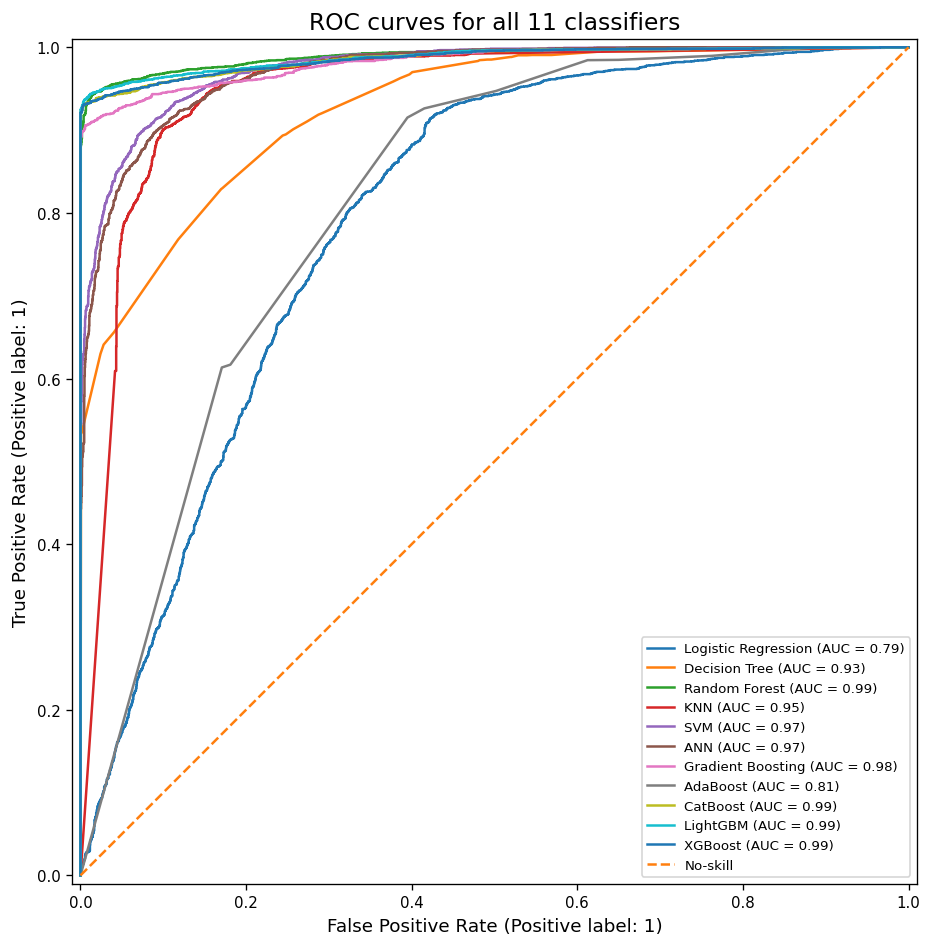

In [78]:
# Figure E1 — ROC curves for all 11 classifiers
fig, ax = plt.subplots(figsize=(10, 8))

for model_name, outputs in test_outputs.items():
    RocCurveDisplay.from_predictions(
        y_test,
        outputs["probability"],
        name=model_name,
        ax=ax,
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="No-skill",
)
ax.set_title("ROC curves for all 11 classifiers")
ax.legend(loc="lower right", fontsize=8)

save_figure("E1_roc_curves_all_11_classifiers.png")
plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/E2_precision_recall_curves_all_11_classifiers.png


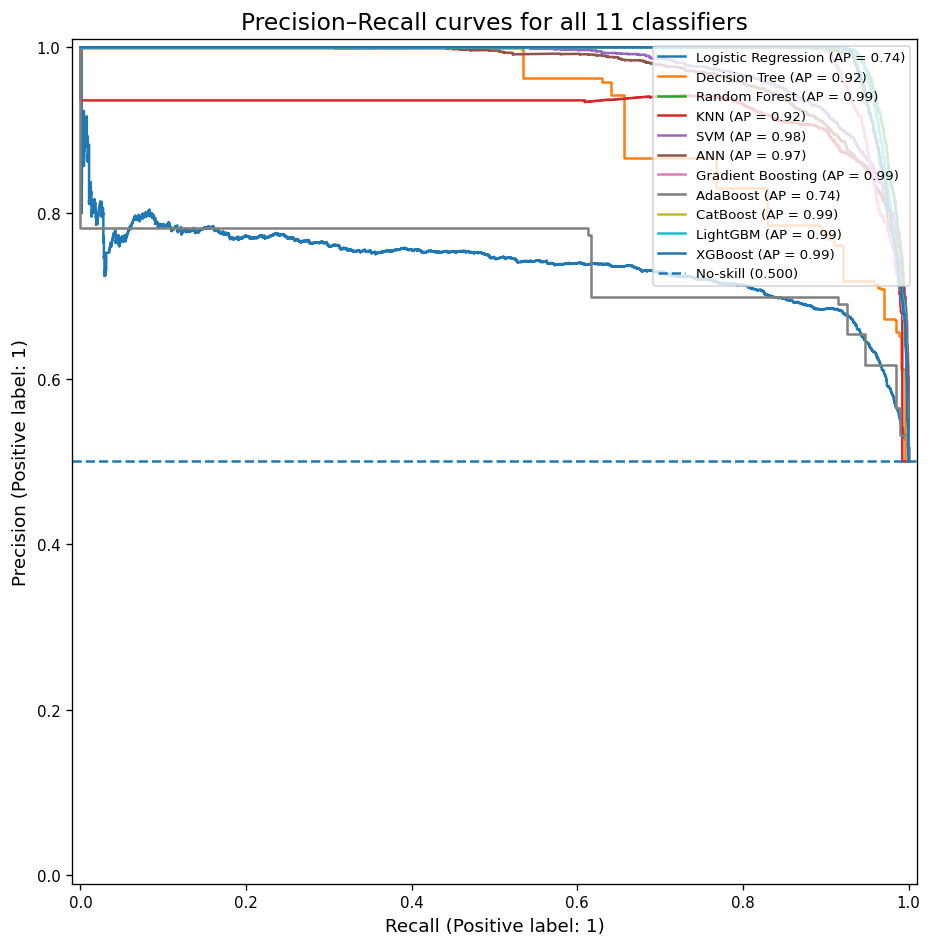

In [79]:
# Figure E2 — Precision–Recall curves for all 11 classifiers
fig, ax = plt.subplots(figsize=(10, 8))

for model_name, outputs in test_outputs.items():
    PrecisionRecallDisplay.from_predictions(
        y_test,
        outputs["probability"],
        name=model_name,
        ax=ax,
    )

ax.axhline(
    y_test.mean(),
    linestyle="--",
    label=f"No-skill ({y_test.mean():.3f})",
)
ax.set_title("Precision–Recall curves for all 11 classifiers")
ax.legend(loc="upper right", fontsize=8)

save_figure("E2_precision_recall_curves_all_11_classifiers.png")
plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/E_confusion_matrix_logistic_regression.png


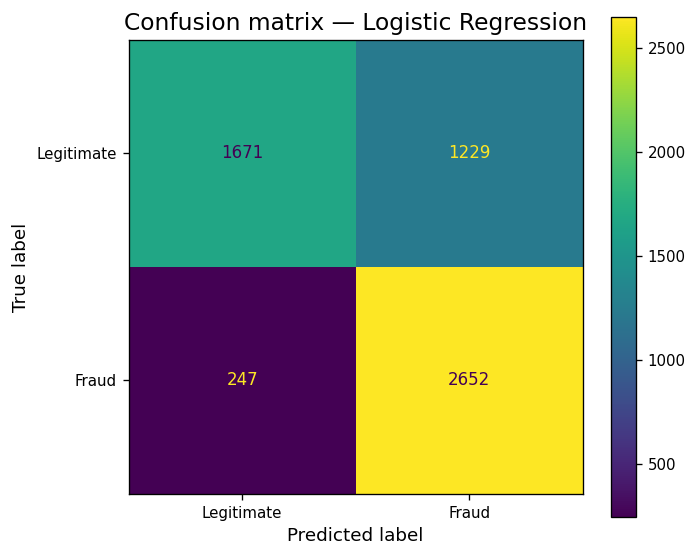

Saved: /content/drive/MyDrive/Thesis/figures/E_confusion_matrix_decision_tree.png


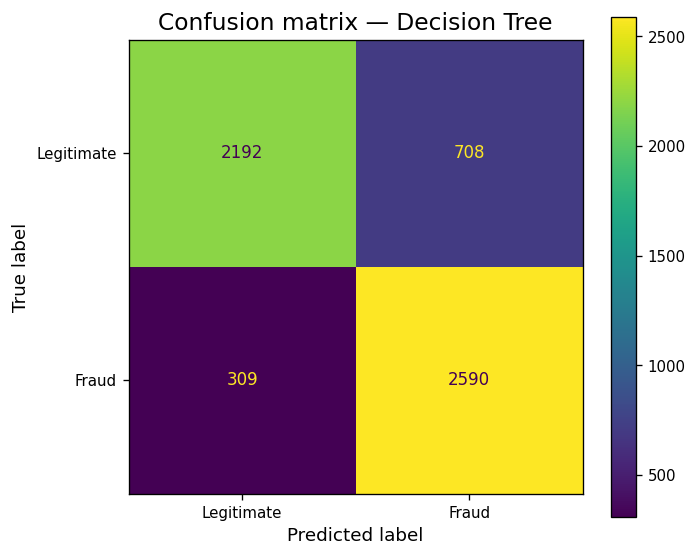

Saved: /content/drive/MyDrive/Thesis/figures/E_confusion_matrix_random_forest.png


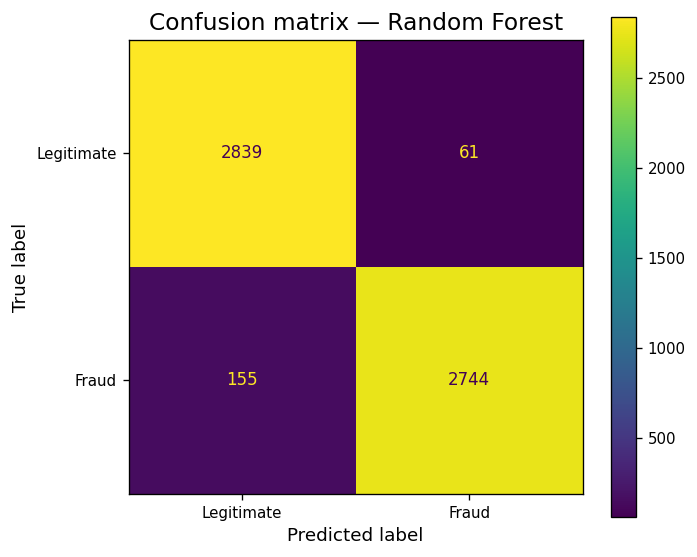

Saved: /content/drive/MyDrive/Thesis/figures/E_confusion_matrix_knn.png


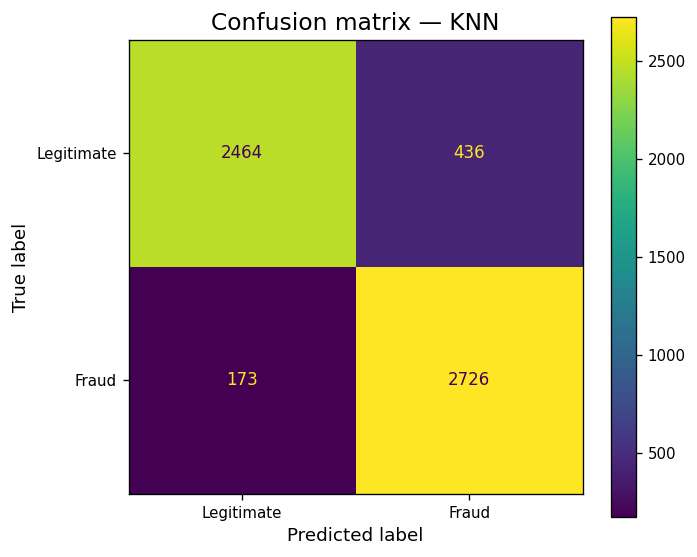

Saved: /content/drive/MyDrive/Thesis/figures/E_confusion_matrix_svm.png


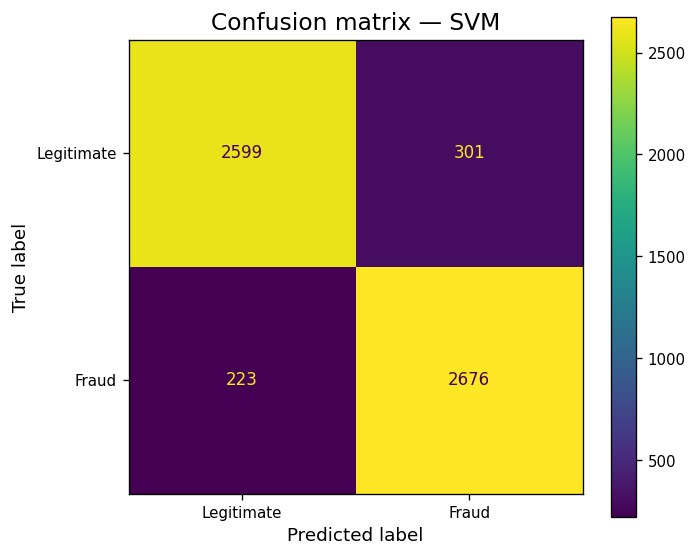

Saved: /content/drive/MyDrive/Thesis/figures/E_confusion_matrix_ann.png


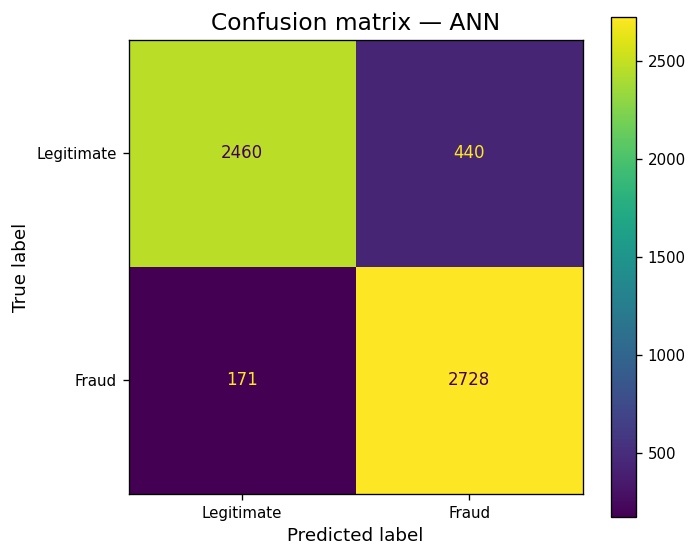

Saved: /content/drive/MyDrive/Thesis/figures/E_confusion_matrix_gradient_boosting.png


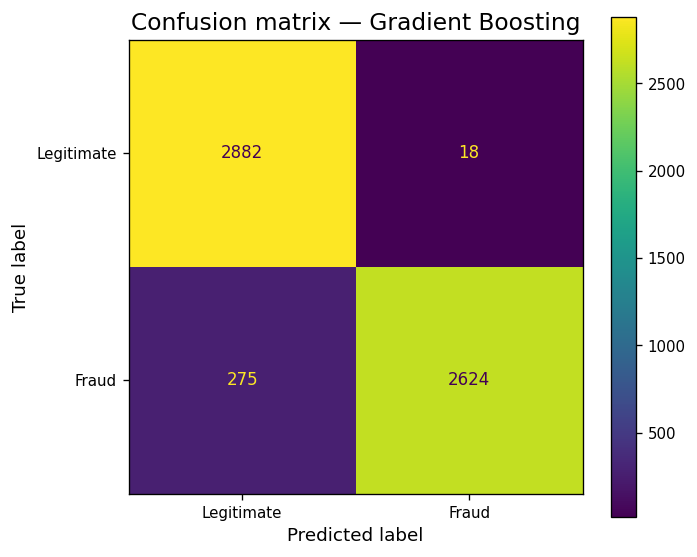

Saved: /content/drive/MyDrive/Thesis/figures/E_confusion_matrix_adaboost.png


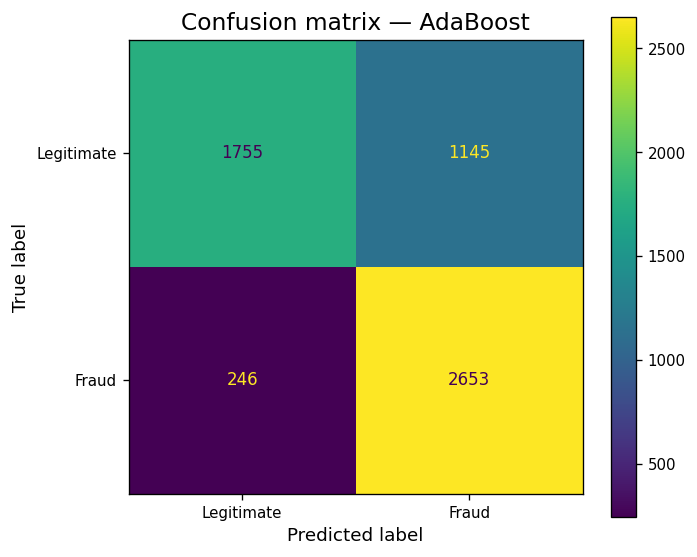

Saved: /content/drive/MyDrive/Thesis/figures/E_confusion_matrix_catboost.png


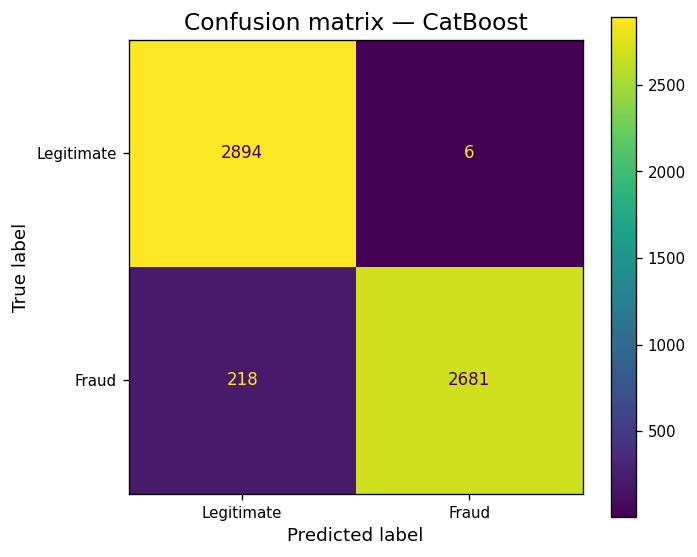

Saved: /content/drive/MyDrive/Thesis/figures/E_confusion_matrix_lightgbm.png


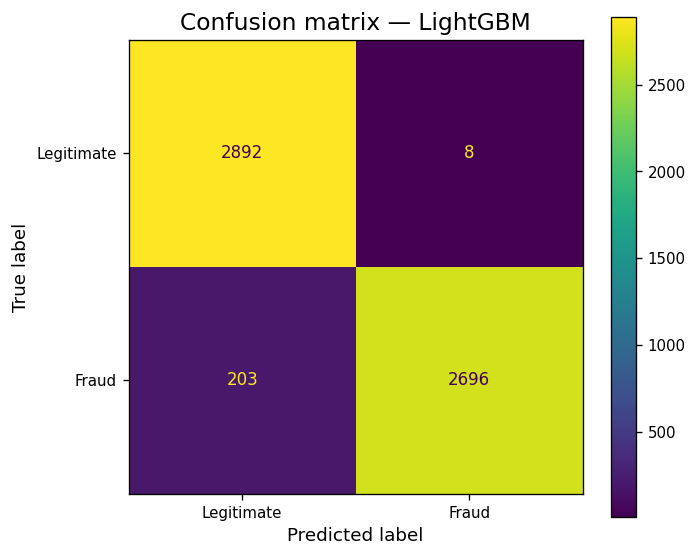

Saved: /content/drive/MyDrive/Thesis/figures/E_confusion_matrix_xgboost.png


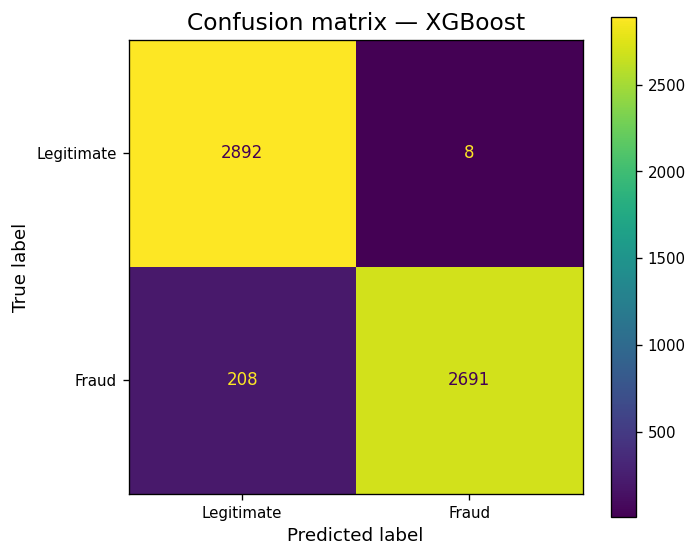

In [80]:
# Figures E3–E13 — Confusion matrix for each classifier
for model_name, outputs in test_outputs.items():
    fig, ax = plt.subplots(figsize=(6, 5))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        outputs["prediction"],
        display_labels=["Legitimate", "Fraud"],
        values_format="d",
        ax=ax,
    )

    ax.set_title(f"Confusion matrix — {model_name}")

    safe_name = re.sub(
        r"[^A-Za-z0-9]+",
        "_",
        model_name,
    ).strip("_").lower()

    save_figure(
        f"E_confusion_matrix_{safe_name}.png"
    )
    plt.show()

## F. SHAP explainability figures

Saved: /content/drive/MyDrive/Thesis/figures/F1_shap_global_bar_plot.png


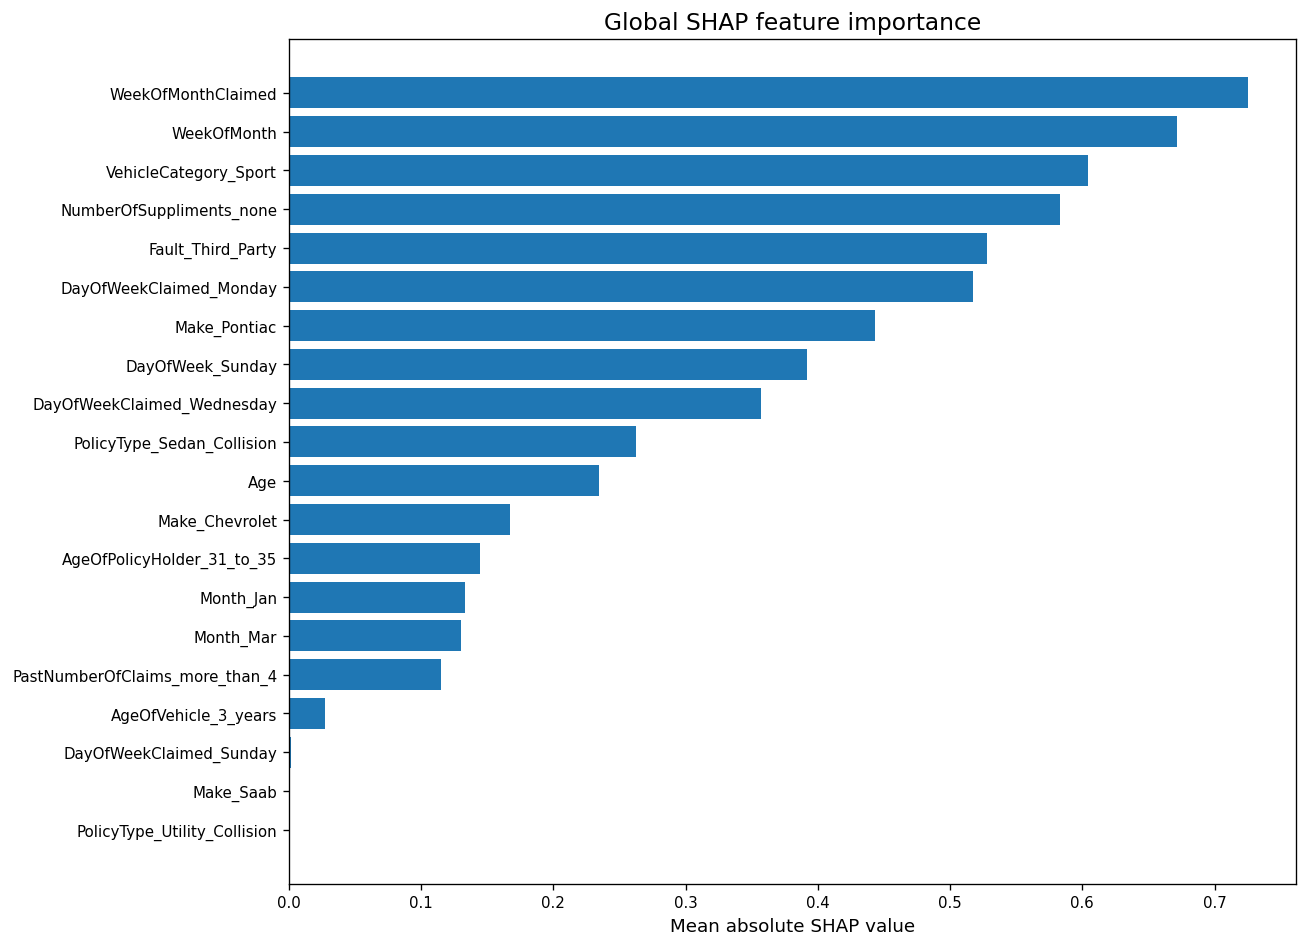

In [81]:
# Load the SHAP importance table created in Phase 5.
shap_path = DASHBOARD_DIR / "structured_shap_importance.csv"

if shap_path.exists():
    shap_importance_fig = pd.read_csv(shap_path)

    # Figure F1 — SHAP bar plot
    top_shap = (
        shap_importance_fig
        .head(20)
        .sort_values("MeanAbsoluteSHAP")
    )

    fig, ax = plt.subplots(figsize=(11, 8))
    ax.barh(
        top_shap["Feature"],
        top_shap["MeanAbsoluteSHAP"],
    )
    ax.set_title("Global SHAP feature importance")
    ax.set_xlabel("Mean absolute SHAP value")

    save_figure("F1_shap_global_bar_plot.png")
    plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/F2_shap_beeswarm.png


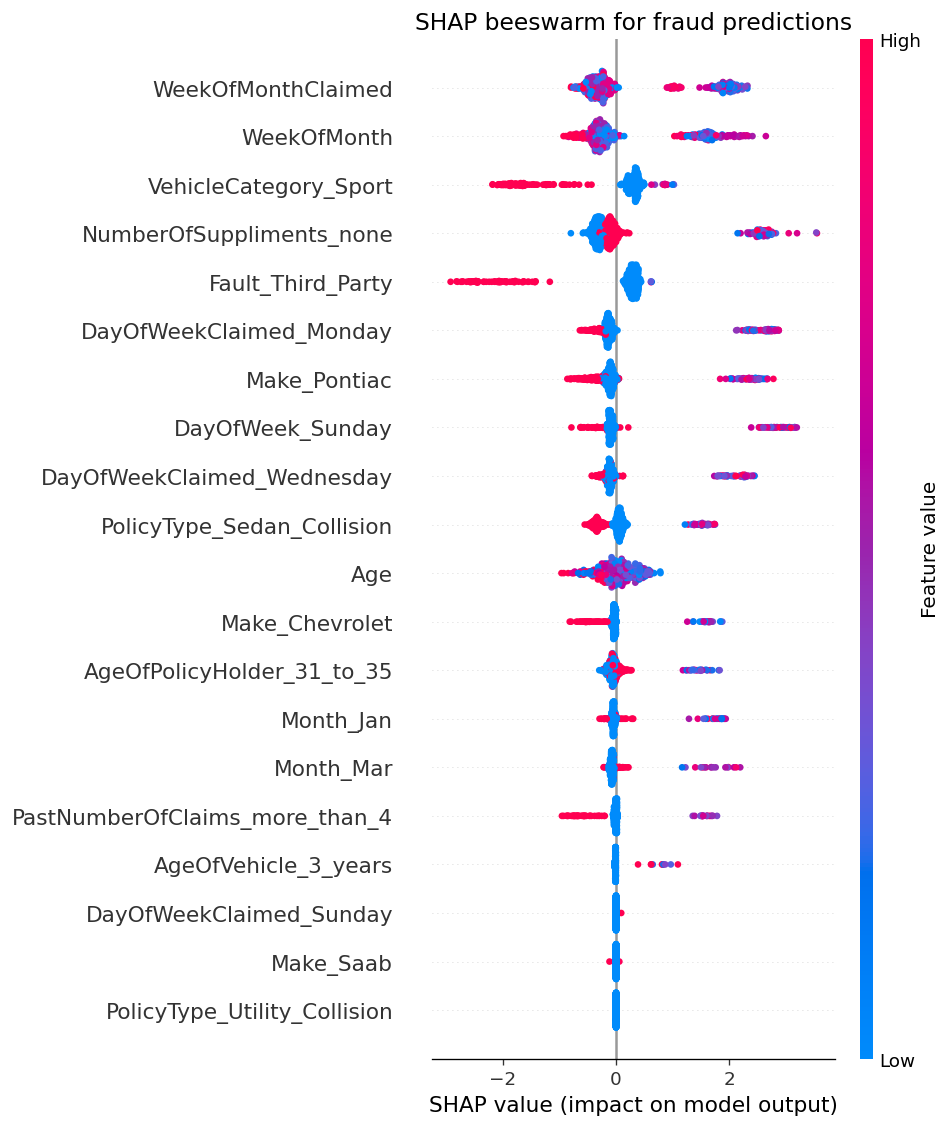

In [82]:
# Figure F2 — SHAP beeswarm
if "fraud_shap_values" in globals():
    shap.plots.beeswarm(
        fraud_shap_values,
        max_display=20,
        show=False,
    )
    plt.title("SHAP beeswarm for fraud predictions")
    save_figure("F2_shap_beeswarm.png")
    plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/F3_shap_waterfall_high_risk_claim.png


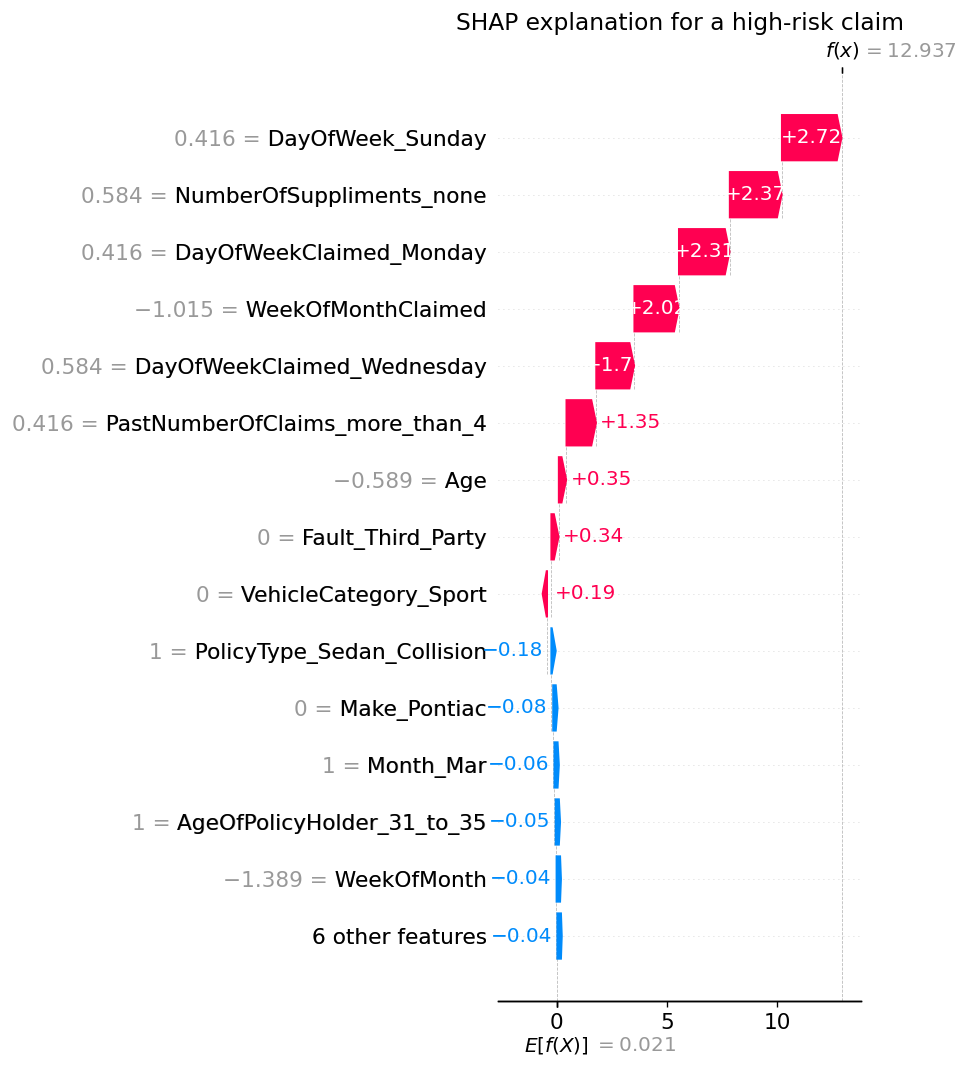

In [83]:
# Figure F3 — SHAP waterfall for a high-risk example
if "fraud_shap_values" in globals():
    highest_risk_index = int(
        np.argmax(
            trained_models[shap_model_name]["pipeline"]
            .predict_proba(explain_sample)[:, 1]
        )
    )

    shap.plots.waterfall(
        fraud_shap_values[highest_risk_index],
        max_display=15,
        show=False,
    )
    plt.title("SHAP explanation for a high-risk claim")
    save_figure("F3_shap_waterfall_high_risk_claim.png")
    plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/F4_shap_dependence_weekofmonthclaimed.png


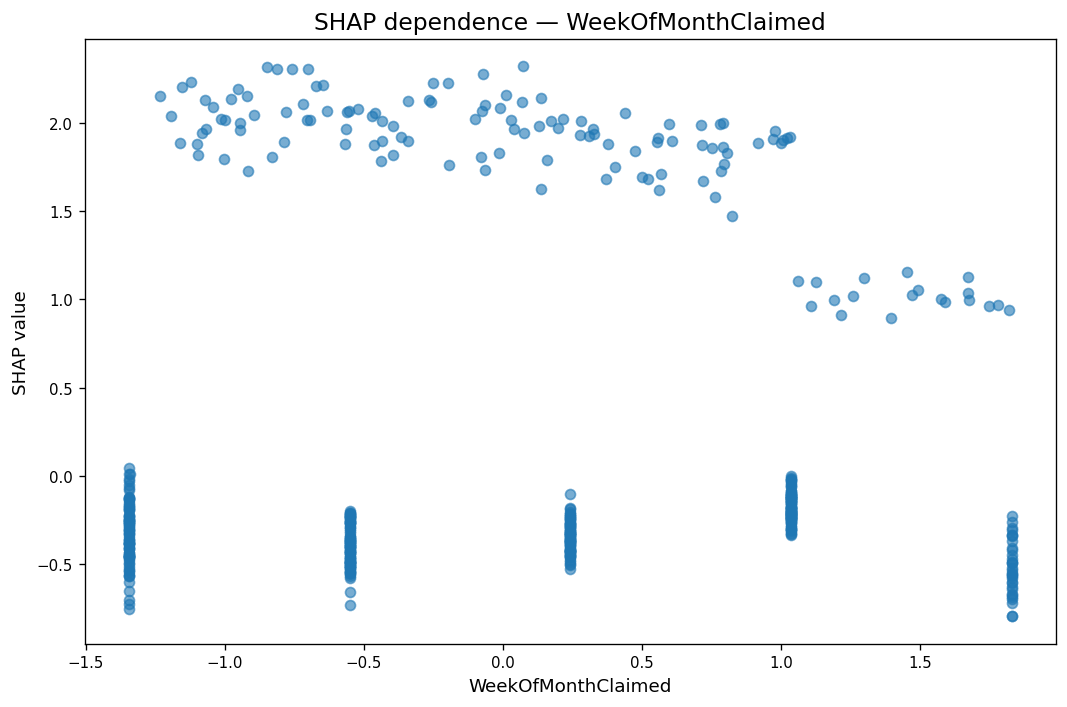

Saved: /content/drive/MyDrive/Thesis/figures/F5_shap_dependence_weekofmonth.png


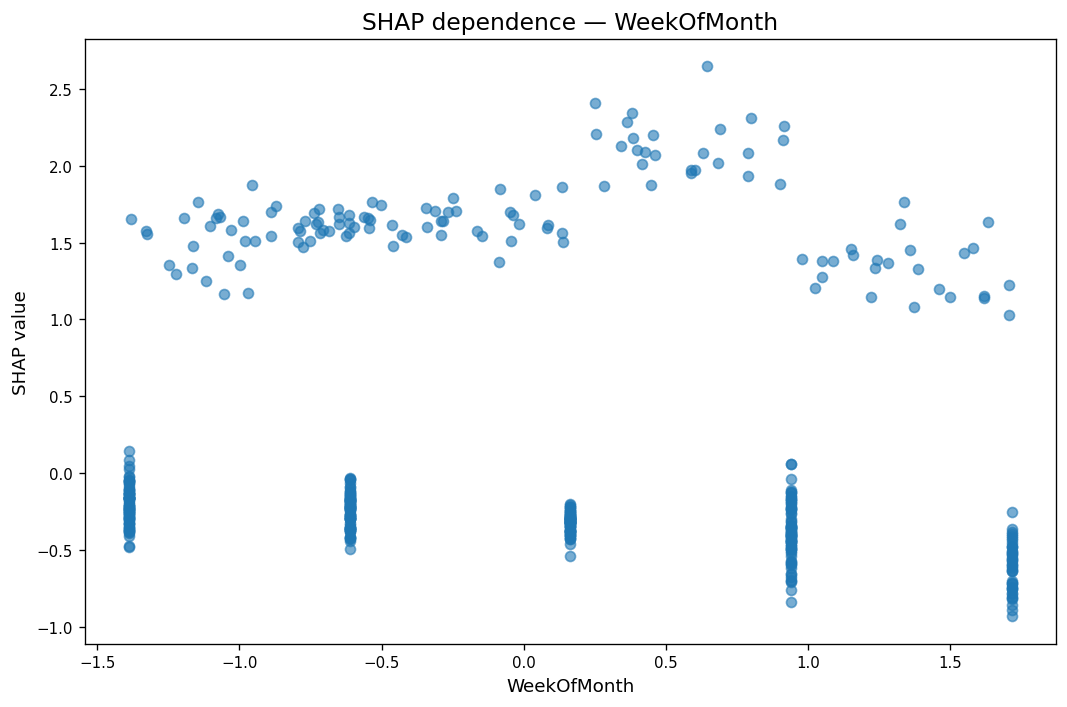

Saved: /content/drive/MyDrive/Thesis/figures/F6_shap_dependence_vehiclecategory_sport.png


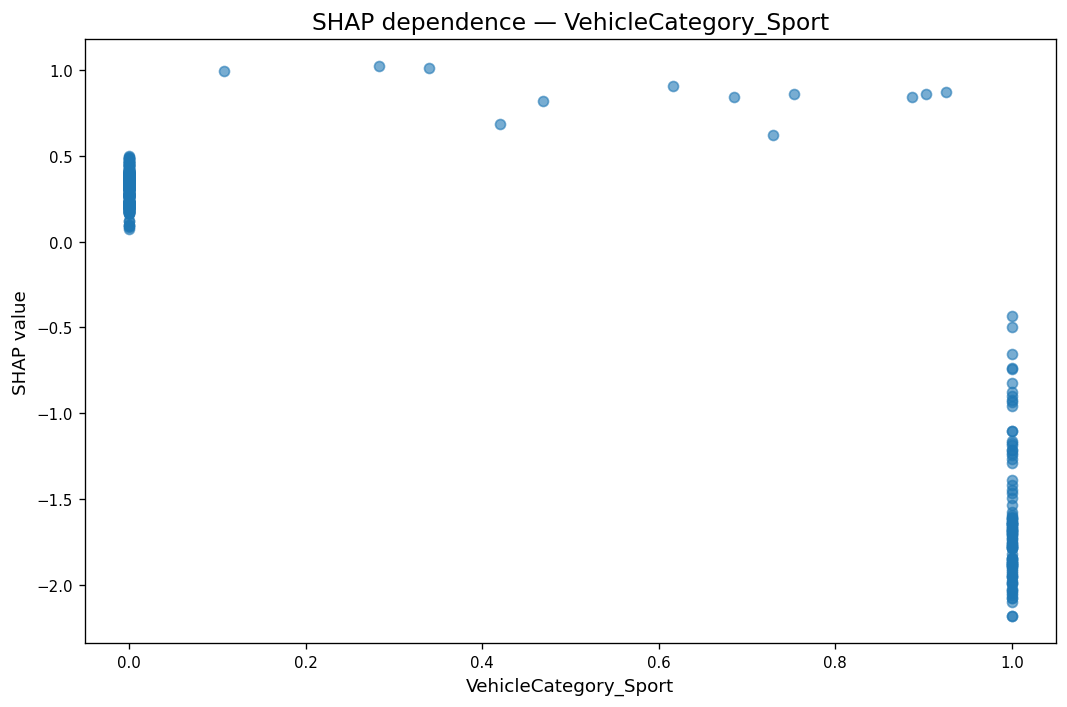

Saved: /content/drive/MyDrive/Thesis/figures/F7_shap_dependence_numberofsuppliments_none.png


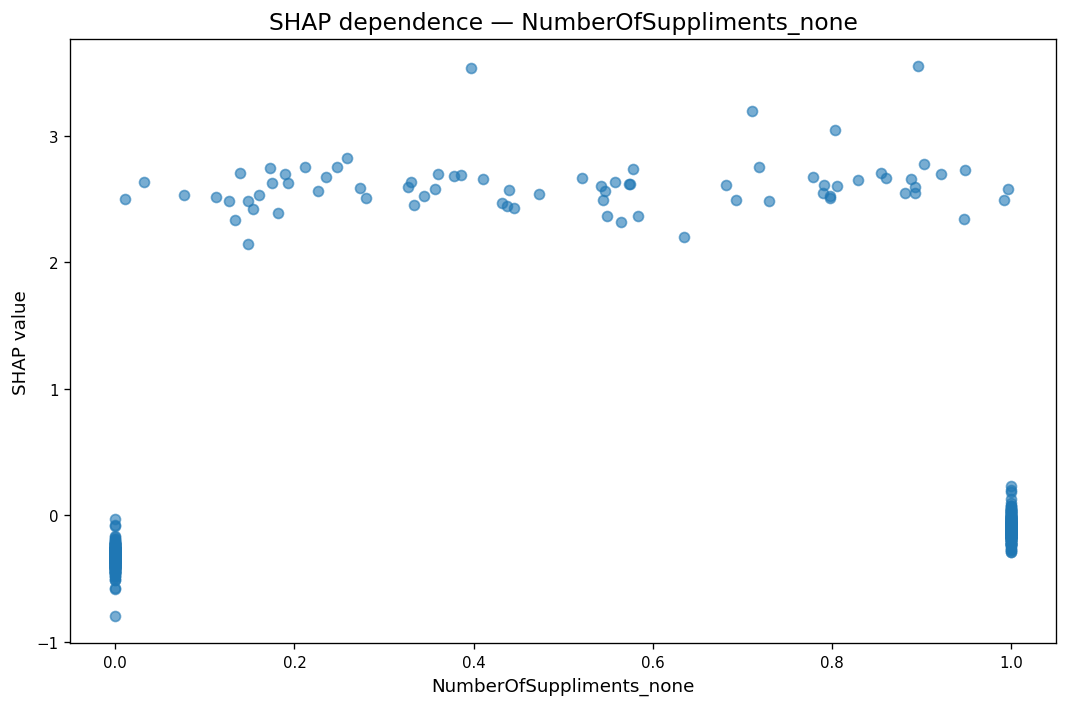

Saved: /content/drive/MyDrive/Thesis/figures/F8_shap_dependence_fault_third_party.png


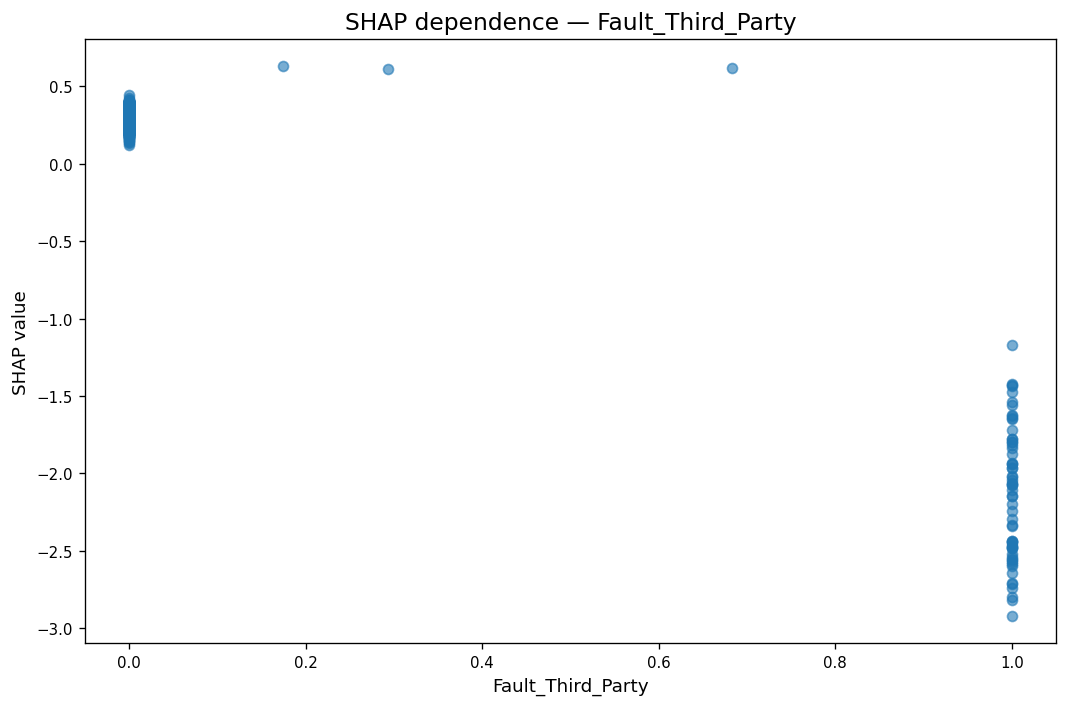

In [84]:
# Figures F4–F8 — SHAP dependence plots for top five features
if (
    "fraud_shap_values" in globals()
    and shap_path.exists()
):
    top_five_features = (
        shap_importance_fig["Feature"]
        .head(5)
        .tolist()
    )

    for rank, feature in enumerate(
        top_five_features,
        start=1,
    ):
        if feature not in explain_sample.columns:
            continue

        feature_index = list(
            explain_sample.columns
        ).index(feature)

        fig, ax = plt.subplots(figsize=(9, 6))
        ax.scatter(
            explain_sample[feature],
            fraud_shap_values.values[:, feature_index],
            alpha=0.6,
        )
        ax.set_title(
            f"SHAP dependence — {feature}"
        )
        ax.set_xlabel(feature)
        ax.set_ylabel("SHAP value")

        safe_feature = re.sub(
            r"[^A-Za-z0-9]+",
            "_",
            feature,
        ).strip("_").lower()

        save_figure(
            f"F{rank+3}_shap_dependence_{safe_feature}.png"
        )
        plt.show()

## G. BART, coherence and CleanLab figures

In [86]:
bart_path = PROCESSED_DIR / "cfpb_bart_scored.parquet"

if bart_path.exists():
    df_bart_fig = pd.read_parquet(bart_path)

    # Ensure derived columns exist.
    if "behavioural_risk" not in df_bart_fig.columns:
        df_bart_fig["behavioural_risk"] = df_bart_fig[
            ["deception", "bad_faith", "obstruction"]
        ].mean(axis=1)

    if "transactional_risk" not in df_bart_fig.columns:
        df_bart_fig["transactional_risk"] = df_bart_fig[
            ["unauthorised_activity", "identity_theft"]
        ].mean(axis=1)

    if "raw_fraud_risk" not in df_bart_fig.columns:
        df_bart_fig["raw_fraud_risk"] = df_bart_fig[
            ["behavioural_risk", "transactional_risk"]
        ].max(axis=1)

    if "contradiction_score" not in df_bart_fig.columns:
        df_bart_fig["contradiction_score"] = np.minimum(
            df_bart_fig["raw_fraud_risk"],
            df_bart_fig["routine_nonfraud"],
        )

Saved: /content/drive/MyDrive/Thesis/figures/G1_behavioural_vs_transactional_risk.png


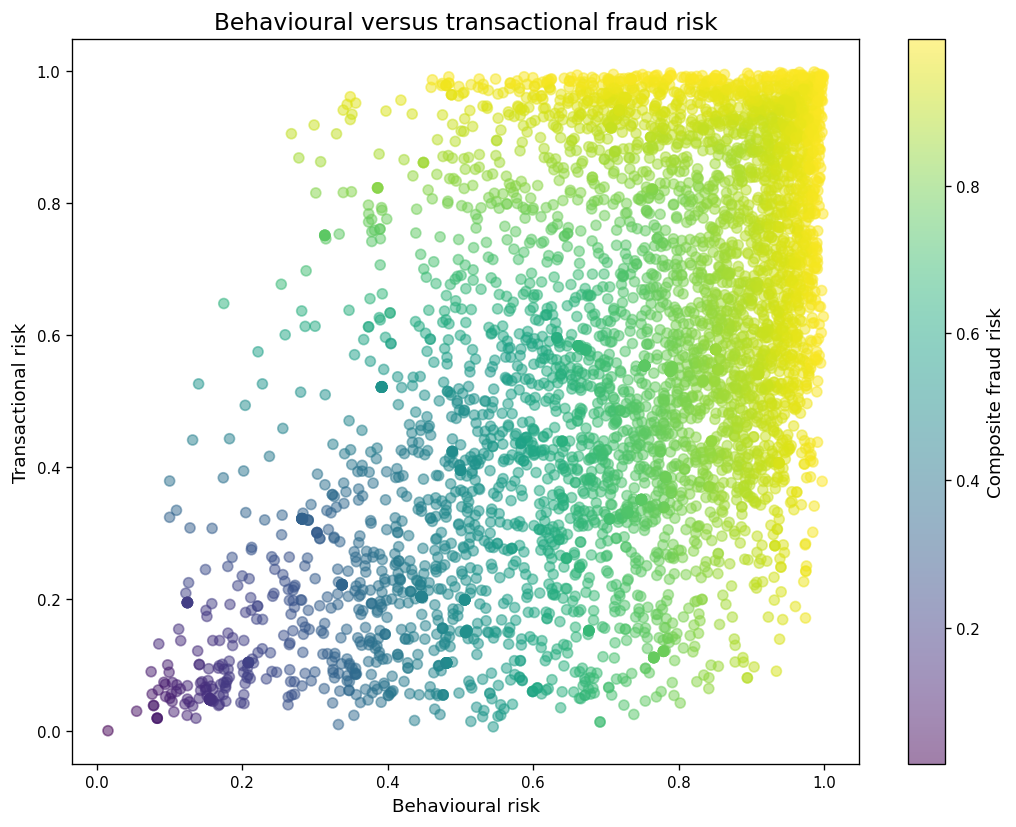

In [87]:
# Figure G1 — Behavioural vs transactional risk
if bart_path.exists():
    fig, ax = plt.subplots(figsize=(9, 7))
    scatter = ax.scatter(
        df_bart_fig["behavioural_risk"],
        df_bart_fig["transactional_risk"],
        c=df_bart_fig["raw_fraud_risk"],
        alpha=0.5,
    )
    ax.set_title("Behavioural versus transactional fraud risk")
    ax.set_xlabel("Behavioural risk")
    ax.set_ylabel("Transactional risk")
    fig.colorbar(
        scatter,
        ax=ax,
        label="Composite fraud risk",
    )

    save_figure("G1_behavioural_vs_transactional_risk.png")
    plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/G2_bart_fraud_risk_distribution.png


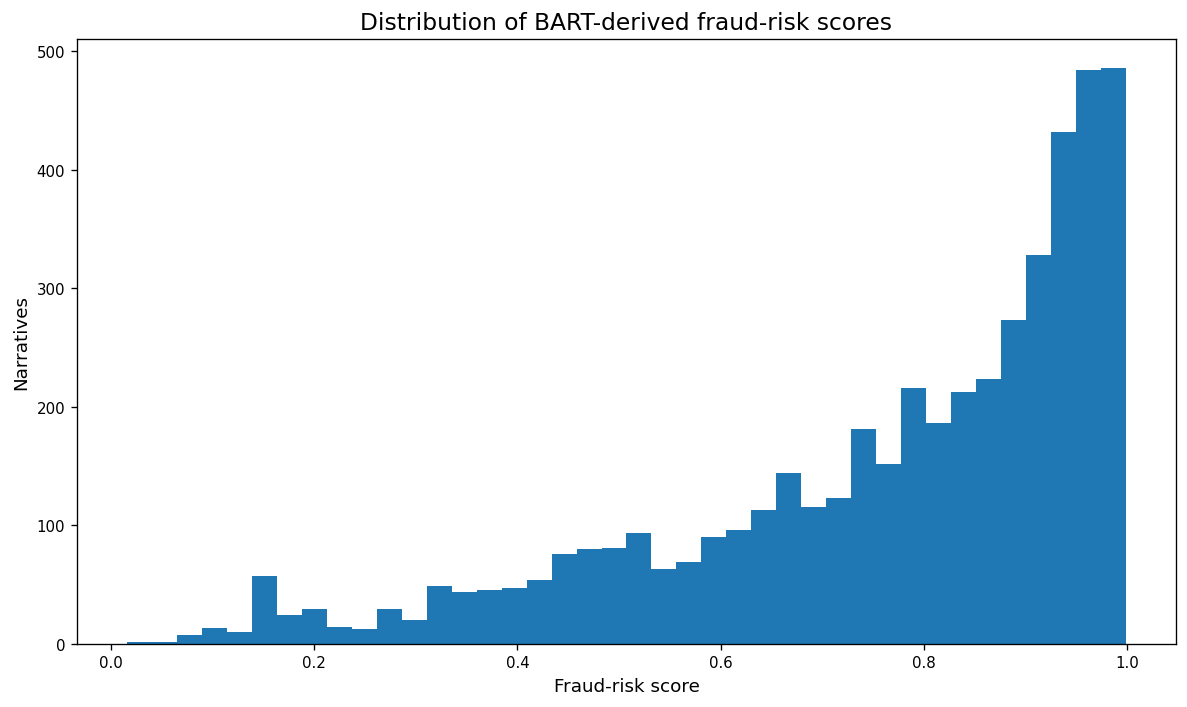

In [88]:
# Figure G2 — Fraud-risk distribution
if bart_path.exists():
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(
        df_bart_fig["raw_fraud_risk"],
        bins=40,
    )
    ax.set_title("Distribution of BART-derived fraud-risk scores")
    ax.set_xlabel("Fraud-risk score")
    ax.set_ylabel("Narratives")

    save_figure("G2_bart_fraud_risk_distribution.png")
    plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/G3_bart_hypothesis_correlation_heatmap.png


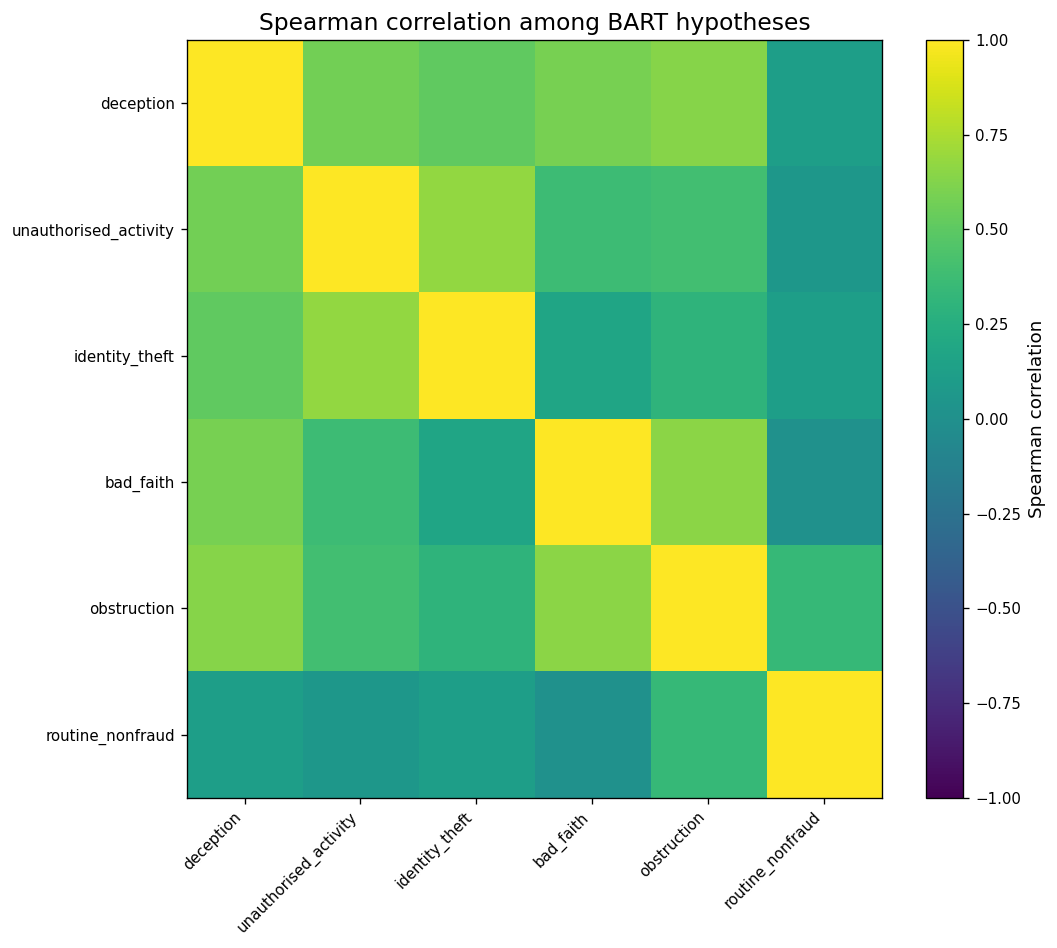

In [89]:
# Figure G3 — Hypothesis correlation heatmap
if bart_path.exists():
    hypothesis_columns = [
        "deception",
        "unauthorised_activity",
        "identity_theft",
        "bad_faith",
        "obstruction",
        "routine_nonfraud",
    ]

    hypothesis_corr = (
        df_bart_fig[hypothesis_columns]
        .corr(method="spearman")
    )

    fig, ax = plt.subplots(figsize=(9, 8))
    image = ax.imshow(
        hypothesis_corr.values,
        vmin=-1,
        vmax=1,
        aspect="auto",
    )
    ax.set_xticks(
        range(len(hypothesis_columns))
    )
    ax.set_xticklabels(
        hypothesis_columns,
        rotation=45,
        ha="right",
    )
    ax.set_yticks(
        range(len(hypothesis_columns))
    )
    ax.set_yticklabels(hypothesis_columns)
    ax.set_title("Spearman correlation among BART hypotheses")
    fig.colorbar(
        image,
        ax=ax,
        label="Spearman correlation",
    )

    save_figure("G3_bart_hypothesis_correlation_heatmap.png")
    plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/G4_bart_contradiction_score_distribution.png


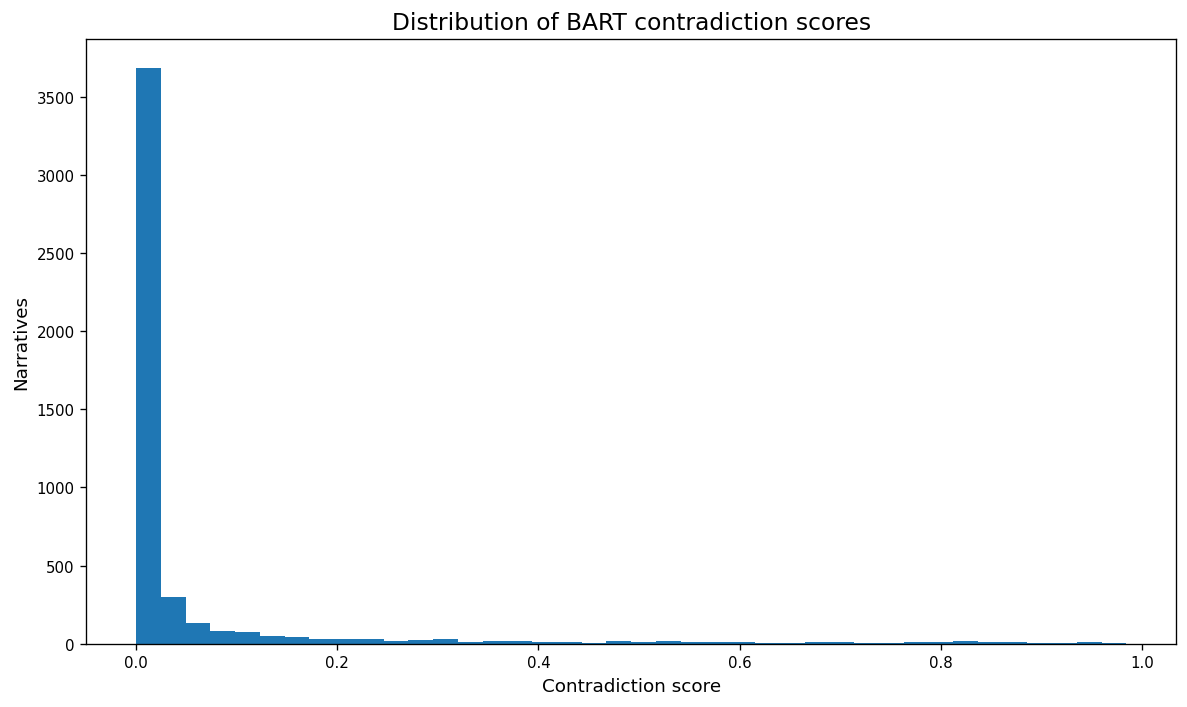

In [90]:
# Figure G4 — Contradiction score distribution
if bart_path.exists():
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(
        df_bart_fig["contradiction_score"],
        bins=40,
    )
    ax.set_title("Distribution of BART contradiction scores")
    ax.set_xlabel("Contradiction score")
    ax.set_ylabel("Narratives")

    save_figure("G4_bart_contradiction_score_distribution.png")
    plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/G5_before_after_coherence_filtering.png


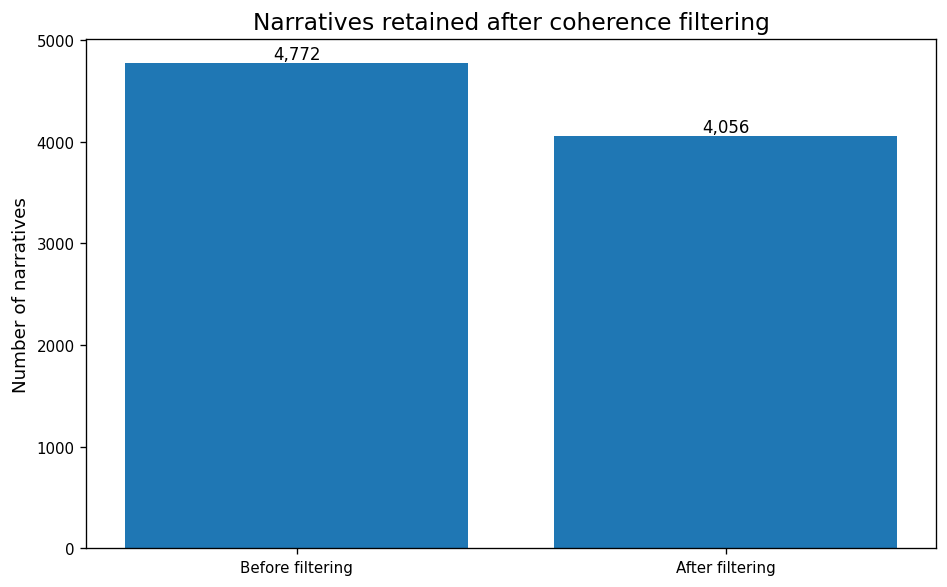

In [91]:
# Figure G5 — Before and after coherence filtering
coherent_path = PROCESSED_DIR / "cfpb_coherence_filtered.parquet"

if bart_path.exists() and coherent_path.exists():
    df_coherent_fig = pd.read_parquet(coherent_path)

    counts = pd.Series({
        "Before filtering": len(df_bart_fig),
        "After filtering": len(df_coherent_fig),
    })

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(counts.index, counts.values)
    ax.set_title("Narratives retained after coherence filtering")
    ax.set_ylabel("Number of narratives")

    for bar, value in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f"{value:,}",
            ha="center",
            va="bottom",
        )

    save_figure("G5_before_after_coherence_filtering.png")
    plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/G6_weak_label_distribution.png


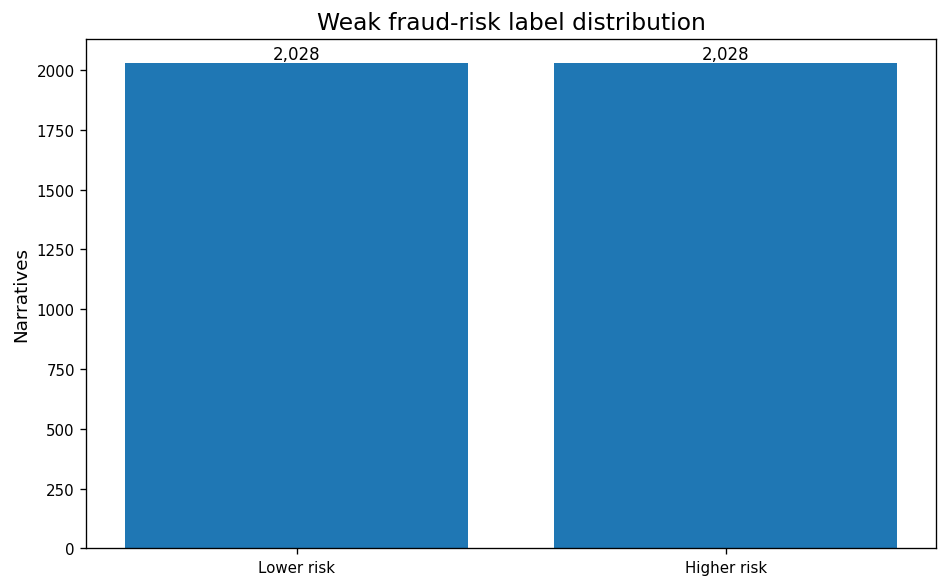

In [92]:
# Figure G6 — Weak-label distribution
if coherent_path.exists():
    if "df_coherent_fig" not in globals():
        df_coherent_fig = pd.read_parquet(coherent_path)

    weak_counts = (
        df_coherent_fig["weak_fraud_label"]
        .value_counts()
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(
        ["Lower risk", "Higher risk"],
        weak_counts.values,
    )
    ax.set_title("Weak fraud-risk label distribution")
    ax.set_ylabel("Narratives")

    for bar, value in zip(bars, weak_counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f"{value:,}",
            ha="center",
            va="bottom",
        )

    save_figure("G6_weak_label_distribution.png")
    plt.show()

In [95]:
# Figures G7 and G8 — CleanLab diagnostics
high_quality_path = PROCESSED_DIR / "cfpb_high_quality_labels.parquet"

if coherent_path.exists():
    df_cleanlab_all = pd.read_parquet(coherent_path)

    if (
        "label_quality_score" in df_cleanlab_all.columns
        and "cleanlab_flagged" in df_cleanlab_all.columns
    ):
        # G7 — Label-quality histogram
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.hist(
            df_cleanlab_all["label_quality_score"],
            bins=40,
        )
        ax.set_title("CleanLab label-quality score distribution")
        ax.set_xlabel("Label-quality score")
        ax.set_ylabel("Narratives")

        save_figure("G7_cleanlab_label_quality_histogram.png")
        plt.show()

        # G8 — Before and after CleanLab
        counts = pd.Series({
            "Before CleanLab": len(df_cleanlab_all),
            "After CleanLab": int(
                (~df_cleanlab_all["cleanlab_flagged"]).sum()
            ),
        })

        fig, ax = plt.subplots(figsize=(8, 5))
        bars = ax.bar(counts.index, counts.values)
        ax.set_title("Narratives retained after CleanLab filtering")
        ax.set_ylabel("Number of narratives")

        for bar, value in zip(bars, counts.values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value,
                f"{value:,}",
                ha="center",
                va="bottom",
            )

        save_figure("G8_before_after_cleanlab.png")
        plt.show()

## H. Dashboard-preview figures

Saved: /content/drive/MyDrive/Thesis/figures/H1_structured_dashboard_kpi_preview.png


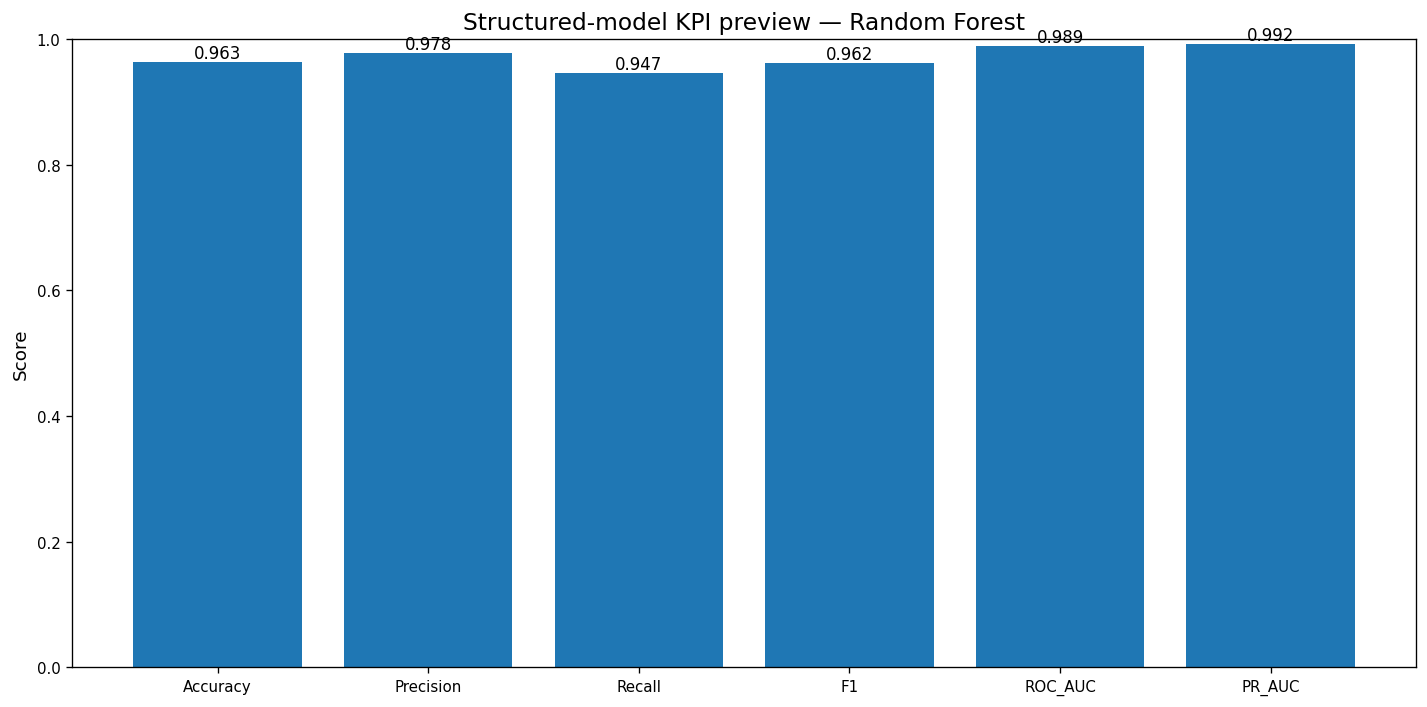

In [96]:
# Figure H1 — Structured KPI preview
best_row = test_results.iloc[0]

kpi_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "PR_AUC",
]

kpi_values = [
    best_row[name]
    for name in kpi_names
]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(kpi_names, kpi_values)
ax.set_ylim(0, 1)
ax.set_title(
    f"Structured-model KPI preview — {BEST_MODEL_NAME}"
)
ax.set_ylabel("Score")

for bar, value in zip(bars, kpi_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom",
    )

save_figure("H1_structured_dashboard_kpi_preview.png")
plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/H2_structured_prediction_risk_distribution.png


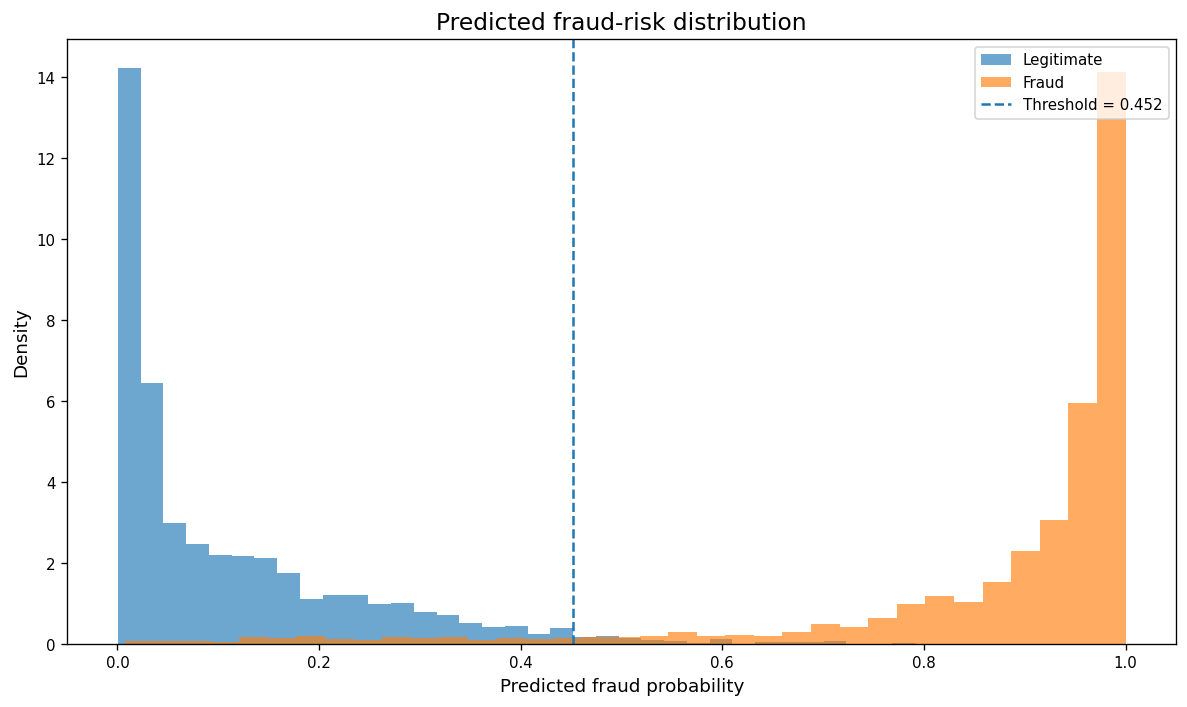

In [97]:
# Figure H2 — Structured prediction-risk distribution
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    structured_export.loc[
        structured_export["ActualFraud"] == 0,
        "PredictedFraudProbability",
    ],
    bins=35,
    alpha=0.65,
    density=True,
    label="Legitimate",
)

ax.hist(
    structured_export.loc[
        structured_export["ActualFraud"] == 1,
        "PredictedFraudProbability",
    ],
    bins=35,
    alpha=0.65,
    density=True,
    label="Fraud",
)

ax.axvline(
    BEST_THRESHOLD,
    linestyle="--",
    label=f"Threshold = {BEST_THRESHOLD:.3f}",
)

ax.set_title("Predicted fraud-risk distribution")
ax.set_xlabel("Predicted fraud probability")
ax.set_ylabel("Density")
ax.legend()

save_figure("H2_structured_prediction_risk_distribution.png")
plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/H3_narrative_risk_by_product_group.png


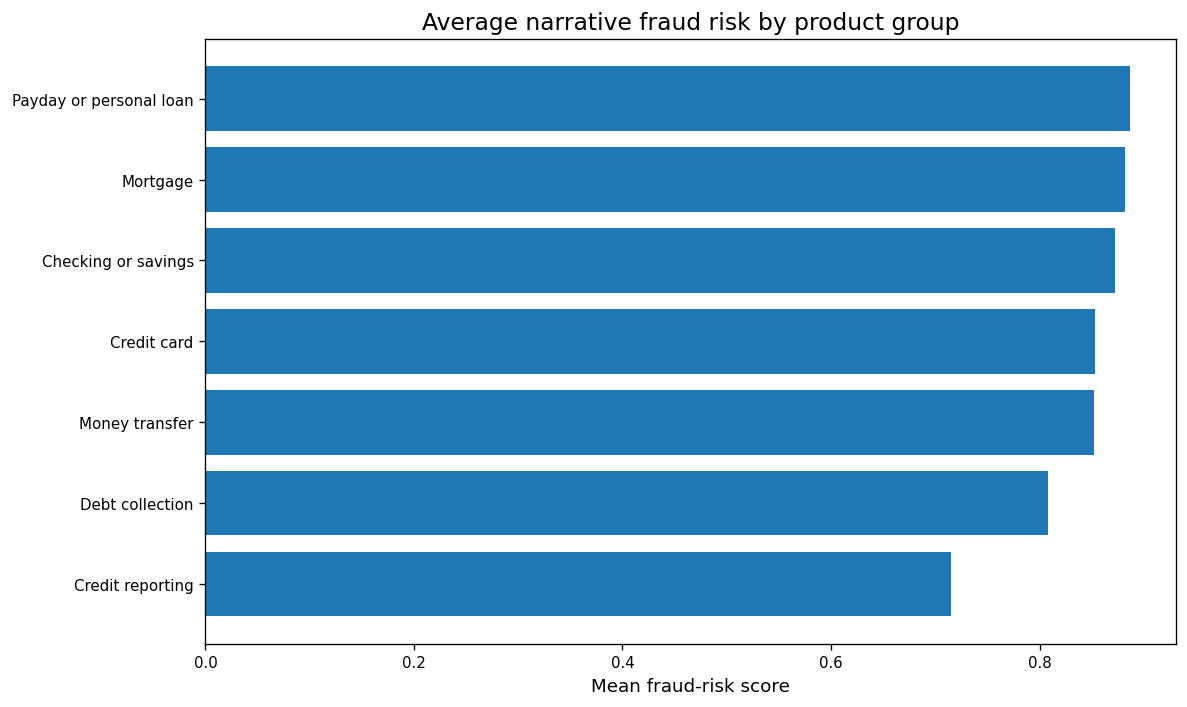

In [98]:
# Figure H3 — Narrative dashboard preview by product group
if high_quality_path.exists():
    df_high_quality_fig = pd.read_parquet(high_quality_path)

    narrative_product_summary = (
        df_high_quality_fig
        .groupby("ProductGroup")
        .agg(
            MeanFraudRisk=("raw_fraud_risk", "mean"),
            NarrativeCount=("raw_fraud_risk", "size"),
        )
        .sort_values("MeanFraudRisk")
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(
        narrative_product_summary.index,
        narrative_product_summary["MeanFraudRisk"],
    )
    ax.set_title("Average narrative fraud risk by product group")
    ax.set_xlabel("Mean fraud-risk score")

    save_figure("H3_narrative_risk_by_product_group.png")
    plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/H4_narrative_volume_vs_risk.png


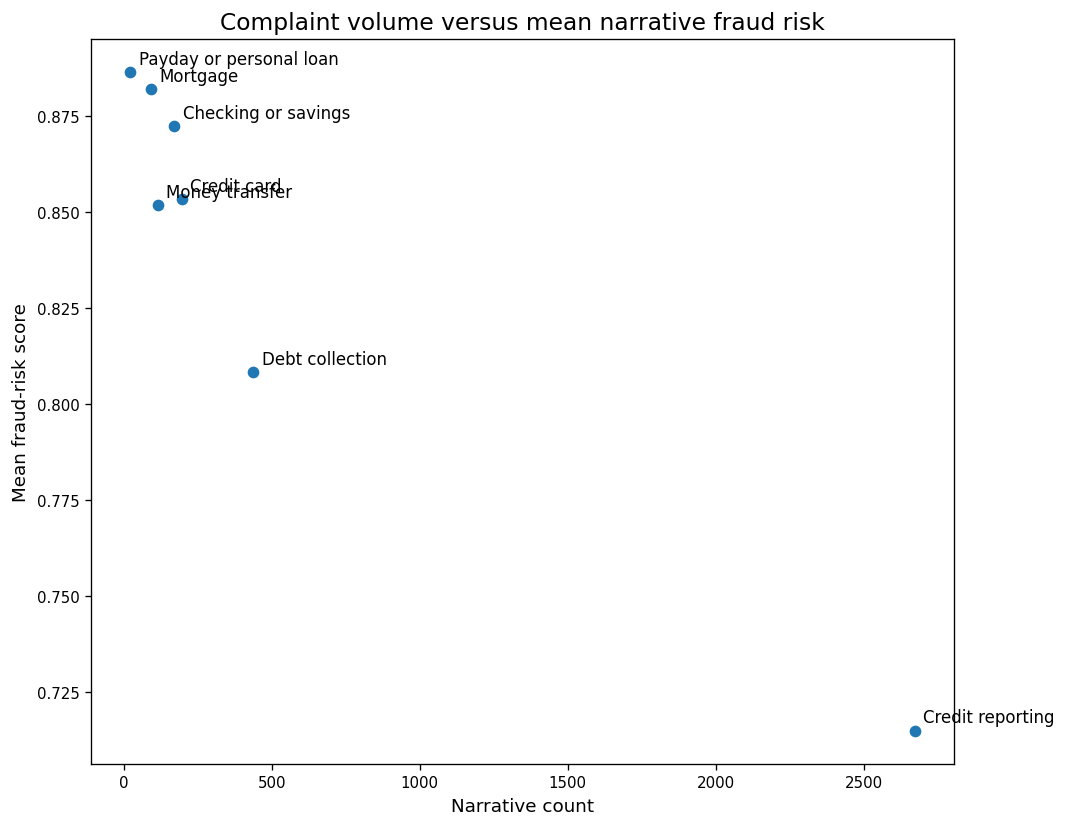

In [99]:
# Figure H4 — Narrative count versus mean fraud risk
if high_quality_path.exists():
    fig, ax = plt.subplots(figsize=(9, 7))

    ax.scatter(
        narrative_product_summary["NarrativeCount"],
        narrative_product_summary["MeanFraudRisk"],
    )

    for product, row in narrative_product_summary.iterrows():
        ax.annotate(
            product,
            (
                row["NarrativeCount"],
                row["MeanFraudRisk"],
            ),
            xytext=(5, 5),
            textcoords="offset points",
        )

    ax.set_title("Complaint volume versus mean narrative fraud risk")
    ax.set_xlabel("Narrative count")
    ax.set_ylabel("Mean fraud-risk score")

    save_figure("H4_narrative_volume_vs_risk.png")
    plt.show()

## I. End-to-end methodology diagrams

In [101]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def draw_vertical_pipeline(
    stages,
    title,
    filename,
):
    fig, ax = plt.subplots(
        figsize=(10, max(8, len(stages) * 1.2))
    )

    ax.set_xlim(0, 10)
    ax.set_ylim(0, len(stages) * 2)
    ax.axis("off")
    ax.set_title(title, fontsize=16, pad=20)

    y_positions = np.linspace(
        len(stages) * 2 - 1,
        1,
        len(stages),
    )

    for index, (stage, y) in enumerate(
        zip(stages, y_positions)
    ):
        box = FancyBboxPatch(
            (2, y - 0.45),
            6,
            0.9,
            boxstyle="round,pad=0.03,rounding_size=0.08",
            linewidth=1.5,
            facecolor="white",
        )
        ax.add_patch(box)
        ax.text(
            5,
            y,
            stage,
            ha="center",
            va="center",
            fontsize=11,
        )

        if index < len(stages) - 1:
            next_y = y_positions[index + 1]
            arrow = FancyArrowPatch(
                (5, y - 0.5),
                (5, next_y + 0.5),
                arrowstyle="-|>",
                mutation_scale=14,
                linewidth=1.5,
            )
            ax.add_patch(arrow)

    save_figure(filename)
    plt.show()

Saved: /content/drive/MyDrive/Thesis/figures/I1_structured_pipeline_diagram.png


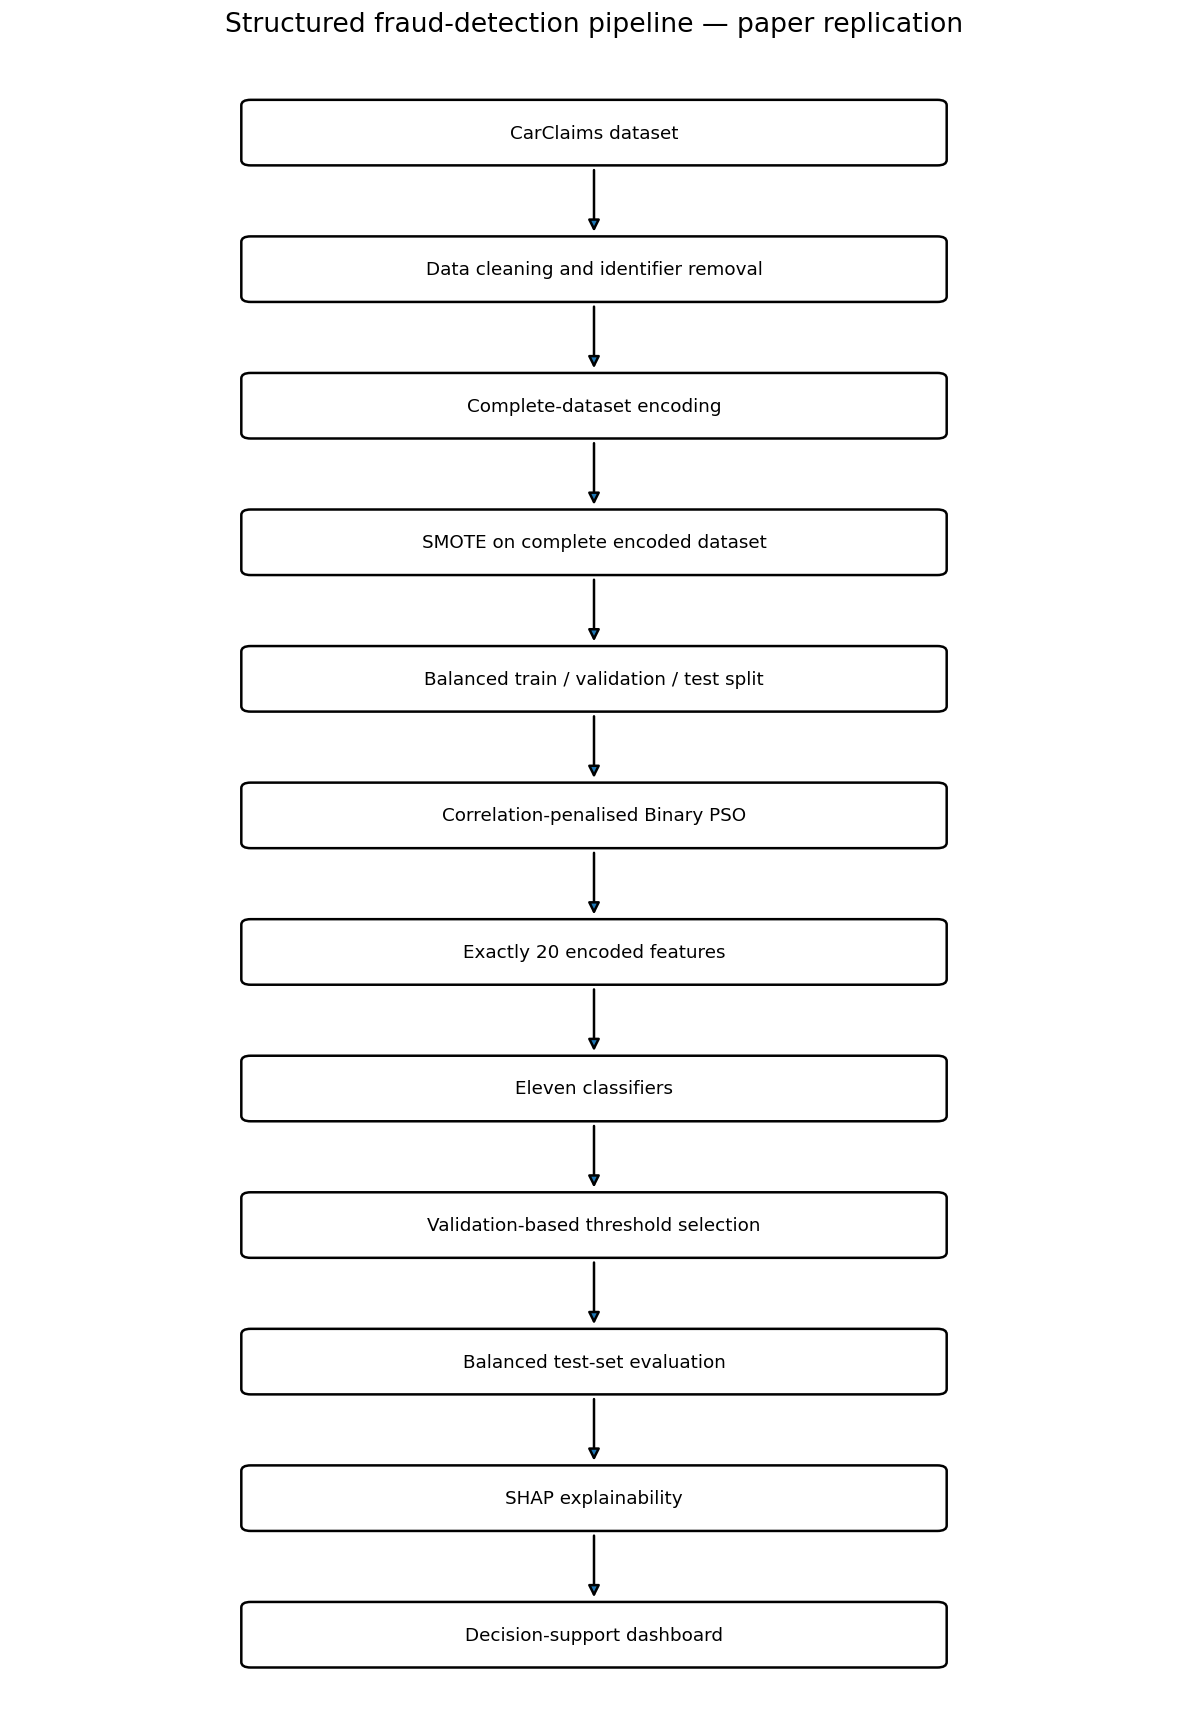

In [102]:
# Figure I1 — Structured pipeline
structured_stages = [
    "CarClaims dataset",
    "Data cleaning and identifier removal",
    "Complete-dataset encoding",
    "SMOTE on complete encoded dataset",
    "Balanced train / validation / test split",
    "Correlation-penalised Binary PSO",
    "Exactly 20 encoded features",
    "Eleven classifiers",
    "Validation-based threshold selection",
    "Balanced test-set evaluation",
    "SHAP explainability",
    "Decision-support dashboard",
]

draw_vertical_pipeline(
    structured_stages,
    "Structured fraud-detection pipeline — paper replication",
    "I1_structured_pipeline_diagram.png",
)


Saved: /content/drive/MyDrive/Thesis/figures/I2_narrative_pipeline_diagram.png


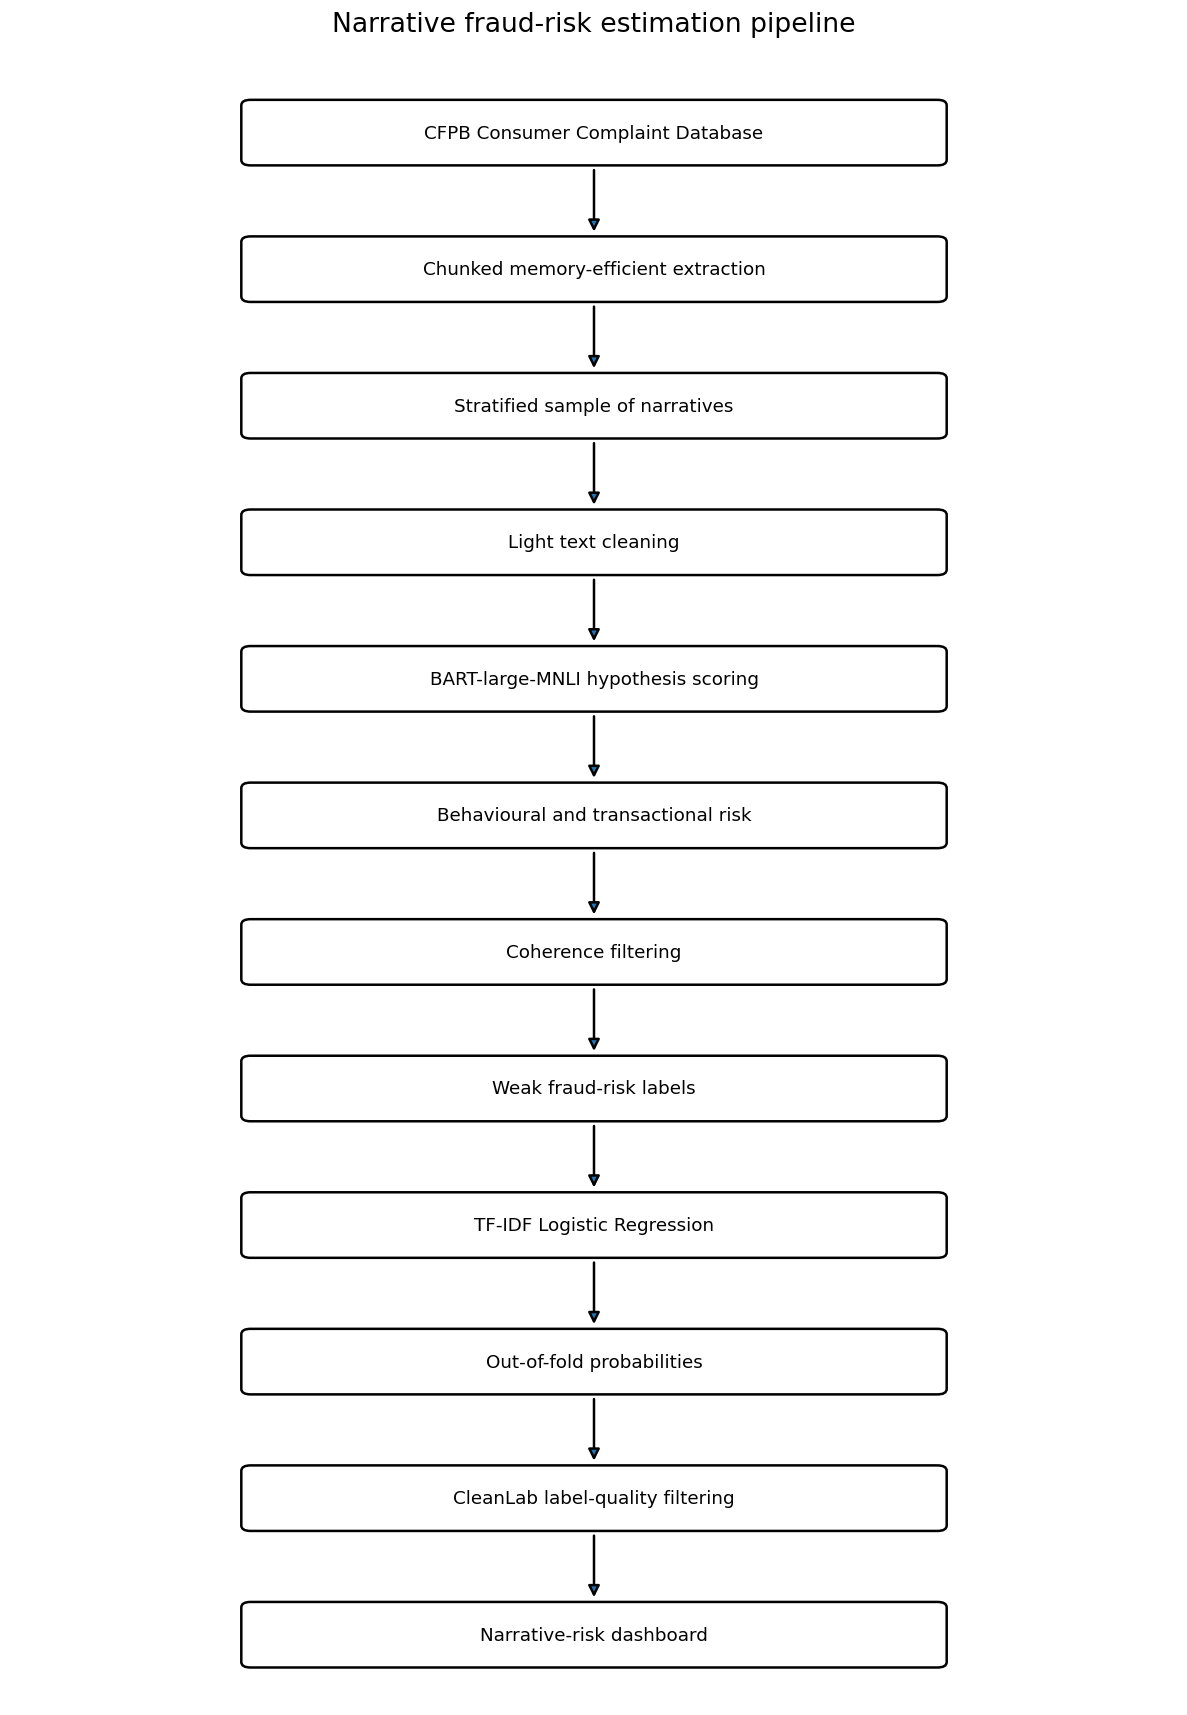

In [103]:
# Figure I2 — Narrative pipeline
narrative_stages = [
    "CFPB Consumer Complaint Database",
    "Chunked memory-efficient extraction",
    "Stratified sample of narratives",
    "Light text cleaning",
    "BART-large-MNLI hypothesis scoring",
    "Behavioural and transactional risk",
    "Coherence filtering",
    "Weak fraud-risk labels",
    "TF-IDF Logistic Regression",
    "Out-of-fold probabilities",
    "CleanLab label-quality filtering",
    "Narrative-risk dashboard",
]

draw_vertical_pipeline(
    narrative_stages,
    "Narrative fraud-risk estimation pipeline",
    "I2_narrative_pipeline_diagram.png",
)

Saved: /content/drive/MyDrive/Thesis/figures/I3_dashboard_level_integration_diagram.png


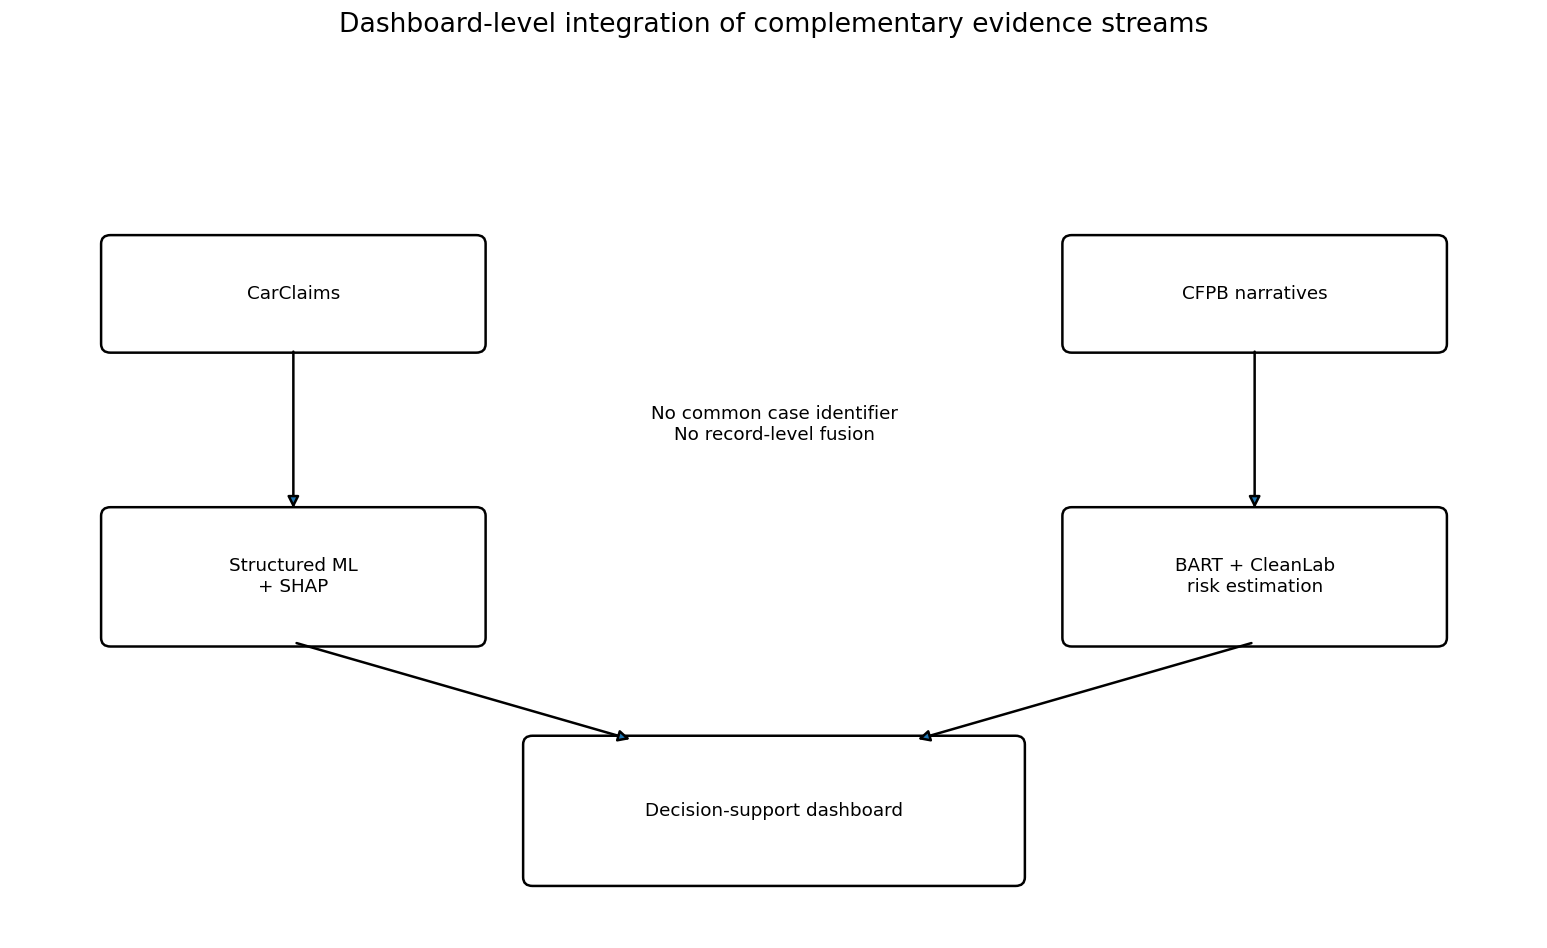

In [104]:
# Figure I3 — Dashboard-level integration diagram
fig, ax = plt.subplots(figsize=(13, 8))
ax.set_xlim(0, 13)
ax.set_ylim(0, 8)
ax.axis("off")
ax.set_title(
    "Dashboard-level integration of complementary evidence streams",
    fontsize=16,
    pad=20,
)

boxes = {
    "CarClaims": (0.8, 5.4, 3.2, 1.0),
    "Structured ML\n+ SHAP": (0.8, 2.7, 3.2, 1.2),
    "CFPB narratives": (9.0, 5.4, 3.2, 1.0),
    "BART + CleanLab\nrisk estimation": (9.0, 2.7, 3.2, 1.2),
    "Decision-support dashboard": (4.4, 0.5, 4.2, 1.3),
}

for label, (x, y, width, height) in boxes.items():
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.04,rounding_size=0.08",
        linewidth=1.5,
        facecolor="white",
    )
    ax.add_patch(box)
    ax.text(
        x + width / 2,
        y + height / 2,
        label,
        ha="center",
        va="center",
        fontsize=11,
    )

arrows = [
    ((2.4, 5.4), (2.4, 3.9)),
    ((10.6, 5.4), (10.6, 3.9)),
    ((2.4, 2.7), (5.3, 1.8)),
    ((10.6, 2.7), (7.7, 1.8)),
]

for start, end in arrows:
    ax.add_patch(
        FancyArrowPatch(
            start,
            end,
            arrowstyle="-|>",
            mutation_scale=14,
            linewidth=1.5,
        )
    )

ax.text(
    6.5,
    4.7,
    "No common case identifier\nNo record-level fusion",
    ha="center",
    va="center",
    fontsize=11,
)

save_figure("I3_dashboard_level_integration_diagram.png")
plt.show()

## J. Figure inventory

This cell creates an index of all generated figures for use while writing the dissertation.

In [105]:
figure_files = sorted(
    FIGURES_DIR.glob("*.png")
)

figure_inventory = pd.DataFrame({
    "FigureNumber": range(1, len(figure_files) + 1),
    "Filename": [path.name for path in figure_files],
    "FullPath": [str(path) for path in figure_files],
})

figure_inventory.to_csv(
    FIGURES_DIR / "figure_inventory.csv",
    index=False,
)

display(figure_inventory)

print(
    f"Total PNG figures currently available: "
    f"{len(figure_inventory)}"
)

,FigureNumber,Filename,FullPath
0,1,A1_carclaims_class_distribution.png,/content/drive/MyDrive/Thesis/figures/A1_carcl...
1,2,A2_carclaims_class_proportions.png,/content/drive/MyDrive/Thesis/figures/A2_carcl...
2,3,A3_age_distribution_by_fraud.png,/content/drive/MyDrive/Thesis/figures/A3_age_d...
3,4,A4_fraud_rate_by_accident_area.png,/content/drive/MyDrive/Thesis/figures/A4_fraud...
4,5,A5_fraud_rate_by_base_policy.png,/content/drive/MyDrive/Thesis/figures/A5_fraud...
...,...,...,...
77,78,shap_summary_B_XGBoost.png,/content/drive/MyDrive/Thesis/figures/shap_sum...
78,79,shap_waterfall_B_XGBoost.png,/content/drive/MyDrive/Thesis/figures/shap_wat...
79,80,structured_confusion_matrix.png,/content/drive/MyDrive/Thesis/figures/structur...
80,81,structured_pr_curve.png,/content/drive/MyDrive/Thesis/figures/structur...


Total PNG figures currently available: 82


# Suggested dissertation figure selection

Not every generated figure must be placed in the main body.

### Main dissertation chapters
Use the most important figures:

- class distribution;
- structured and narrative pipeline diagrams;
- PSO convergence;
- selected-feature correlation heatmap;
- PR-AUC classifier comparison;
- combined Precision–Recall curves;
- best-model confusion matrix;
- SHAP beeswarm and waterfall;
- BART hypothesis correlation;
- behavioural versus transactional risk;
- CleanLab before/after figure;
- dashboard-level integration.

### Appendices
Move supplementary figures to an appendix:

- individual confusion matrices for all 11 classifiers;
- all metric-specific comparison charts;
- five SHAP dependence plots;
- detailed product, company and issue distributions;
- additional diagnostic plots.

This keeps the dissertation readable while preserving complete experimental evidence.